# Разработка модели оценки вероятности дефолта по кредиту

**Задача:** Задача: разработать модель оценки вероятности дефолта по кредиту

**Метрика:** ROC-AUC 

Показывает, насколько хорошо модель отделяет дефолтных клиентов от недефолтных. Значение 0.5 = случайная модель, 1.0 = идеальная.

**Финальная модель:** LightGBM с байесовской оптимизацией гиперпараметров (Hyperopt).

**Структура ноутбука:**
1. Импорты и загрузка данных
2. Анализ данных (EDA)
3. Препроцессинг
4. Отбор признаков
5. Логистическая регрессия (эксперименты с CV, GridSearch, RandomizedSearch, полиномы)
6. Дерево решений
7. KNN
8. Случайный лес
9. LightGBM + Байесовская оптимизация (финальная модель)
10. HistGradientBoosting
11. Нейронная сеть
12. CatBoost
13. VotingClassifier
14. Стекинг
15. Сравнение всех моделей
16. Валидация финальной модели
17. Pipeline

## 1. Импорты и загрузка данных

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier, VotingClassifier,
                               HistGradientBoostingClassifier)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import RFECV
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV,
                                     StratifiedKFold, cross_val_score,
                                     train_test_split)
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score,
                              precision_score, recall_score, accuracy_score,
                              RocCurveDisplay)
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from statsmodels.stats.outliers_influence import variance_inflation_factor
import lightgbm as lgb

In [3]:
df = pd.read_csv('/kaggle/input/competitions/srm-2026/X_train.csv')
y = pd.read_csv('/kaggle/input/competitions/srm-2026/y_train.csv')
df_test = pd.read_csv('/kaggle/input/competitions/srm-2026/X_test.csv', index_col=0)

In [4]:
y.value_counts(normalize=True)

target
0         0.985806
1         0.014194
Name: proportion, dtype: float64

In [5]:
y = y.values.ravel()

## 2. Анализ данных (EDA)

Прежде чем обучать модели, нужно изучить данные. Смотрим на типы столбцов, пропуски, выбросы, логические противоречия и корреляции. Пропуски нужно заполнить до обучения. Выбросы и ошибки в данных могут сильно испортить качество модели.

In [6]:
df.head()

,max_card_utilization,overdue_ratio,loan_count,min_balance_amount,avg_balance_amount,total_income_3m,max_deposit_amount_5y,transactions_sum_medicine,transactions_count_cash_services,income_transactions_sum,transactions_sum_cash,transactions_count_fashion_retail,transactions_sum_supermarkets,age
0,0.753328,0.037313,8.0,7.04,119135.82329,1672492.80,NaN,18435.7,94.0,498304.04,459500.0,24.0,83465.74747,28.577687
1,0.995400,0.235849,23.0,6.39,2351.16641,36538.60,NaN,559.5,25.0,243070.05,90400.0,0.0,2110.91000,7.069131
2,0.709131,0.008065,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.457906
3,0.962400,0.072464,13.0,9.22,19399.44669,526090.44,NaN,1473.5,46.0,72600.00,22600.0,0.0,5141.61000,26.754278
4,0.449544,0.190476,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.522245


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99973 entries, 0 to 99972
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   max_card_utilization               72012 non-null  float64
 1   overdue_ratio                      96268 non-null  float64
 2   loan_count                         97114 non-null  float64
 3   min_balance_amount                 92267 non-null  float64
 4   avg_balance_amount                 92267 non-null  float64
 5   total_income_3m                    86292 non-null  float64
 6   max_deposit_amount_5y              8233 non-null   float64
 7   transactions_sum_medicine          64112 non-null  float64
 8   transactions_count_cash_services   85881 non-null  float64
 9   income_transactions_sum            82150 non-null  float64
 10  transactions_sum_cash              65337 non-null  float64
 11  transactions_count_fashion_retail  85881 non-null  flo

In [8]:
df.describe()

,max_card_utilization,overdue_ratio,loan_count,min_balance_amount,avg_balance_amount,total_income_3m,max_deposit_amount_5y,transactions_sum_medicine,transactions_count_cash_services,income_transactions_sum,transactions_sum_cash,transactions_count_fashion_retail,transactions_sum_supermarkets,age
count,72012.000000,96268.000000,97114.000000,9.226700e+04,9.226700e+04,8.629200e+04,8.233000e+03,6.411200e+04,85881.000000,8.215000e+04,6.533700e+04,85881.000000,7.344100e+04,97823.000000
mean,0.399701,0.056025,10.113897,2.722137e+04,3.465048e+05,1.332957e+06,1.417422e+06,1.496642e+04,51.857908,4.945908e+05,2.409860e+05,8.365145,5.679970e+04,16.457083
std,0.406940,0.101598,7.858631,3.681405e+05,3.853387e+06,5.697790e+06,3.983311e+06,4.520681e+04,52.708269,1.077700e+06,6.965945e+05,14.361077,9.680232e+04,8.793161
min,0.000000,0.000000,1.000000,1.000000e-02,3.300000e-04,0.000000e+00,1.000000e+03,2.000000e+00,0.000000,1.000000e-02,5.820000e+00,0.000000,1.000000e+00,-2.206708
25%,0.000000,0.000000,5.000000,2.990000e+00,7.728984e+03,1.649255e+05,1.750000e+05,1.661350e+03,13.000000,6.720000e+04,2.250000e+04,0.000000,9.838240e+03,9.505818
50%,0.259489,0.014769,8.000000,2.239000e+01,2.597934e+04,4.208269e+05,5.000000e+05,5.102550e+03,38.000000,2.197981e+05,8.780000e+04,3.000000,3.207328e+04,15.572895
75%,0.863102,0.063492,14.000000,1.090550e+02,8.279567e+04,9.590913e+05,1.342836e+06,1.375619e+04,74.000000,5.509967e+05,2.293000e+05,10.000000,7.446762e+04,23.425051
max,1.000000,2.393939,333.000000,3.000000e+07,3.701721e+08,3.311446e+08,1.097567e+08,3.478390e+06,1059.000000,7.133800e+07,5.975496e+07,252.000000,1.060883e+07,100.465435


In [9]:
pd.isnull(df).sum()

max_card_utilization                 27961
overdue_ratio                         3705
loan_count                            2859
min_balance_amount                    7706
avg_balance_amount                    7706
total_income_3m                      13681
max_deposit_amount_5y                91740
transactions_sum_medicine            35861
transactions_count_cash_services     14092
income_transactions_sum              17823
transactions_sum_cash                34636
transactions_count_fashion_retail    14092
transactions_sum_supermarkets        26532
age                                   2150
dtype: int64

In [10]:
df.nunique()

max_card_utilization                 39690
overdue_ratio                        12540
loan_count                             112
min_balance_amount                   28760
avg_balance_amount                   90033
total_income_3m                      78942
max_deposit_amount_5y                 2947
transactions_sum_medicine            52233
transactions_count_cash_services       469
income_transactions_sum              64095
transactions_sum_cash                14266
transactions_count_fashion_retail      168
transactions_sum_supermarkets        70910
age                                  11550
dtype: int64

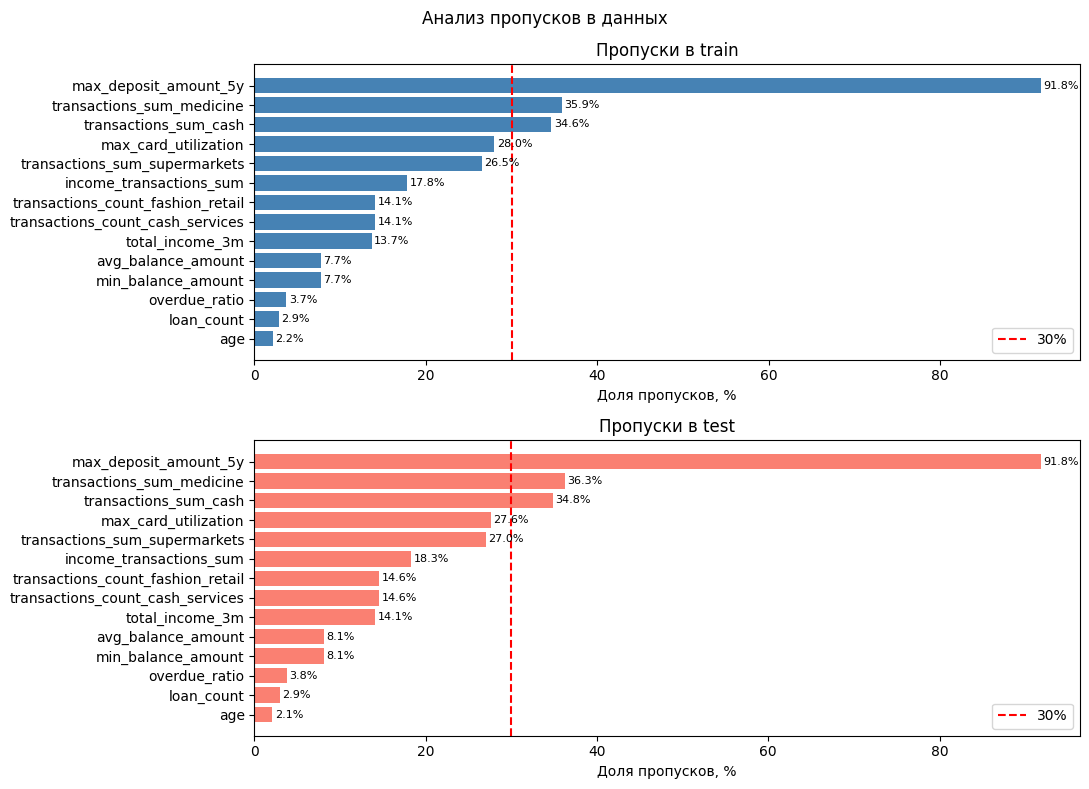

In [11]:
missing_train = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
missing_test  = (df_test.isnull().sum() / len(df_test) * 100).sort_values(ascending=True)

fig, axes = plt.subplots(2, 1, figsize=(11, 8))

axes[0].barh(missing_train.index, missing_train.values, color='steelblue')
axes[0].set_xlabel('Доля пропусков, %')
axes[0].set_title('Пропуски в train')
axes[0].axvline(x=30, color='red', linestyle='--', label='30%')
axes[0].legend()
for i, v in enumerate(missing_train.values):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)

axes[1].barh(missing_test.index, missing_test.values, color='salmon')
axes[1].set_xlabel('Доля пропусков, %')
axes[1].set_title('Пропуски в test')
axes[1].axvline(x=30, color='red', linestyle='--', label='30%')
axes[1].legend()
for i, v in enumerate(missing_test.values):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)

plt.suptitle('Анализ пропусков в данных')
plt.tight_layout()
plt.show()

In [1]:
# Ищем выбросы методом IQR: выброс — это значение, которое отклоняется от медианы более чем в 3 межквартильных размаха.

outlier_report = {}
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 3*IQR) | (df[col] > Q3 + 3*IQR)).sum()
    outlier_report[col] = {
        'Выбросов': outliers,
        'Выбросов %': round(outliers / len(df) * 100, 2)
    }
print(pd.DataFrame(outlier_report).T)

NameError: name 'data' is not defined

                                   Выбросов  Выбросов %
max_card_utilization                    0.0        0.00
overdue_ratio                        5060.0        5.06
loan_count                            510.0        0.51
min_balance_amount                  13030.0       13.03
avg_balance_amount                   8972.0        8.97
total_income_3m                      5790.0        5.79
max_deposit_amount_5y                 464.0        0.46
transactions_sum_medicine            3738.0        3.74
transactions_count_cash_services      541.0        0.54
income_transactions_sum              3298.0        3.30
transactions_sum_cash                3519.0        3.52
transactions_count_fashion_retail    3431.0        3.43
transactions_sum_supermarkets        1522.0        1.52
age                                   277.0        0.28


In [13]:
# Проверяем, что значения находятся в логически допустимых диапазонах.
# age: кредит не могут взять дети и люди старше 100 лет.
# max_card_utilization и overdue_ratio: это доли, значит должны быть от 0 до 1.

checks = {
    'age':                  (18, 100),
    'max_card_utilization': (0, 1),
    'overdue_ratio':        (0, 1),
}
for col, (low, high) in checks.items():
    out_of_range = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col} [{low}, {high}]: {out_of_range} вне диапазона")

age [18, 100]: 58389 вне диапазона
max_card_utilization [0, 1]: 0 вне диапазона
overdue_ratio [0, 1]: 22 вне диапазона


In [14]:
# Суммы транзакций, количество кредитов, возраст не могут быть отрицательными.

non_negative_cols = [
    'max_card_utilization', 'max_deposit_amount_5y',
    'transactions_sum_medicine', 'transactions_sum_cash',
    'transactions_sum_supermarkets', 'transactions_count_cash_services',
    'transactions_count_fashion_retail', 'loan_count', 'age'
]
for col in non_negative_cols:
    neg = (df[col] < 0).sum()
    print(f"{col}: {neg} отрицательных")

max_card_utilization: 0 отрицательных
max_deposit_amount_5y: 0 отрицательных
transactions_sum_medicine: 0 отрицательных
transactions_sum_cash: 0 отрицательных
transactions_sum_supermarkets: 0 отрицательных
transactions_count_cash_services: 0 отрицательных
transactions_count_fashion_retail: 0 отрицательных
loan_count: 0 отрицательных
age: 6 отрицательных


In [15]:
# Кросс-проверки — это логические противоречия между признаками.
# Если у клиента нет ни одного кредита, то просрочки быть не может.
# Минимальный баланс по определению не может превышать средний.
# Клиентам до 18 лет кредит не выдают.

cross_checks = [
    (
        (df['loan_count'] == 0) & (df['overdue_ratio'] > 0),
        "overdue_ratio > 0 при loan_count = 0"
    ),
    (
        (df['min_balance_amount'] > df['avg_balance_amount']),
        "min_balance > avg_balance"
    ),
    (
        df['age'] < 18,
        "возраст меньше 18 лет"
    ),
]

for condition, description in cross_checks:
    count = condition.sum()
    pct = count / len(df) * 100
    print(f"{description}: {count} строк ({pct:.2f}%)")

overdue_ratio > 0 при loan_count = 0: 0 строк (0.00%)
min_balance > avg_balance: 1049 строк (1.05%)
возраст меньше 18 лет: 58384 строк (58.40%)


In [16]:
print(f"Меньше 18: {(df['age'] < 18).sum()}")
print(f"Больше 100: {(df['age'] > 100).sum()}")
print(f"Отрицательных: {(df['age'] < 0).sum()}")

Меньше 18: 58384
Больше 100: 5
Отрицательных: 6


Default Rate (< 18 лет): 1.51%
Default Rate (>= 18 лет): 1.29%


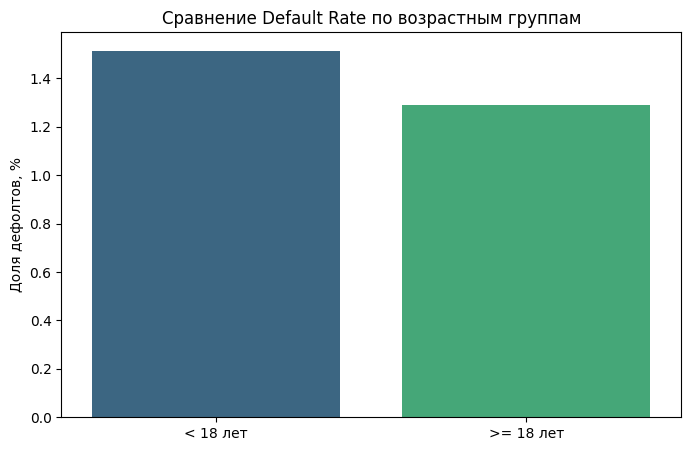

In [17]:
# Проверим,есть ли клиенты младше 18 и отличается ли у них уровень дефолта.
# Если default rate у них такой же, это может быть просто ошибка в данных. 
# Возможно age обозначает не возраст клиента, а, например, время, которое пользователь является клиентом банка

mask_kids = df['age'] < 18
mask_adults = df['age'] >= 18

dr_kids   = y[mask_kids].mean() * 100
dr_adults = y[mask_adults].mean() * 100

print(f"Default Rate (< 18 лет): {dr_kids:.2f}%")
print(f"Default Rate (>= 18 лет): {dr_adults:.2f}%")

df_analysis = df.copy()
df_analysis['target'] = y

plt.figure(figsize=(8, 5))
sns.barplot(x=['< 18 лет', '>= 18 лет'], y=[dr_kids, dr_adults], palette='viridis')
plt.title('Сравнение Default Rate по возрастным группам')
plt.ylabel('Доля дефолтов, %')
plt.show()

## 3. Препроцессинг

Заполняем пропуски. 

Заполняем 0, если пропуск означает отсутствие продукта или операции. Например, если у клиента нет карты, то `max_card_utilization` = NaN, в этом случае можно поставить 0.

Заполняем медианой, если пропуск означает «нет информации». Например, `age` = NaN, значит неизвестен возраст клиента, поэтому заменяем его медианой.

In [18]:
mask_invalid = df['min_balance_amount'] > df['avg_balance_amount']
print(f"Строк с ошибкой: {mask_invalid.sum()} ({mask_invalid.mean()*100:.2f}%)")

Строк с ошибкой: 1049 (1.05%)


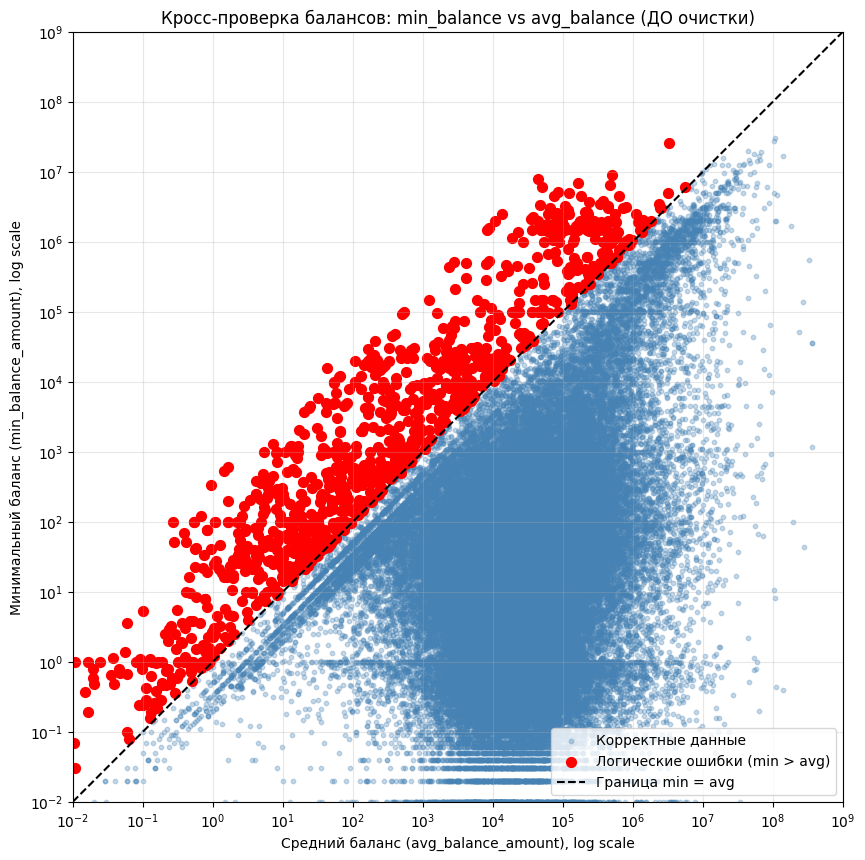

In [19]:
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 10))

plt.scatter(df.loc[~mask_invalid, 'avg_balance_amount'], df.loc[~mask_invalid, 'min_balance_amount'],
            alpha=0.3, s=10, label='Корректные данные', color='steelblue')
plt.scatter(df.loc[mask_invalid, 'avg_balance_amount'], df.loc[mask_invalid, 'min_balance_amount'],
            color='red', s=50, label='Логические ошибки (min > avg)')

lim_min, lim_max = 1e-2, 1e9

plt.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', label='Граница min = avg')

ax = plt.gca()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)

ax.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=12))
ax.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=12))

ax.set_aspect('equal', adjustable='box')

plt.xlabel('Средний баланс (avg_balance_amount), log scale')
plt.ylabel('Минимальный баланс (min_balance_amount), log scale')
plt.title('Кросс-проверка балансов: min_balance vs avg_balance (ДО очистки)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3, which='both')
plt.show()

In [20]:
# Возраст вне диапазона [0, 100] считаем ошибкой и заменяем медианным значением.
median_age = df.loc[(df['age'] >= 0) & (df['age'] <= 100), 'age'].median()
df.loc[(df['age'] < 0) | (df['age'] > 100), 'age'] = median_age

print(f"Отрицательных после исправления: {(df['age'] < 0).sum()}")

Отрицательных после исправления: 0


In [21]:
# Строки, где min_balance > avg_balance невозможны. Их немного, поэтому просто удаляем.

mask_invalid = df['min_balance_amount'] > df['avg_balance_amount']
mask_valid = ~mask_invalid
df = df[mask_valid].reset_index(drop=True)
y  = y[mask_valid]

# Сохраняем копию сырых данных до заполнения пропусков 
df_raw = df.copy()

In [22]:
# Признаки, где NaN = "нет продукта/операции", заполняем нулём.

zero_fill = [
    'max_card_utilization', 'max_deposit_amount_5y',
    'transactions_sum_medicine', 'transactions_sum_cash',
    'transactions_sum_supermarkets', 'transactions_count_cash_services',
    'transactions_count_fashion_retail', 'loan_count',
    'overdue_ratio',           
    'total_income_3m',        
    'income_transactions_sum', 
    'min_balance_amount',      
    'avg_balance_amount',     
]

# Признак, где NaN = "нет данных", заполняем медианой.

median_fill = [
    'age'  
]


df[zero_fill] = df[zero_fill].fillna(0)

medians = df[median_fill].median()        
df[median_fill] = df[median_fill].fillna(medians)

df_test[zero_fill]  = df_test[zero_fill].fillna(0)
df_test[median_fill] = df_test[median_fill].fillna(medians)  

print("Пропуски в train:", df.isnull().sum().sum())
print("Пропуски в test: ", df_test.isnull().sum().sum())

Пропуски в train: 0
Пропуски в test:  0


In [23]:
# Делим данные на обучающую (80%) и валидационную (20%) выборки.
# stratify=y гарантирует, что доля дефолтов одинакова в обеих частях 
# random_state фиксирует разбивку, чтобы результаты воспроизводились.

X_train, X_val, y_train, y_val = train_test_split(
    df, y, test_size=0.2, random_state=42, stratify=y
)

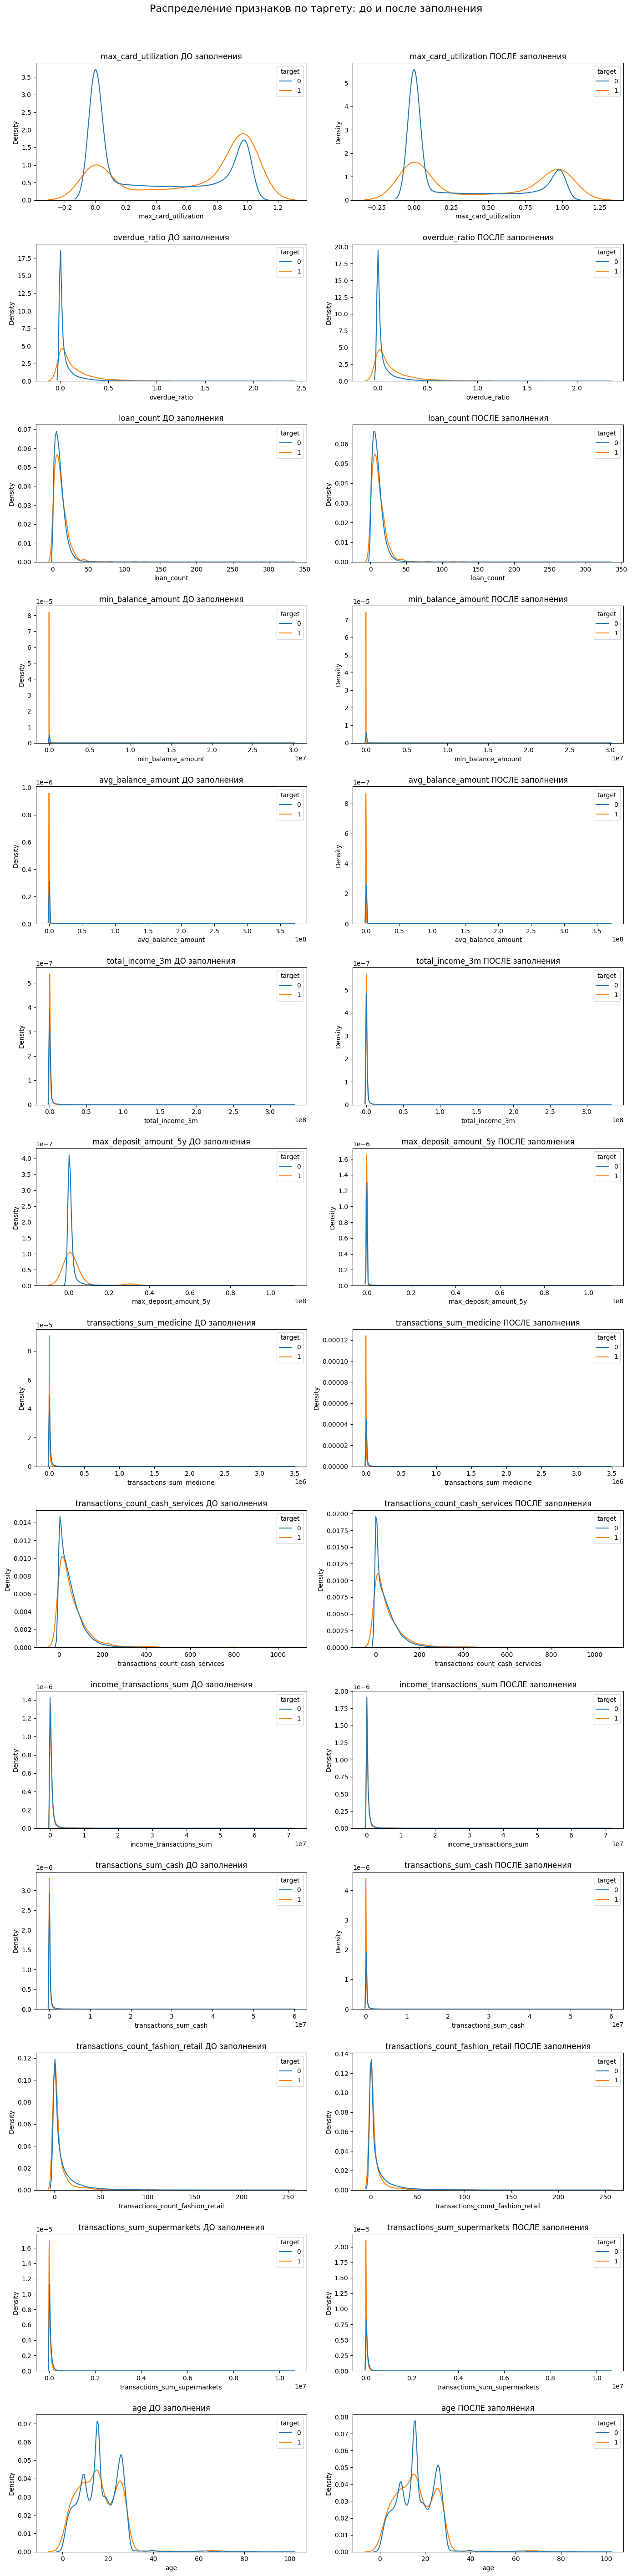

In [24]:
original_features = X_train.columns

n_rows = len(original_features)
fig, axes = plt.subplots(n_rows, 2, figsize=(14, n_rows * 4))

for i, feature in enumerate(original_features):
    if feature not in df_raw.columns:
        continue
        
    sns.kdeplot(
        data=df_raw[df_raw[feature].notna()].assign(target=y[df_raw[feature].notna()]),
        x=feature, hue='target',
        ax=axes[i, 0], common_norm=False
    )
    axes[i, 0].set_title(f'{feature} ДО заполнения')

    sns.kdeplot(
        data=X_train[[feature]].assign(target=y_train),
        x=feature, hue='target',
        ax=axes[i, 1], common_norm=False
    )
    axes[i, 1].set_title(f'{feature} ПОСЛЕ заполнения')

plt.suptitle('Распределение признаков по таргету: до и после заполнения',
             fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### Комментарий к графикам: распределение признаков до и после заполнения пропусков

**max_card_utilization** — распределение почти не изменилось. Пропусков было мало,
и заполнение нулями (клиенты без карты) не сдвинуло общую картину. Дефолтные клиенты
(target=1) по-прежнему имеют чуть более высокую утилизацию карты.

**overdue_ratio** — после заполнения нулями пик у нуля стал выше для обоих классов. Клиенты без кредитной истории есть среди и дефолтных, и недефолтных. Разделимость классов сохранилась, у дефолтных клиентов хвост распределения длиннее, то есть среди них больше тех, у кого были просрочки.

**loan_count** — изменений почти нет, пропусков было мало. Дефолтные клиенты незначительно отличаются по числу кредитов.

**min_balance_amount и avg_balance_amount** — после заполнения появился заметный пик
в нуле. Это те самые ~8% клиентов без счёта. Важно, что различие между классами сохранилось, у недефолтных клиентов остатки в среднем выше.

**total_income_3m** — появился пик в нуле (клиенты без поступлений за 3 месяца).
Признак по-прежнему разделяет классы: у дефолтных клиентов доходы ниже.

**max_deposit_amount_5y** — большинство клиентов не открывали депозиты (пик в нуле был и до заполнения). После заполнения нулями картина не изменилась.

**transactions_sum_medicine** — у большинства клиентов нет трат на медицину,
поэтому пик в нуле доминирует в обоих случаях. Признак слабо разделяет классы.

**transactions_count_cash_services** — распределение не изменилось существенно.
Небольшое различие между классами сохраняется.

**income_transactions_sum** — появился пик в нуле,но разделимость классов осталась.

**transactions_sum_cash** — пик в нуле был и до заполнения (большинство клиентов не вносили наличные). Изменений почти нет.

**transactions_count_fashion_retail** — большинство клиентов не совершали покупок в этой категории. Распределение не изменилось.

**transactions_sum_supermarkets** — пик в нуле доминировал изначально, заполнение нулями ничего не изменило.

**age** — распределение не изменилось. Пропуски в возрасте были единичными
и заполнены медианой. 

**Общий вывод:** заполнение пропусков нулями добавило пики в нуле там, где их
раньше не было, но не уничтожило разделимость классов ни по одному признаку.
Это означает, что выбранная стратегия заполнения корректна и не навредила
предсказательной силе признаков.

In [25]:
# Создаём новые признаки на основе исходных

def add_advanced_features(df_):
    df = df_.copy()
    
    total_tx = (df['transactions_sum_medicine'].fillna(0) + 
                df['transactions_sum_cash'].fillna(0) + 
                df['transactions_sum_supermarkets'].fillna(0))
    
    # Баланс относительно дохода — показывает, сколько месяцев клиент
    # может прожить без новых поступлений
    df['balance_to_income']   = df['avg_balance_amount'] / (df['total_income_3m'] + 1)
    
    # Доход на один кредит — это финансовая нагрузка на клиента
    df['income_to_loans']     = df['total_income_3m'] / (df['loan_count'] + 1)
    
    # Стабильность баланса: насколько минимум отличается от среднего.
    # Если min/avg ≈ 1 — баланс стабильный. Если min/avg = 0 — были нулевые остатки.
    df['liquidity_stability'] = df['min_balance_amount'] / (df['avg_balance_amount'] + 1)
    
    # Доли трат на медицину и наличные 
    df['medicine_ratio'] = df['transactions_sum_medicine'] / (total_tx + 1)
    df['cash_ratio_v2']  = df['transactions_sum_cash'] / (total_tx + 1)
    
    # Рост благосостояния: сумма всех приходных операций относительно среднего баланса
    df['growth_proxy']   = df['income_transactions_sum'] / (df['avg_balance_amount'] + 1)
    
    return df

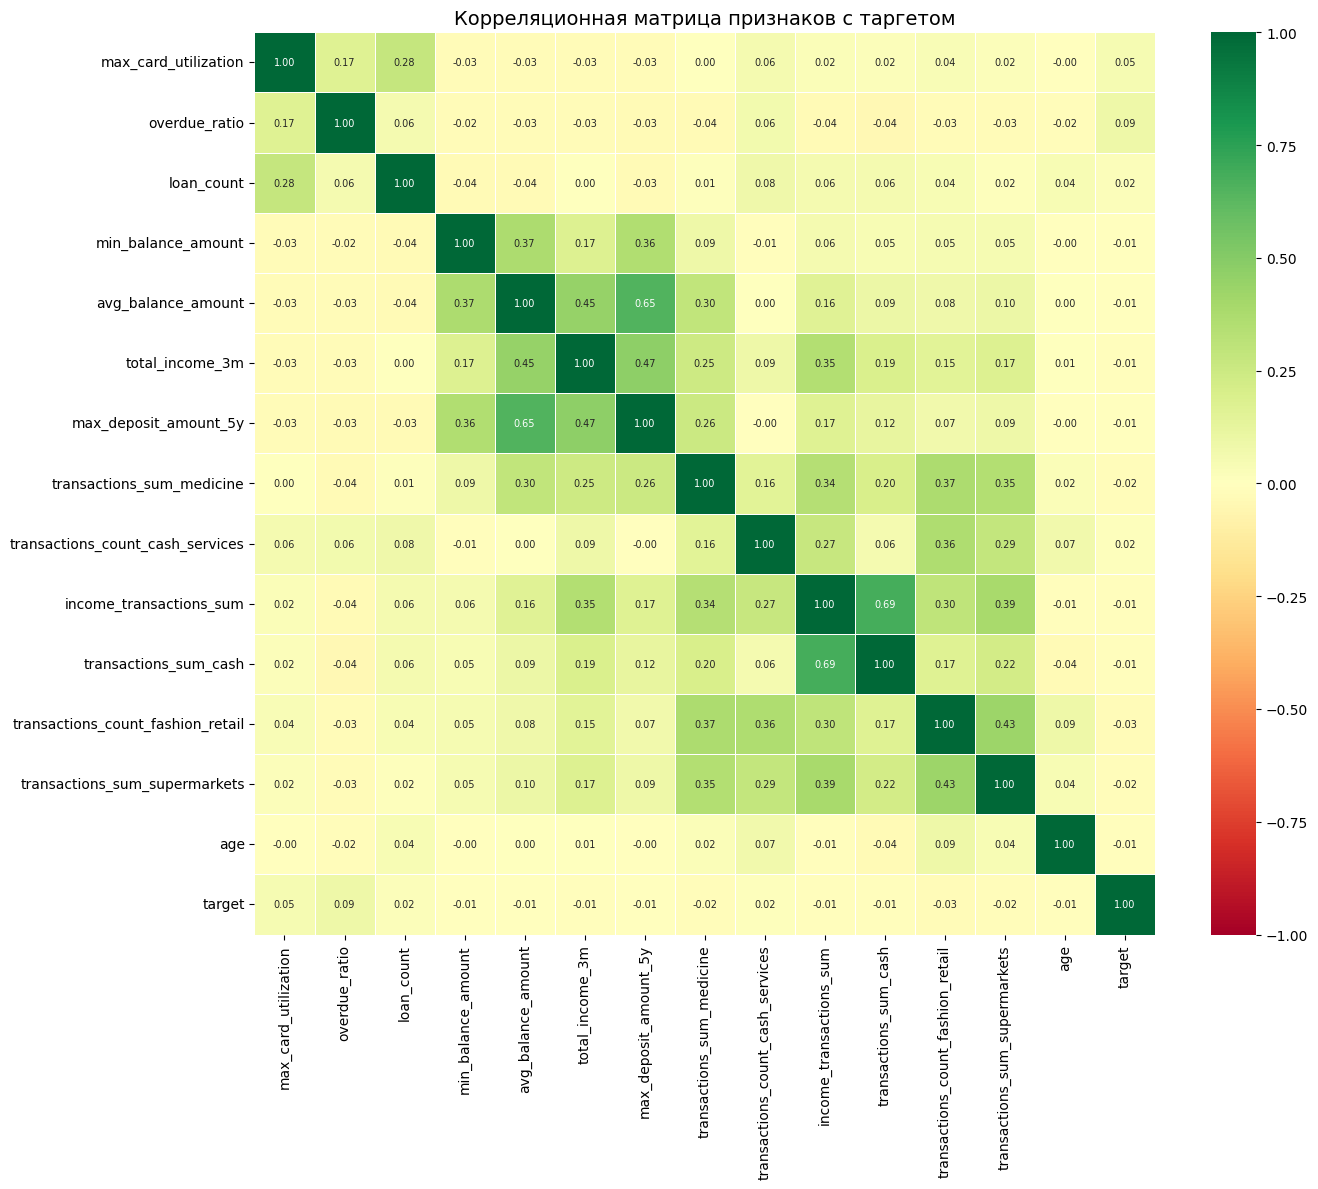

Корреляция признаков с таргетом:
overdue_ratio                        0.092378
max_card_utilization                 0.053381
loan_count                           0.020069
transactions_count_cash_services     0.015502
max_deposit_amount_5y               -0.006783
avg_balance_amount                  -0.007106
min_balance_amount                  -0.007406
age                                 -0.007853
total_income_3m                     -0.008427
income_transactions_sum             -0.009541
transactions_sum_cash               -0.009978
transactions_sum_medicine           -0.019259
transactions_sum_supermarkets       -0.019850
transactions_count_fashion_retail   -0.029468
Name: target, dtype: float64


In [26]:
# Корреляционная матрица признаков с таргетом
df_corr = X_train.copy()
df_corr['target'] = y_train

corr_matrix = df_corr.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Корреляционная матрица признаков с таргетом', fontsize=14)
plt.tight_layout()
plt.show()

target_corr = df_corr.corr()['target'].drop('target').sort_values(ascending=False)
print("Корреляция признаков с таргетом:")
print(target_corr)

In [27]:
X_train = add_advanced_features(X_train)
X_val   = add_advanced_features(X_val)
df_test = add_advanced_features(df_test)

In [28]:
# Масштабируем признаки, приводим каждый к нулевому среднему и единичному разбросу.

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),   
                               columns=X_train.columns, index=X_train.index)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val),       
                               columns=X_val.columns,   index=X_val.index)
df_test_scaled = pd.DataFrame(scaler.transform(df_test),      
                               columns=df_test.columns, index=df_test.index)

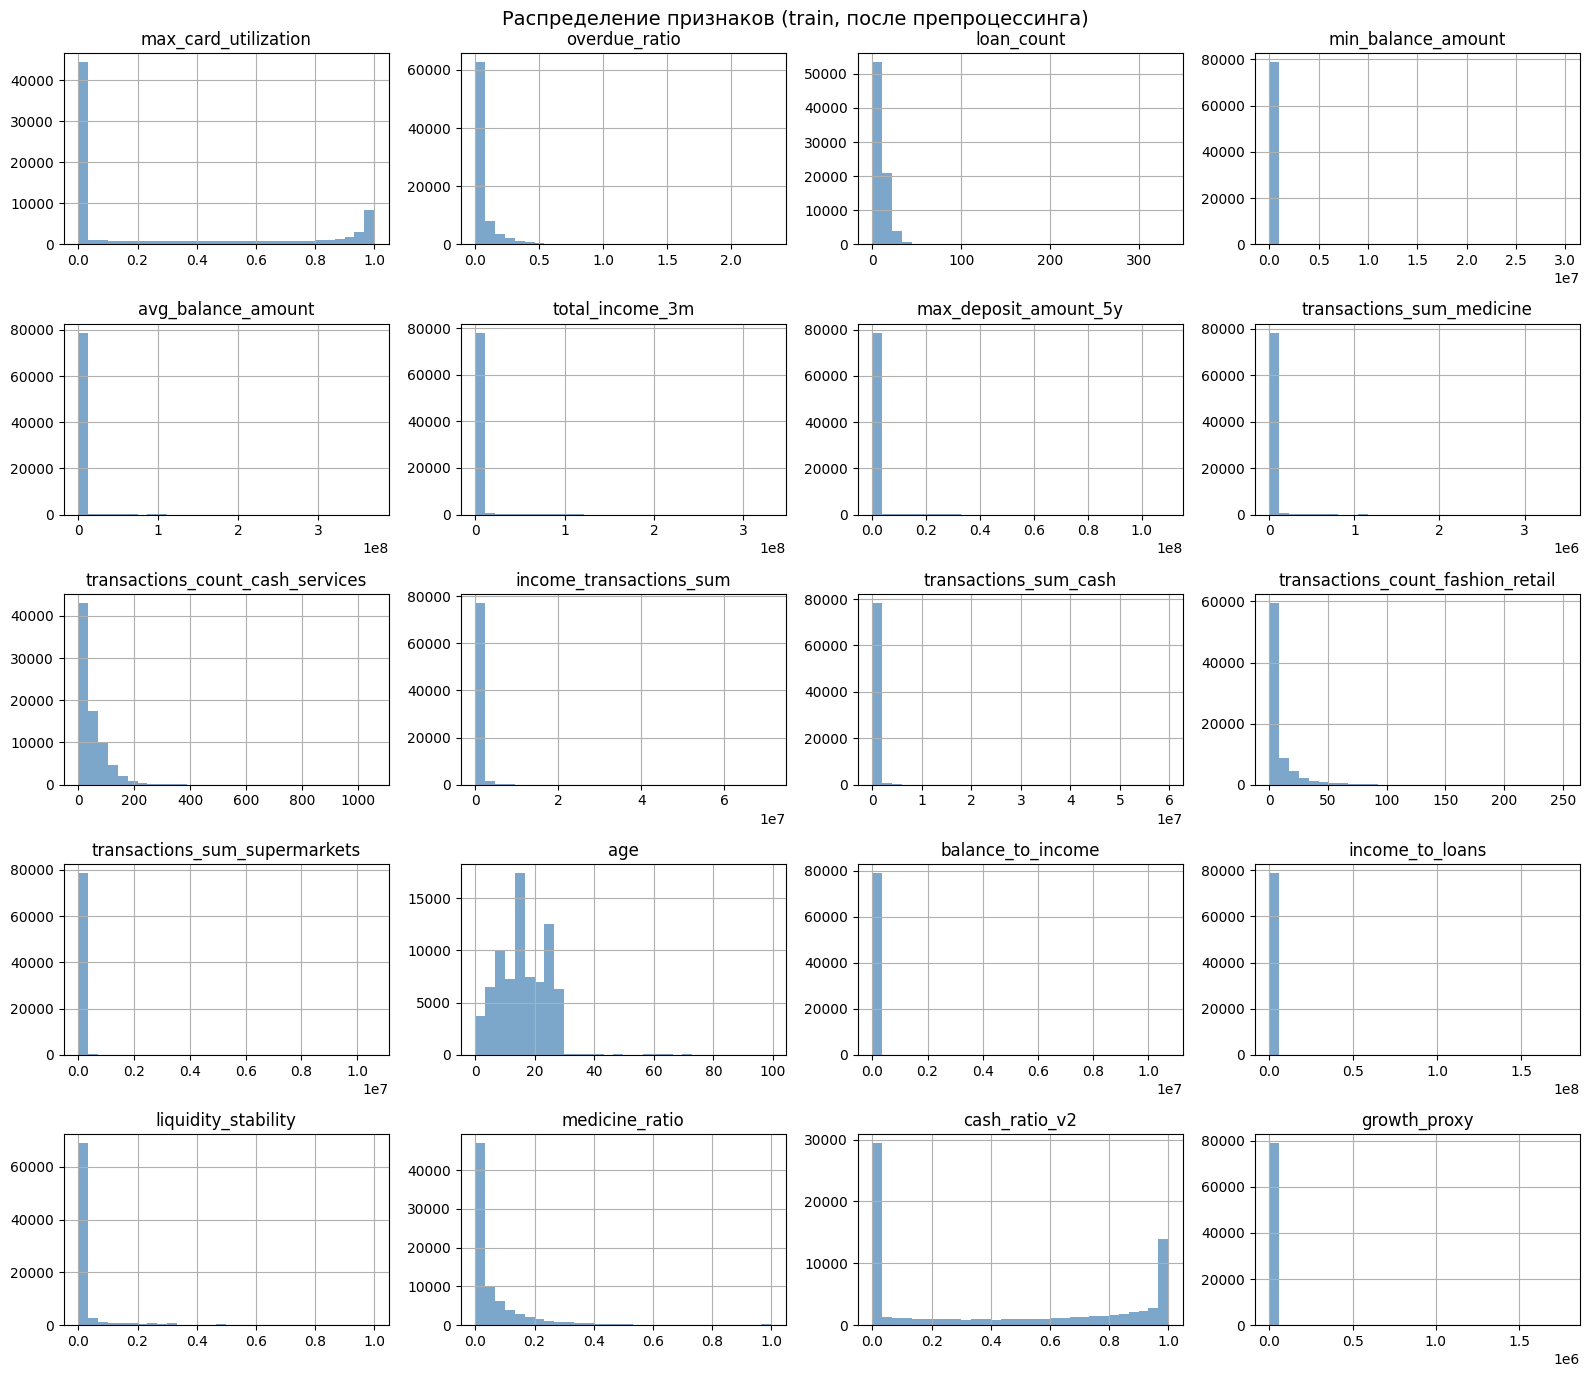

In [29]:
# Гистограммы распределений признаков 
X_train.hist(bins=30, figsize=(16, 14), alpha=0.7, color='steelblue')
plt.suptitle('Распределение признаков (train, после препроцессинга)', fontsize=14)
plt.tight_layout()
plt.show()

Индивидуальная предсказательная сила факторов (Gini):
                                     Gini
overdue_ratio                      0.3345
avg_balance_amount                 0.2123
max_card_utilization               0.2120
min_balance_amount                 0.2103
balance_to_income                  0.1836
transactions_sum_medicine          0.1559
transactions_count_fashion_retail  0.1372
medicine_ratio                     0.1253
growth_proxy                       0.1223
transactions_sum_supermarkets      0.0961
income_to_loans                    0.0924
total_income_3m                    0.0862
liquidity_stability                0.0811
max_deposit_amount_5y              0.0670
loan_count                         0.0529
age                                0.0495
income_transactions_sum            0.0400
cash_ratio_v2                      0.0370
transactions_count_cash_services   0.0278
transactions_sum_cash              0.0050


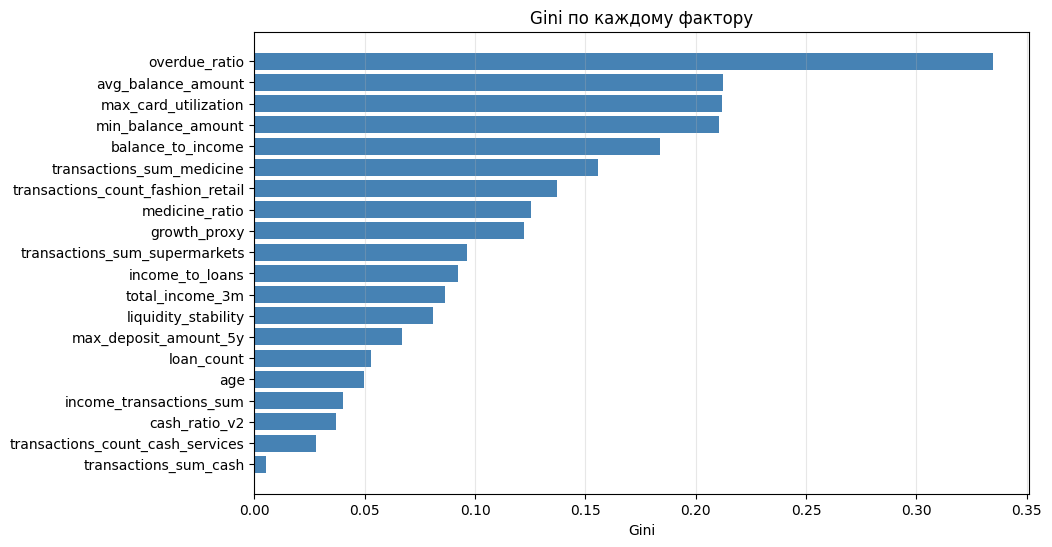

In [30]:
# Считаем индивидуальный Gini для каждого признака.
# Gini = 2 * ROC-AUC - 1. Показывает, насколько один признак сам по себе
# предсказывает дефолт. Это помогает понять, какие переменные несут информацию

factor_gini = {}

for col in X_train.columns:
    try:
        auc = roc_auc_score(y_train, X_train[col])
        auc = max(auc, 1 - auc)
        factor_gini[col] = round(2 * auc - 1, 4)
    except:
        factor_gini[col] = 0.0

factor_gini_df = pd.DataFrame.from_dict(
    factor_gini, orient='index', columns=['Gini']
).sort_values('Gini', ascending=False)

print("Индивидуальная предсказательная сила факторов (Gini):")
print(factor_gini_df)

plt.figure(figsize=(10, 6))
plt.barh(factor_gini_df.index, factor_gini_df['Gini'], color='steelblue')
plt.xlabel('Gini')
plt.title('Gini по каждому фактору')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.show()

                              feature       VIF
9             income_transactions_sum  2.989405
13                                age  2.887484
5                     total_income_3m  2.816641
2                          loan_count  2.669080
10              transactions_sum_cash  2.274933
15                    income_to_loans  2.270689
18                      cash_ratio_v2  2.268340
8    transactions_count_cash_services  2.214238
4                  avg_balance_amount  1.968935
6               max_deposit_amount_5y  1.966282
11  transactions_count_fashion_retail  1.858791
12      transactions_sum_supermarkets  1.721275
0                max_card_utilization  1.714021
7           transactions_sum_medicine  1.587885
17                     medicine_ratio  1.541697
1                       overdue_ratio  1.308000
3                  min_balance_amount  1.254606
16                liquidity_stability  1.131831
19                       growth_proxy  1.003842
14                  balance_to_income  1

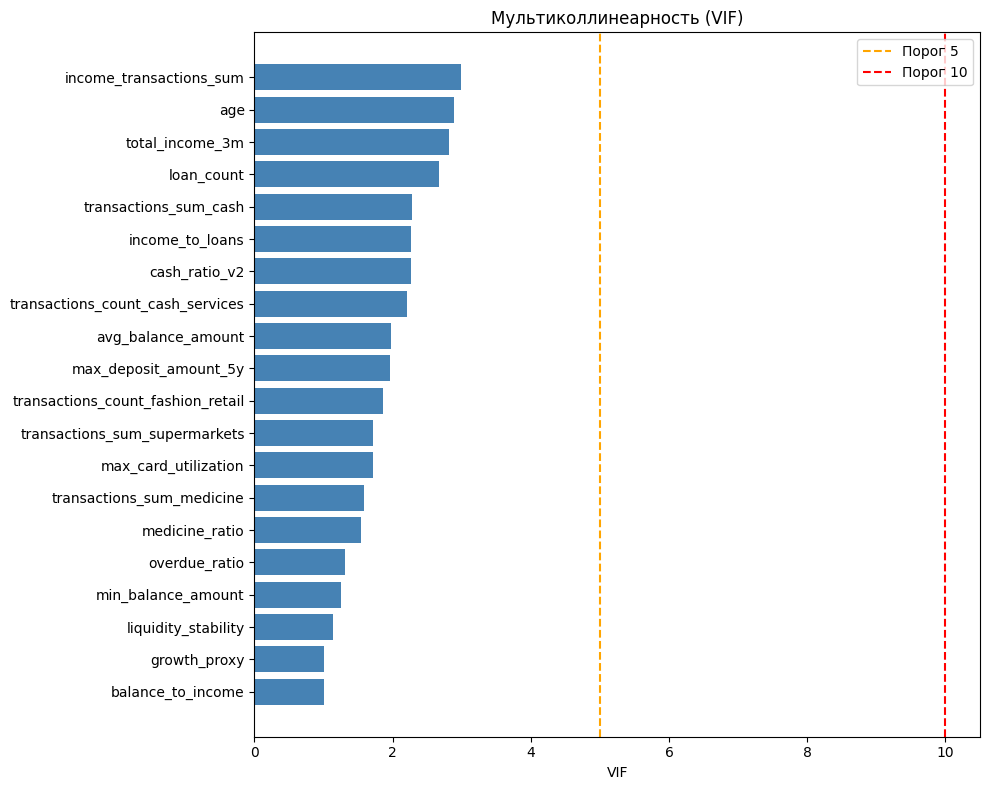

In [31]:
# VIF (Variance Inflation Factor) — мера мультиколлинеарности.
# Если два признака сильно коррелируют, они несут одну и ту же информацию,
# и модель может работать нестабильно.
# VIF > 10 — признак почти полностью объясняется другими признаками.


from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['feature'] = X_train.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]
vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data)

plt.figure(figsize=(10, 8))
plt.barh(vif_data['feature'], vif_data['VIF'], color='steelblue')
plt.axvline(x=5,  color='orange', linestyle='--', label='Порог 5')
plt.axvline(x=10, color='red',    linestyle='--', label='Порог 10')
plt.xlabel('VIF')
plt.title('Мультиколлинеарность (VIF)')
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

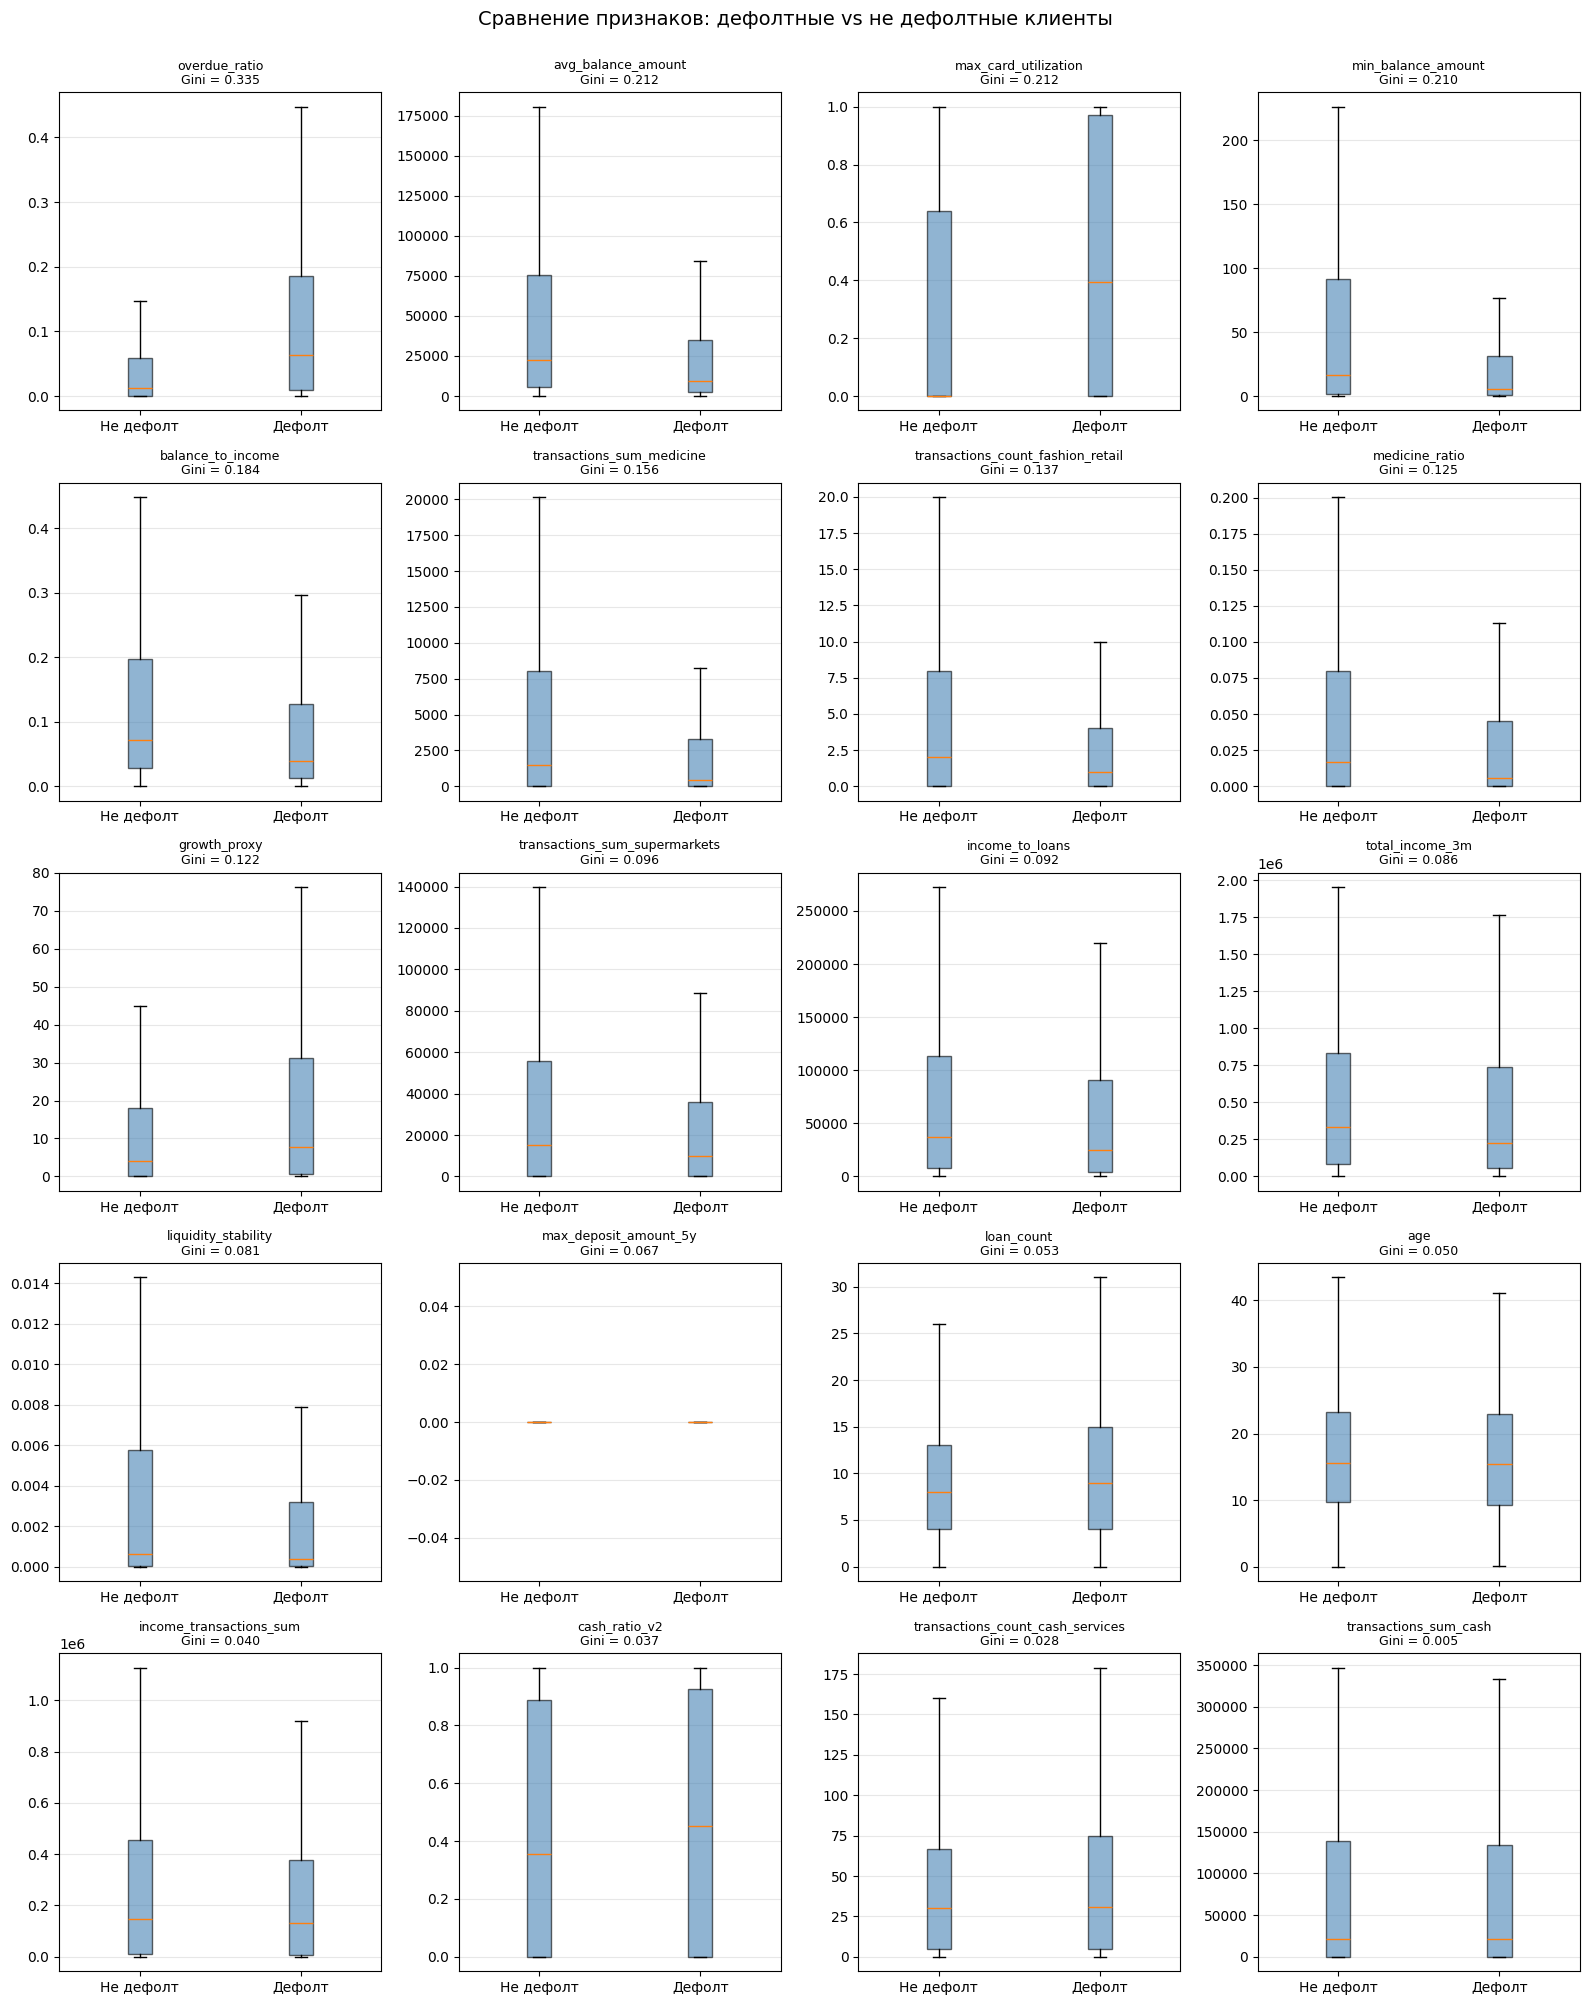

In [32]:
top_features = factor_gini_df.index.tolist()

n = len(top_features)
ncols = 4
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*4))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    data_good = X_train[feature][y_train == 0]
    data_bad  = X_train[feature][y_train == 1]

    axes[i].boxplot([data_good, data_bad], labels=['Не дефолт', 'Дефолт'],
                     showfliers=False, patch_artist=True,
                     boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{feature}\nGini = {factor_gini_df.loc[feature, "Gini"]:.3f}', fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Сравнение признаков: дефолтные vs не дефолтные клиенты', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

### Комментарий 

overdue_ratio (Gini = 0.335) — самый информативный признак. У дефолтных клиентов медиана и разброс выше — больше просрочек.


avg_balance_amount (Gini = 0.212) — у недефолтных клиентов средний баланс значительно выше. Дефолтные держат меньше денег на счёте.


max_card_utilization (Gini = 0.212) — у дефолтных клиентов утилизация карты выше и разброс больше — используют почти весь лимит.


min_balance_amount (Gini = 0.210) — аналогично avg_balance: у недефолтных минимальный остаток выше.


balance_to_income (Gini = 0.184) — у недефолтных клиентов баланс относительно дохода выше — лучше финансовая подушка.


transactions_sum_medicine (Gini = 0.156) — недефолтные тратят на медицину больше. Возможно, дефолтные просто не могут себе это позволить.


transactions_count_fashion_retail (Gini = 0.137) — недефолтные совершают больше покупок в fashion. Косвенный признак платёжеспособности.


medicine_ratio (Gini = 0.125) — доля трат на медицину выше у недефолтных клиентов.


growth_proxy (Gini = 0.122) — у дефолтных клиентов поступления относительно баланса выше — парадоксально, но может означать что баланс очень маленький.


transactions_sum_supermarkets (Gini = 0.096) — недефолтные тратят на супермаркеты больше.


income_to_loans (Gini = 0.092) — у недефолтных доход на один кредит выше — меньше финансовая нагрузка.

In [33]:
# Проверяем дисбаланс классов в train и val.

print(f"Дефолтов в train:   {y_train.mean()*100:.2f}%")
print(f"Дефолтов в val:     {y_val.mean()*100:.2f}%")

Дефолтов в train:   1.42%
Дефолтов в val:     1.43%


## 4. Отбор признаков (RFECV)

RFECV (Recursive Feature Elimination with Cross-Validation) — метод рекурсивного отбора признаков.

In [34]:
# Запускаем RFECV с логистической регрессией.
# n_splits=5 — стандарт
# n_jobs=-1 — используем все доступные ядра процессора.

selector = RFECV(
    estimator=LogisticRegression(max_iter=1000),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    min_features_to_select=1,
    n_jobs=-1,
)
selector.fit(X_train_scaled, y_train)

RFECV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
      estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
      scoring='roc_auc')

In [35]:
selected_features = X_train.columns[selector.support_].tolist()
print(f"Оптимальное число признаков: {selector.n_features_}")
print(f"Отобранные признаки: {selected_features}")

Оптимальное число признаков: 8
Отобранные признаки: ['max_card_utilization', 'overdue_ratio', 'min_balance_amount', 'transactions_sum_medicine', 'transactions_count_cash_services', 'transactions_count_fashion_retail', 'transactions_sum_supermarkets', 'medicine_ratio']


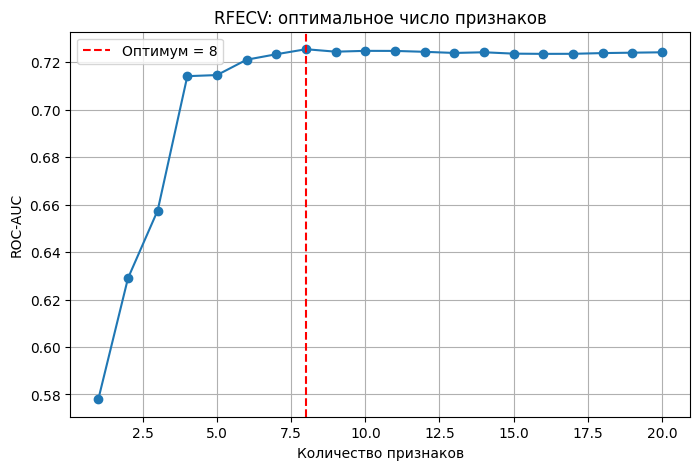

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(selector.cv_results_['mean_test_score']) + 1),
         selector.cv_results_['mean_test_score'], marker='o')
plt.axvline(selector.n_features_, color='red', linestyle='--',
            label=f'Оптимум = {selector.n_features_}')
plt.xlabel('Количество признаков')
plt.ylabel('ROC-AUC')
plt.title('RFECV: оптимальное число признаков')
plt.legend()
plt.grid(True)
plt.show()

## 5. Логистическая регрессия

Простая линейная модель, которая легко интерпретируется.

### 5.1 Анализ кросс-валидации при разных k фолдов

Исследуем, как число фолдов влияет на оценку качества модели.

- **Sharpe ratio** — среднее ROC-AUC, делённое на стандартное отклонение. Чем выше, тем стабильнее модель относительно её средней точности.
- **VaR 95%** — нижняя граница, ниже которой ROC-AUC падает только в 5% случаев.
- **t-статистика** — проверяем, значимо ли ROC-AUC лучше 0.5 (случайной модели).

In [37]:
# Проверяем k от 2 до 20.

model_lr_base = LogisticRegression(max_iter=1000)

k_values = [2, 3, 5, 10, 15, 20]
means, stds = [], []

for k in k_values:
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(model_lr_base, X_train_scaled[selected_features], y_train,
                             cv=cv, scoring='roc_auc')
    means.append(scores.mean())
    stds.append(scores.std())
    print(f"k={k}: mean={scores.mean():.4f}, std={scores.std():.4f}")

means = np.array(means)
stds  = np.array(stds)

k=2: mean=0.7247, std=0.0092
k=3: mean=0.7266, std=0.0082
k=5: mean=0.7260, std=0.0128
k=10: mean=0.7263, std=0.0169
k=15: mean=0.7267, std=0.0249
k=20: mean=0.7267, std=0.0322


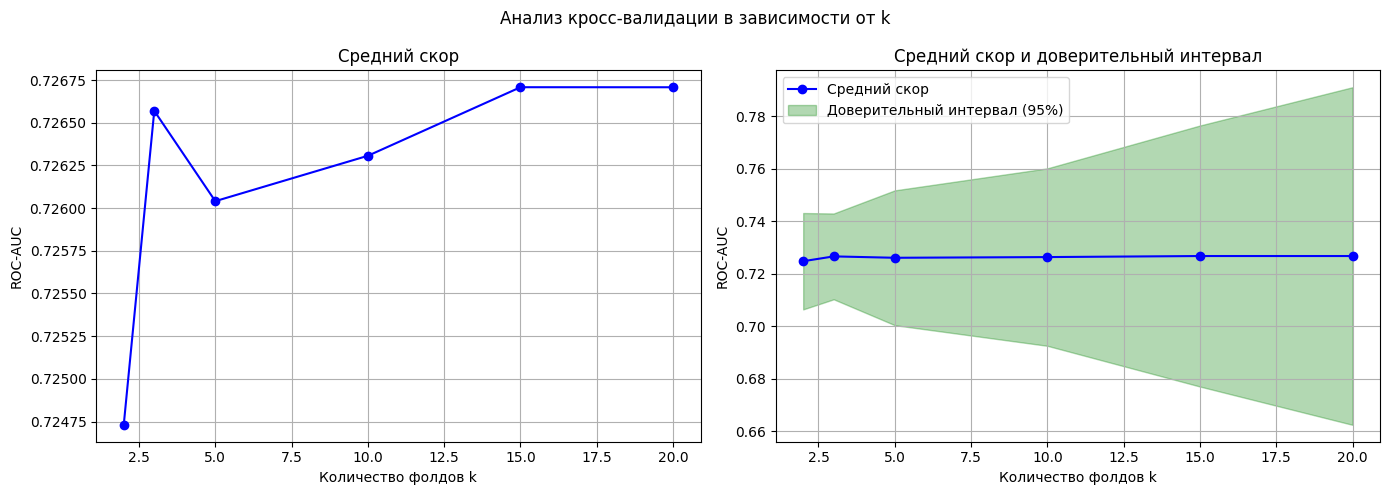

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, means, marker='o', color='blue')
axes[0].set_xlabel('Количество фолдов k')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('Средний скор')
axes[0].grid(True)

axes[1].plot(k_values, means, marker='o', color='blue', label='Средний скор')
axes[1].fill_between(k_values, means - 2*stds, means + 2*stds,
                     alpha=0.3, color='green', label='Доверительный интервал (95%)')
axes[1].set_xlabel('Количество фолдов k')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('Средний скор и доверительный интервал')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Анализ кросс-валидации в зависимости от k')
plt.tight_layout()
plt.show()

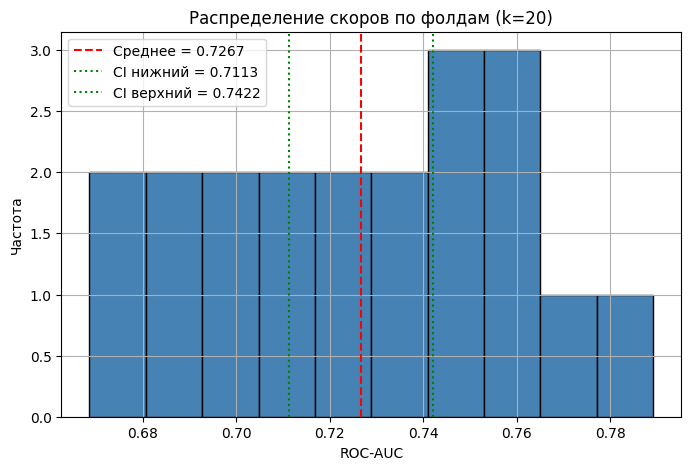

Среднее: 0.7267
95% доверительный интервал: [0.7113, 0.7422]


In [39]:
best_model_lr = LogisticRegression(max_iter=1000)
cv20 = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)
scores20 = cross_val_score(best_model_lr, X_train_scaled[selected_features], y_train,
                           cv=cv20, scoring='roc_auc')

ci = stats.t.interval(0.95, df=len(scores20)-1,
                      loc=scores20.mean(), scale=stats.sem(scores20))

plt.figure(figsize=(8, 5))
plt.hist(scores20, bins=10, color='steelblue', edgecolor='black')
plt.axvline(scores20.mean(), color='red', linestyle='--',
            label=f'Среднее = {scores20.mean():.4f}')
plt.axvline(ci[0], color='green', linestyle=':', label=f'CI нижний = {ci[0]:.4f}')
plt.axvline(ci[1], color='green', linestyle=':', label=f'CI верхний = {ci[1]:.4f}')
plt.xlabel('ROC-AUC')
plt.ylabel('Частота')
plt.title('Распределение скоров по фолдам (k=20)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Среднее: {scores20.mean():.4f}")
print(f"95% доверительный интервал: [{ci[0]:.4f}, {ci[1]:.4f}]")

In [40]:
# Высокий Sharpe означает, что модель стабильно хорошо работает на разных фолдах.
# Низкий Sharpe означает, что модель нестабильна, результат сильно зависит от разбивки данных.

sharpe = scores20.mean() / scores20.std()
print(f"Sharpe ratio: {sharpe:.4f}")

Sharpe ratio: 22.5941


In [41]:
var_95 = np.percentile(scores20, 5)
print(f"VaR 95%: {var_95:.4f}")

VaR 95%: 0.6795


In [42]:
# t-тест проверяет, значимо ли ROC-AUC отличается от случайной модели.
# Если p-value < 0.05 — с вероятностью 95% модель работает лучше случайной.

t_stat, p_value = stats.ttest_1samp(scores20, popmean=0.5)
print(f"t-статистика: {t_stat:.4f}")
print(f"p-value:      {p_value:.6f}")

t-статистика: 30.7241
p-value:      0.000000


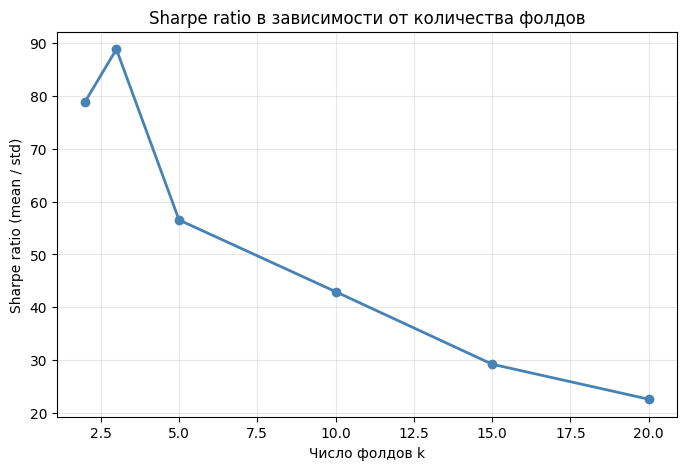

In [43]:
sharpe_by_k = [m / s for m, s in zip(means, stds)]

plt.figure(figsize=(8, 5))
plt.plot(k_values, sharpe_by_k, marker='o', color='steelblue', lw=2)
plt.xlabel('Число фолдов k')
plt.ylabel('Sharpe ratio (mean / std)')
plt.title('Sharpe ratio в зависимости от количества фолдов')
plt.grid(True, alpha=0.3)
plt.show()

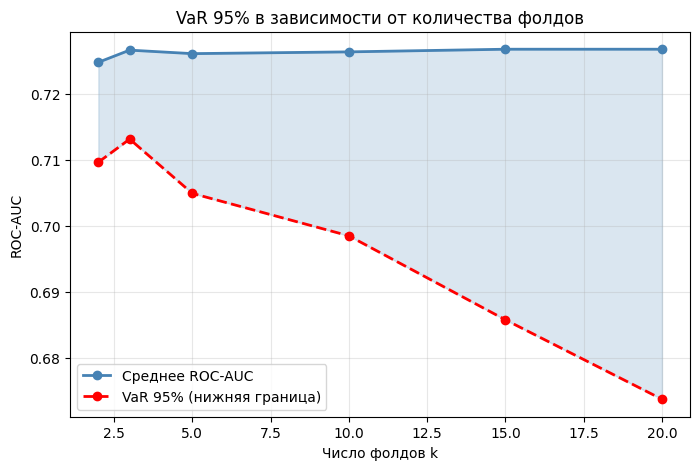

In [44]:
# VaR 95% для разных k — нижняя граница из доверительного интервала
var_by_k = [m - 1.645 * s for m, s in zip(means, stds)]  

plt.figure(figsize=(8, 5))
plt.plot(k_values, means, marker='o', color='steelblue', lw=2, label='Среднее ROC-AUC')
plt.plot(k_values, var_by_k, marker='o', color='red', lw=2, linestyle='--', label='VaR 95% (нижняя граница)')
plt.fill_between(k_values, var_by_k, means, alpha=0.2, color='steelblue')
plt.xlabel('Число фолдов k')
plt.ylabel('ROC-AUC')
plt.title('VaR 95% в зависимости от количества фолдов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

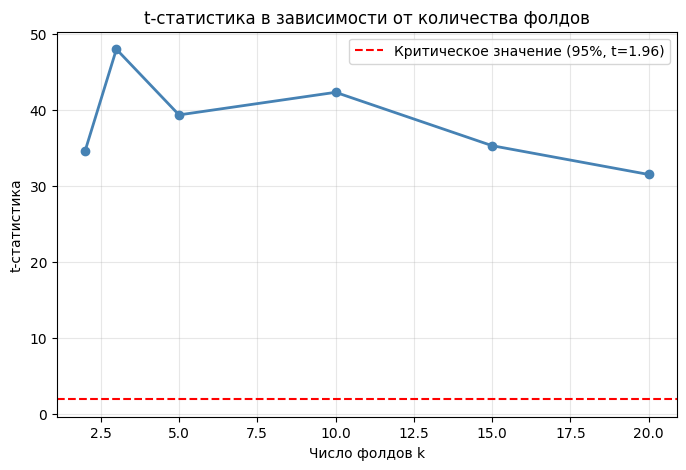

In [45]:
# t-статистика для разных k 
t_stats_by_k = [(m - 0.5) / (s / np.sqrt(k)) for m, s, k in zip(means, stds, k_values)]

plt.figure(figsize=(8, 5))
plt.plot(k_values, t_stats_by_k, marker='o', color='steelblue', lw=2)
plt.axhline(1.96, color='red', linestyle='--', label='Критическое значение (95%, t=1.96)')
plt.xlabel('Число фолдов k')
plt.ylabel('t-статистика')
plt.title('t-статистика в зависимости от количества фолдов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5.2 GridSearch: подбор оптимального C и регуляризации

**C** — параметр регуляризации в логрегрессии. При маленьком C сильная регуляризация (модель проще, меньше переобучение). При большом C слабая регуляризация (модель точнее на train, но может переобучиться).

**penalty** — тип регуляризации:
- L2 (по умолчанию): штрафует за большие коэффициенты, но не обнуляет их.
- L1: может полностью обнулять коэффициенты.

In [46]:
# GridSearch перебирает все комбинации параметров и выбирает лучшую по CV.
# solver='liblinear' — солвер, который поддерживает оба L1 и L2.
# class_weight='balanced' — увеличивает вес дефолтных клиентов, компенсируя дисбаланс классов.

params_gs_lr = {
    'C':            np.logspace(-8, 3, 50),  
    'penalty':      ['l1', 'l2'],
    'max_iter':     [1000],
    'solver':       ['liblinear'],
    'class_weight': ['balanced'],
    'fit_intercept': [True]
}

GS_LR = GridSearchCV(
    LogisticRegression(),
    param_grid=params_gs_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)

GS_LR.fit(X_train_scaled[selected_features], y_train)

print(f"Лучшие параметры: {GS_LR.best_params_}")
print(f"Лучший ROC-AUC:   {GS_LR.best_score_:.4f}")

Лучшие параметры: {'C': np.float64(0.0014563484775012444), 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Лучший ROC-AUC:   0.7278


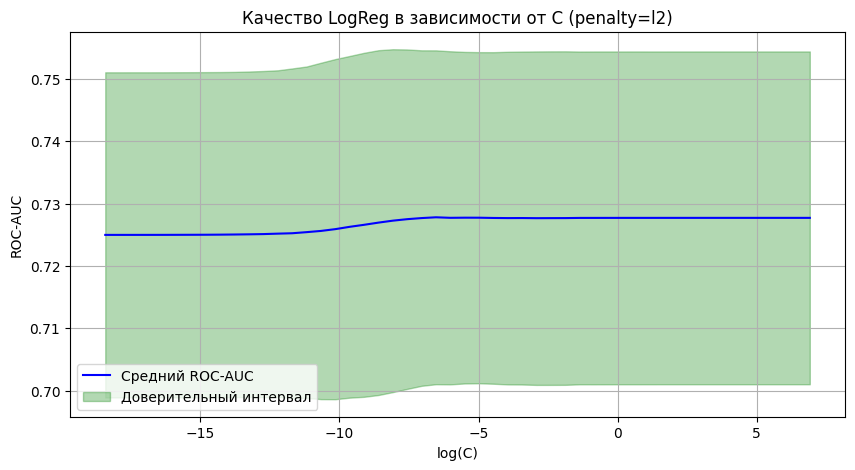

In [47]:
# График: качество в зависимости от C
means_gs = GS_LR.cv_results_['mean_test_score']
stds_gs  = GS_LR.cv_results_['std_test_score']
c_values = params_gs_lr['C']

l2_mask = [p['penalty'] == 'l2' for p in GS_LR.cv_results_['params']]
c_vals_l2 = [p['C'] for p, m in zip(GS_LR.cv_results_['params'], l2_mask) if m]
means_l2  = means_gs[l2_mask]
stds_l2   = stds_gs[l2_mask]

plt.figure(figsize=(10, 5))
plt.plot(np.log(c_vals_l2), means_l2, color='blue', label='Средний ROC-AUC')
plt.fill_between(np.log(c_vals_l2),
                 means_l2 - 1.95*stds_l2,
                 means_l2 + 1.95*stds_l2,
                 alpha=0.3, color='green', label='Доверительный интервал')
plt.xlabel('log(C)')
plt.ylabel('ROC-AUC')
plt.title('Качество LogReg в зависимости от C (penalty=l2)')
plt.legend()
plt.grid(True)
plt.show()

### 5.3 RandomizedSearch: расширенный поиск параметров

В отличие от GridSearch, RandomizedSearch не перебирает все комбинации, а случайно выбирает `n_iter` точек из пространства параметров. Это позволяет за то же время охватить более широкий диапазон значений.

In [48]:
# n_iter=30 — проверяем 30 случайных комбинаций. 

params_rs_lr = {
    'C':            np.logspace(-4, 3, 20),
    'penalty':      ['l1', 'l2'],
    'max_iter':     [500],
    'solver':       ['liblinear'],
    'class_weight': ['balanced']
}

RS_LR = RandomizedSearchCV(
    LogisticRegression(),
    param_distributions=params_rs_lr,
    n_iter=30,
    cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=42),
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

In [49]:
RS_LR.fit(X_train_scaled[selected_features], y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=2, random_state=42, shuffle=True),
                   estimator=LogisticRegression(), n_iter=30, n_jobs=-1,
                   param_distributions={'C': array([1.00000000e-04, 2.33572147e-04, 5.45559478e-04, 1.27427499e-03,
       2.97635144e-03, 6.95192796e-03, 1.62377674e-02, 3.79269019e-02,
       8.85866790e-02, 2.06913808e-01, 4.83293024e-01, 1.12883789e+00,
       2.63665090e+00, 6.15848211e+00, 1.43844989e+01, 3.35981829e+01,
       7.84759970e+01, 1.83298071e+02, 4.28133240e+02, 1.00000000e+03]),
                                        'class_weight': ['balanced'],
                                        'max_iter': [500],
                                        'penalty': ['l1', 'l2'],
                                        'solver': ['liblinear']},
                   random_state=42, scoring='roc_auc')

In [50]:
print(f"Лучшие параметры: {RS_LR.best_params_}")
print(f"Лучший ROC-AUC:   {RS_LR.best_score_:.4f}")

Лучшие параметры: {'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 500, 'class_weight': 'balanced', 'C': np.float64(1000.0)}
Лучший ROC-AUC:   0.7263


In [51]:
best_lr = RS_LR.best_estimator_
y_proba_lr = best_lr.predict_proba(X_val_scaled[selected_features])[:, 1]
print(f"ROC-AUC на валидации: {roc_auc_score(y_val, y_proba_lr):.4f}")

ROC-AUC на валидации: 0.7337


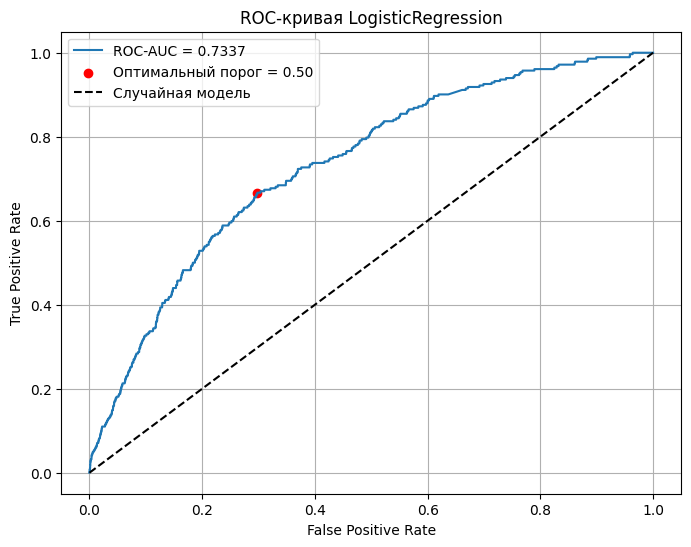

In [52]:
# ROC-кривая с оптимальным порогом
# Оптимальный порог находится в точке, где разница между TPR и FPR максимальна — это называется критерий Юдена.
fpr, tpr, thresholds = roc_curve(y_val, y_proba_lr)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_val, y_proba_lr):.4f}')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx],
            color='red', label=f'Оптимальный порог = {optimal_threshold:.2f}')
plt.plot([0,1],[0,1],'k--', label='Случайная модель')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая LogisticRegression')
plt.legend()
plt.grid(True)
plt.show()

In [53]:
# F1 — среднее между Precision и Recall
y_pred_05 = (y_proba_lr >= 0.5).astype(int)
y_pred_optimal = (y_proba_lr >= optimal_threshold).astype(int)  

print(f"F1 с порогом 0.5: {f1_score(y_val, y_pred_05):.4f}")
print(f"F1 с оптимальным порогом ({optimal_threshold:.2f}): {f1_score(y_val, y_pred_optimal):.4f}")

F1 с порогом 0.5: 0.0591
F1 с оптимальным порогом (0.50): 0.0599


In [54]:
print(f"\nПредсказано дефолтов при пороге 0.5: {y_pred_05.sum()}")
print(f"Предсказано дефолтов при оптимальном пороге ({optimal_threshold:.2f}): {y_pred_optimal.sum()}")
print(f"Реальных дефолтов в val: {y_val.sum()}")


Предсказано дефолтов при пороге 0.5: 6084
Предсказано дефолтов при оптимальном пороге (0.50): 5997
Реальных дефолтов в val: 282


In [55]:
from sklearn.metrics import precision_score, recall_score

# При пороге 0.5
print("Порог 0.5")
print(f"Предсказано дефолтов: {y_pred_05.sum()}")
print(f"Precision: {precision_score(y_val, y_pred_05, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_05):.4f}")

# При оптимальном пороге
print(f"\n Оптимальный порог ({optimal_threshold:.2f})")
print(f"Предсказано дефолтов: {y_pred_optimal.sum()}")
print(f"Precision: {precision_score(y_val, y_pred_optimal, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_optimal):.4f}")

print(f"\nРеальных дефолтов в val: {y_val.sum()}")

Порог 0.5
Предсказано дефолтов: 6084
Precision: 0.0309
Recall:    0.6667

 Оптимальный порог (0.50)
Предсказано дефолтов: 5997
Precision: 0.0313
Recall:    0.6667

Реальных дефолтов в val: 282


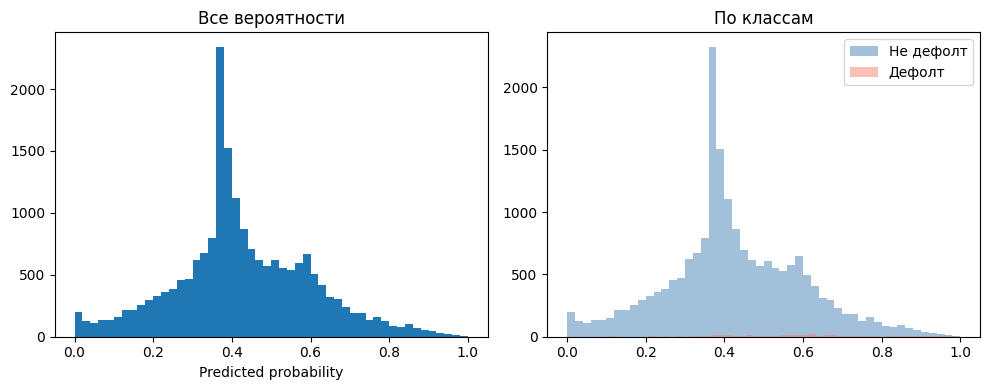

In [56]:
# Распределение вероятностей по классам
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(y_proba_lr, bins=50)
plt.title('Все вероятности')
plt.xlabel('Predicted probability')

plt.subplot(1, 2, 2)
plt.hist(y_proba_lr[y_val==0], bins=50, alpha=0.5, label='Не дефолт', color='steelblue')
plt.hist(y_proba_lr[y_val==1], bins=50, alpha=0.5, label='Дефолт', color='salmon')
plt.title('По классам')
plt.legend()
plt.tight_layout()
plt.show()

ROC-AUC после калибровки: 0.7337


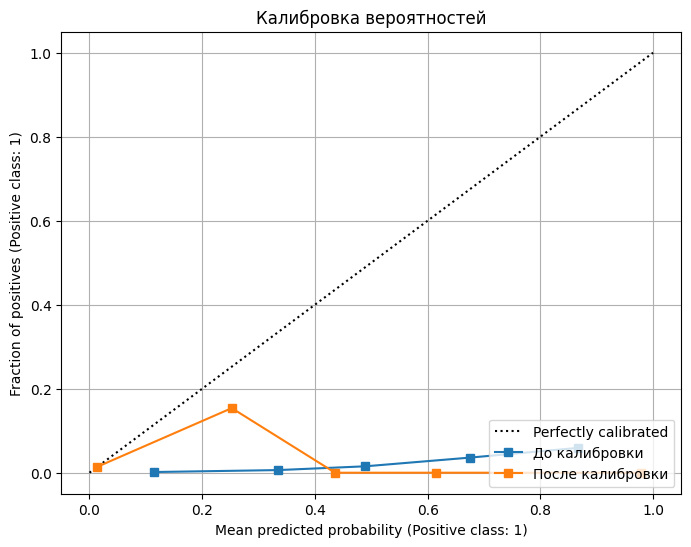

In [57]:
# Калибровка вероятностей: корректируем шкалу, чтобы вероятность 0.3
# действительно означала "30% клиентов с таким скором имеют дефолт".
# method='sigmoid' — подходит для логрегрессии.
# cv='prefit' — модель уже обучена, только калибруем.
# Обучаем калибровку на val.

calibrated_model = CalibratedClassifierCV(best_lr, method='sigmoid', cv='prefit')
calibrated_model.fit(X_val_scaled[selected_features], y_val) 

y_proba_cal = calibrated_model.predict_proba(X_val_scaled[selected_features])[:, 1]
print(f"ROC-AUC после калибровки: {roc_auc_score(y_val, y_proba_cal):.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(y_val, y_proba_lr,  n_bins=5, ax=ax, label='До калибровки')
CalibrationDisplay.from_predictions(y_val, y_proba_cal, n_bins=5, ax=ax, label='После калибровки')
plt.title('Калибровка вероятностей')
plt.grid(True)
plt.show()

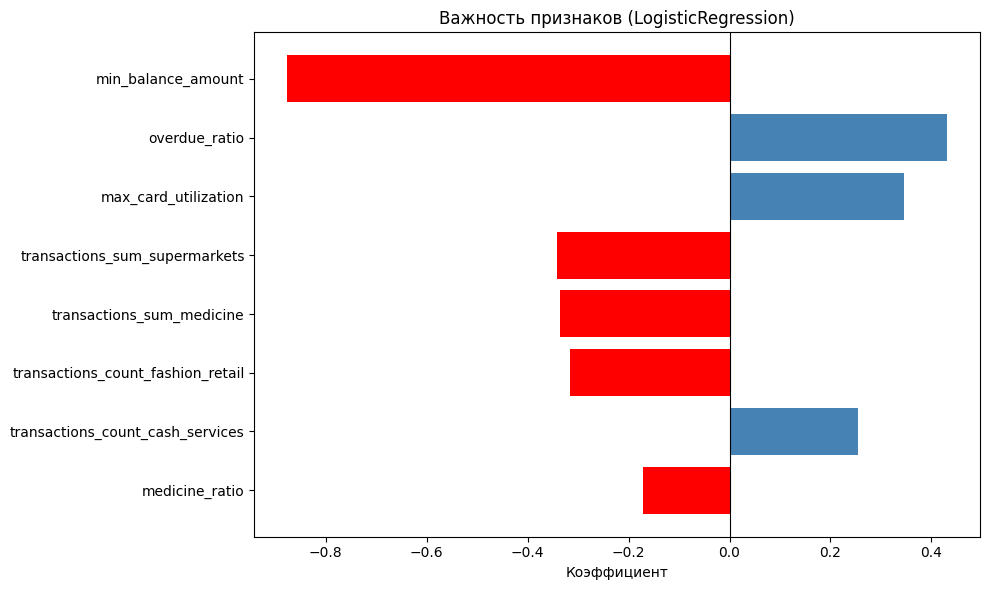

In [58]:
# Важность признаков по коэффициентам
importance_lr = pd.DataFrame({
    'feature':     selected_features,
    'coefficient': best_lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

colors = ['red' if c < 0 else 'steelblue' for c in importance_lr['coefficient']]
plt.figure(figsize=(10, 6))
plt.barh(importance_lr['feature'], importance_lr['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Коэффициент')
plt.title('Важность признаков (LogisticRegression)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 5.4 Логистическая регрессия с полиномиальными признаками

Логрегрессия — линейная модель. Она умеет улавливать только прямые зависимости, например, "чем больше X, тем больше вероятность дефолта". Но связь может быть нелинейной.

Полиномиальные признаки (interaction_only=True) — это попарные произведения исходных признаков: X1×X2, X1×X3 и т.д. Они позволяют модели уловить совместное влияние двух переменных.

In [59]:
# Топ-10 признаков по Gini для полиномов
top10_features = factor_gini_df.head(10).index.tolist()
print(f"Признаки для полиномов: {top10_features}")

pf = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
poly_features = pf.fit_transform(X_train_scaled[top10_features])
df_poly = pd.DataFrame(
    poly_features,
    columns=pf.get_feature_names_out(top10_features),
    index=X_train_scaled.index
)

Признаки для полиномов: ['overdue_ratio', 'avg_balance_amount', 'max_card_utilization', 'min_balance_amount', 'balance_to_income', 'transactions_sum_medicine', 'transactions_count_fashion_retail', 'medicine_ratio', 'growth_proxy', 'transactions_sum_supermarkets']


In [60]:
selector_poly = RFECV(
    estimator=LogisticRegression(max_iter=500, C=1, solver='liblinear'),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc',
    min_features_to_select=1,
    step=5,
    n_jobs=-1
)
selector_poly.fit(df_poly, y_train)

RFECV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
      estimator=LogisticRegression(C=1, max_iter=500, solver='liblinear'),
      n_jobs=-1, scoring='roc_auc', step=5)

In [61]:
selected_poly_features = df_poly.columns[selector_poly.support_].tolist()
print(f"Оптимальное число признаков: {selector_poly.n_features_}")

Оптимальное число признаков: 15


In [62]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model_poly = LogisticRegression(max_iter=1000, C=1, solver='liblinear')
scores_poly = cross_val_score(model_poly, df_poly[selected_poly_features], y_train,
                              cv=cv5, scoring='roc_auc')

print(f"ROC-AUC с полиномами:  {scores_poly.mean():.4f} ± {scores_poly.std():.4f}")

ROC-AUC с полиномами:  0.7171 ± 0.0087


In [63]:
X_val_poly = pd.DataFrame(
    pf.transform(X_val_scaled[top10_features]),
    columns=pf.get_feature_names_out(top10_features),
    index=X_val_scaled.index
)
df_test_poly = pd.DataFrame(
    pf.transform(df_test_scaled[top10_features]),
    columns=pf.get_feature_names_out(top10_features),
    index=df_test_scaled.index
)

In [64]:
model_poly = LogisticRegression(max_iter=1000, C=1, solver='liblinear')
model_poly.fit(df_poly[selected_poly_features], y_train)

y_proba_poly = model_poly.predict_proba(X_val_poly[selected_poly_features])[:, 1]
print(f"ROC-AUC на val: {roc_auc_score(y_val, y_proba_poly):.4f}")

ROC-AUC на val: 0.7274


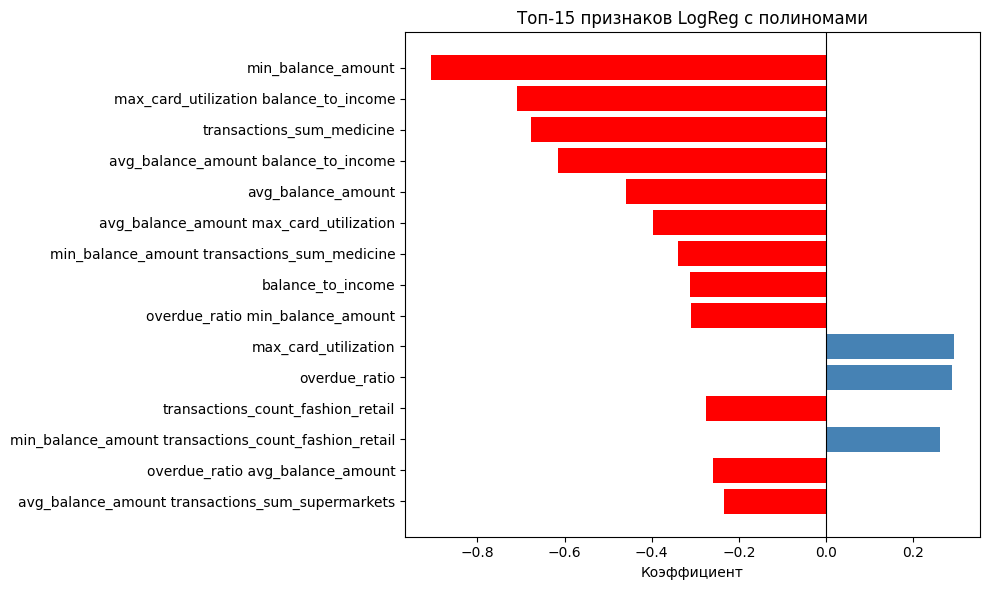

In [65]:
importance_poly = pd.DataFrame({
    'feature':     selected_poly_features,
    'coefficient': model_poly.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(15)

colors = ['red' if c < 0 else 'steelblue' for c in importance_poly['coefficient']]
plt.figure(figsize=(10, 6))
plt.barh(importance_poly['feature'], importance_poly['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Коэффициент')
plt.title('Топ-15 признаков LogReg с полиномами')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

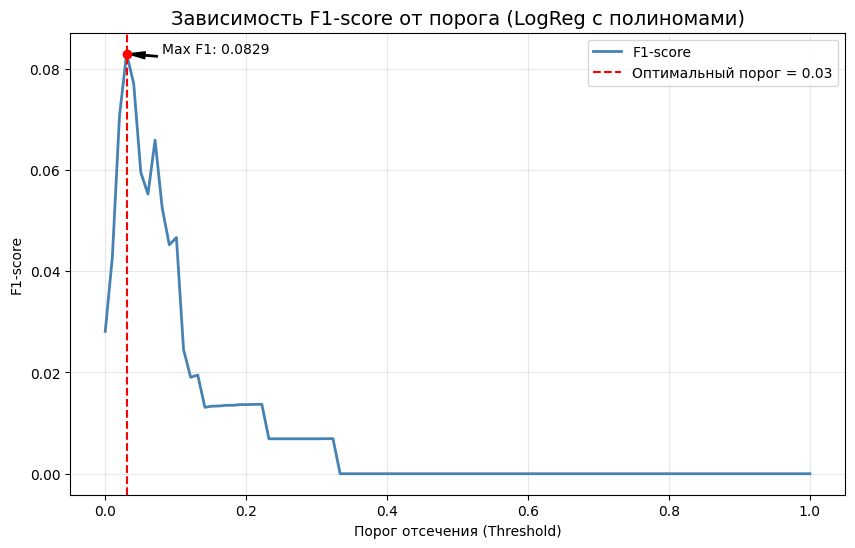

Лучший порог:                        0.03
Максимальный F1:                     0.0829
Итоговый F1 при оптимальном пороге:  0.0829


In [66]:
# Ищем порог, при котором F1 максимален
y_proba_poly = model_poly.predict_proba(X_val_poly[selected_poly_features])[:, 1]  # ← X_val_poly!

thresholds = np.linspace(0, 1, 100)
f1_scores_thresh = [f1_score(y_val, y_proba_poly >= t) for t in thresholds]
best_f1 = max(f1_scores_thresh)
best_threshold = thresholds[np.argmax(f1_scores_thresh)]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores_thresh, label='F1-score', color='steelblue', lw=2)
plt.axvline(best_threshold, color='red', linestyle='--',
            label=f'Оптимальный порог = {best_threshold:.2f}')
plt.scatter(best_threshold, best_f1, color='red', zorder=5)
plt.title('Зависимость F1-score от порога (LogReg с полиномами)', fontsize=14)
plt.xlabel('Порог отсечения (Threshold)')
plt.ylabel('F1-score')
plt.annotate(f'Max F1: {best_f1:.4f}',
             xy=(best_threshold, best_f1), xytext=(best_threshold+0.05, best_f1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Лучший порог:                        {best_threshold:.2f}")
print(f"Максимальный F1:                     {best_f1:.4f}")
print(f"Итоговый F1 при оптимальном пороге:  {f1_score(y_val, y_proba_poly >= best_threshold):.4f}")

In [67]:
print(f"Исходных признаков (топ-10): {len(top10_features)}")
print(f"После полиномиального преобразования: {df_poly.shape[1]}")
print(f"Новых признаков создано: {df_poly.shape[1] - len(top10_features)}")
print(f"Отобрано RFECV: {len(selected_poly_features)}")

Исходных признаков (топ-10): 10
После полиномиального преобразования: 55
Новых признаков создано: 45
Отобрано RFECV: 15


## 6. Дерево решений

Дерево решений — простая нелинейная модель. 

**Параметры, которые настраивали:**
- `max_depth` — максимальная глубина дерева. Слишком глубокое дерево хорошо запоминает обучающие данные, что ведет к переобучению.
- `min_samples_split` — минимальное число объектов для разбиения узла. Чем больше значение, тем меньше переобучение.
- `min_samples_leaf` — минимальное число объектов в листе. 

In [68]:
# max_depth [5, 7, 10]: глубже 10 дерево почти может переобучиться.
# min_samples_split [20, 35]: при малых выборках в листьях модель запоминает шум.
# min_samples_leaf [2, 6]: значение меньше 1 может привести к переобучению.

params_dt = {
    'max_depth':         [5, 7, 10],
    'min_samples_split': [20, 35],
    'min_samples_leaf':  [2, 6]
}

GS_dtc = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=params_dt,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)
GS_dtc.fit(X_train_scaled, y_train)

print(f"Лучшие параметры: {GS_dtc.best_params_}")
print(f"Лучший ROC-AUC:   {GS_dtc.best_score_:.4f}")

Лучшие параметры: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 35}
Лучший ROC-AUC:   0.7039


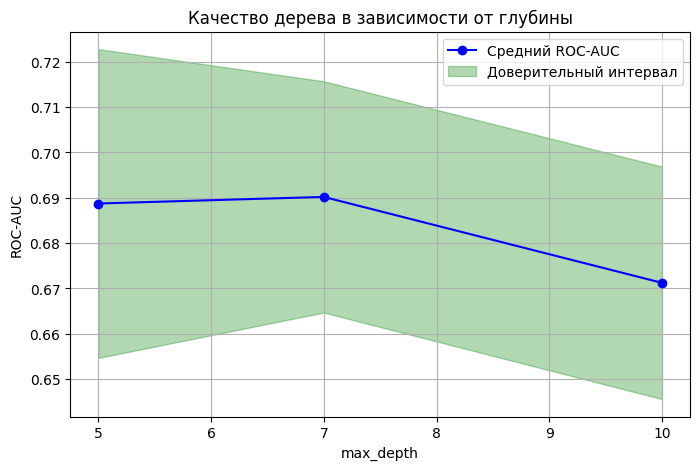

In [69]:
# График качества в зависимости от max_depth

depth_values = [5, 7, 10]
means_dt, stds_dt = [], []

for depth in depth_values:
    dtc = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(dtc, df.loc[X_train_scaled.index], y_train,
                             cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                             scoring='roc_auc')
    means_dt.append(scores.mean())
    stds_dt.append(scores.std())

means_dt = np.array(means_dt)
stds_dt  = np.array(stds_dt)

plt.figure(figsize=(8, 5))
plt.plot(depth_values, means_dt, marker='o', color='blue', label='Средний ROC-AUC')
plt.fill_between(depth_values, means_dt - 1.95*stds_dt, means_dt + 1.95*stds_dt,
                 alpha=0.3, color='green', label='Доверительный интервал')
plt.xlabel('max_depth')
plt.ylabel('ROC-AUC')
plt.title('Качество дерева в зависимости от глубины')
plt.legend()
plt.grid(True)
plt.show()

In [70]:
DT_model = GS_dtc.best_estimator_

# Оцениваем на val (используем X_val_scaled для единообразия)
y_proba_dt = DT_model.predict_proba(X_val_scaled)[:, 1]
print(f"ROC-AUC на val: {roc_auc_score(y_val, y_proba_dt):.4f}")

ROC-AUC на val: 0.6983


## 7. KNN (метод ближайших соседей)

KNN предсказывает класс объекта, глядя на k ближайших к нему объектов из обучающей выборки. Если среди 100 ближайших соседей 30 дефолтных — вероятность дефолта = 30%.

Для этого метода нужно масштабирование. KNN измеряет расстояния. Если один признак в рублях (0–10 млн), а другой — это доля (0–1), то признак в рублях будет доминировать в расстоянии. StandardScaler приводит все признаки к одному масштабу.

Параметр n_neighbors показывает, какое количсетво соседних значений мы используем для классификации данного. Использовала 100–145. При маленьком k модель может быть нестабильна.

In [71]:
params_knn = {'n_neighbors': np.arange(100, 150, 5)}

GS_kNN = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    param_grid=params_knn,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)
GS_kNN.fit(X_train_scaled[selected_features], y_train)

print(f"Лучшее k: {GS_kNN.best_params_}")
print(f"Лучший ROC-AUC: {GS_kNN.best_score_:.4f}")

Лучшее k: {'n_neighbors': np.int64(130)}
Лучший ROC-AUC: 0.6817


In [72]:
kNN_model = GS_kNN.best_estimator_

In [73]:
y_proba_knn = kNN_model.predict_proba(X_val_scaled[selected_features])[:, 1]
print(f"ROC-AUC на val: {roc_auc_score(y_val, y_proba_knn):.4f}")

ROC-AUC на val: 0.6856


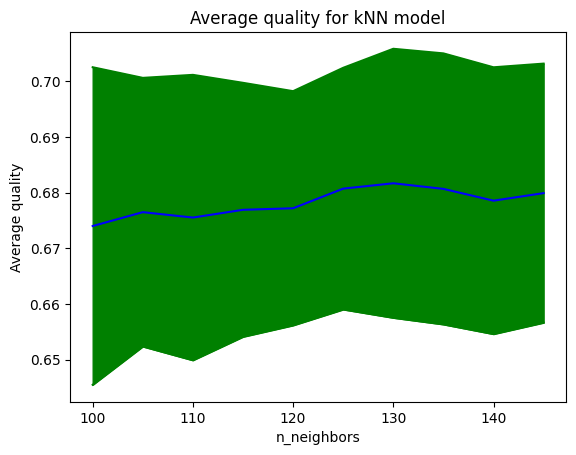

In [74]:
means = GS_kNN.cv_results_['mean_test_score']
stds = GS_kNN.cv_results_['std_test_score']
error = 1.95 * stds
plt.plot(params_knn['n_neighbors'], means, color = 'blue')
plt.plot(params_knn['n_neighbors'], means - error, color = 'green')
plt.plot(params_knn['n_neighbors'], means + error, color = 'green')
plt.fill_between(params_knn['n_neighbors'], means - error, means + error, color = 'green')
plt.xlabel('n_neighbors')
plt.ylabel('Average quality')
plt.title('Average quality for kNN model')
plt.show()

## 8. Случайный лес

Случайный лес — ансамбль из множества деревьев решений. Каждое дерево обучается на случайной подвыборке данных и случайном подмножестве признаков. Итоговое предсказание — это среднее по всем деревьям.

За счёт случайности деревья получаются разными и не коррелируют между собой, что снижает вероятнсоть переобучения.

**Параметры:**
- `max_depth` [5, 10]: ограничиваем глубину, чтобы деревья не переобучались индивидуально.
- `min_samples_split` [5, 10]: минимальный размер узла для разбиения.
- `min_samples_leaf` [2, 5]: минимальный размер листа.

In [75]:
params_rf = {
    'n_estimators':      [100],
    'max_depth':         [5, 10],
    'min_samples_split': [5, 10],
    'min_samples_leaf':  [2, 5]
}

GS_RF = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params_rf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
GS_RF.fit(X_train_scaled, y_train)

print(f"Лучшие параметры: {GS_RF.best_params_}")
print(f"Лучший ROC-AUC:   {GS_RF.best_score_:.4f}")

Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 100}
Лучший ROC-AUC:   0.7540


In [76]:
best_rf = GS_RF.best_estimator_
y_proba_rf = best_rf.predict_proba(X_val_scaled)[:, 1]
print(f"ROC-AUC на валидации: {roc_auc_score(y_val, y_proba_rf):.4f}")

ROC-AUC на валидации: 0.7570


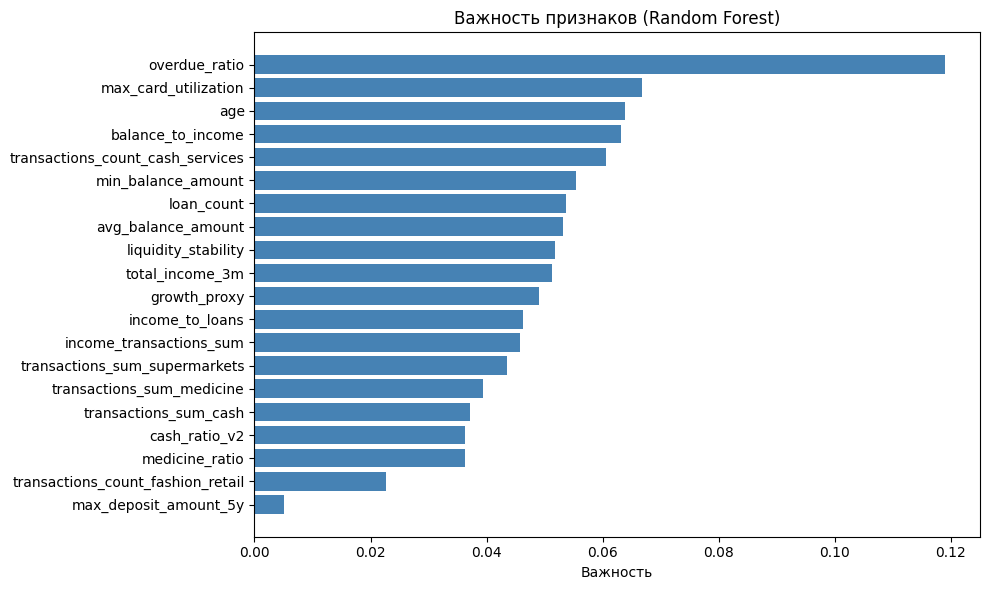

In [77]:
importance_rf = pd.DataFrame({
    'feature':    X_train_scaled.columns,  # ← все признаки на которых обучался RF
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_rf['feature'], importance_rf['importance'], color='steelblue')
plt.xlabel('Важность')
plt.title('Важность признаков (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. LightGBM

LightGBM — градиентный бустинг на деревьях. В отличие от случайного леса, где деревья строятся независимо, в бустинге каждое следующее дерево исправляет ошибки предыдущего.

LightGBM работает быстрее аналогов (XGBoost, CatBoost).

In [78]:
# scale_pos_weight — вес положительного класса.
# При дисбалансе 98.5% / 1.5% модель склонна предсказывать "нет дефолта" для всех.
# scale_pos_weight = число недефолтных / число дефолтных — компенсирует дисбаланс.
ratio = float(np.sum(y_train == 0) / np.sum(y_train == 1))

lgb_model = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    random_state=42,
    verbosity=-1,
    scale_pos_weight=ratio  
)

# Параметры для GridSearch:
# n_estimators: число деревьев.
# learning_rate: шаг обучения. Чем он меньше, тем больше нужно деревьев, но резульатат будет точнее.
# max_depth: глубина дерева. 
# num_leaves: число листьев. 
# min_child_samples: минимум объектов в листе — регуляризация.
param_grid_lgb = {
    'n_estimators':      [100, 300, 500],
    'learning_rate':     [0.01, 0.05],
    'max_depth':         [5, 7],
    'num_leaves':        [20, 31],
    'min_child_samples': [20, 50]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

GS_lgb = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid_lgb,
    scoring='roc_auc',     
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

In [79]:
GS_lgb.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LGBMClassifier(metric='auc', objective='binary',
                                      random_state=42,
                                      scale_pos_weight=69.28330373001776,
                                      verbosity=-1),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05], 'max_depth': [5, 7],
                         'min_child_samples': [20, 50],
                         'n_estimators': [100, 300, 500],
                         'num_leaves': [20, 31]},
             scoring='roc_auc', verbose=1)

In [80]:
# Вывод результатов
print(f"Лучшие параметры: {GS_lgb.best_params_}")
print(f"Лучший ROC-AUC на кросс-валидации: {GS_lgb.best_score_:.4f}")

# Сохраняем лучшую модель для последующей калибровки 
best_lgb_grid = GS_lgb.best_estimator_

Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 7, 'min_child_samples': 50, 'n_estimators': 300, 'num_leaves': 20}
Лучший ROC-AUC на кросс-валидации: 0.7543


In [81]:
best_lgb_grid = GS_lgb.best_estimator_
best_lgb_grid.fit(X_train_scaled, y_train)

y_proba_lgb_val = best_lgb_grid.predict_proba(X_val_scaled)[:, 1]
print(f"ROC-AUC LightGBM на val: {roc_auc_score(y_val, y_proba_lgb_val):.4f}")

ROC-AUC LightGBM на val: 0.7557


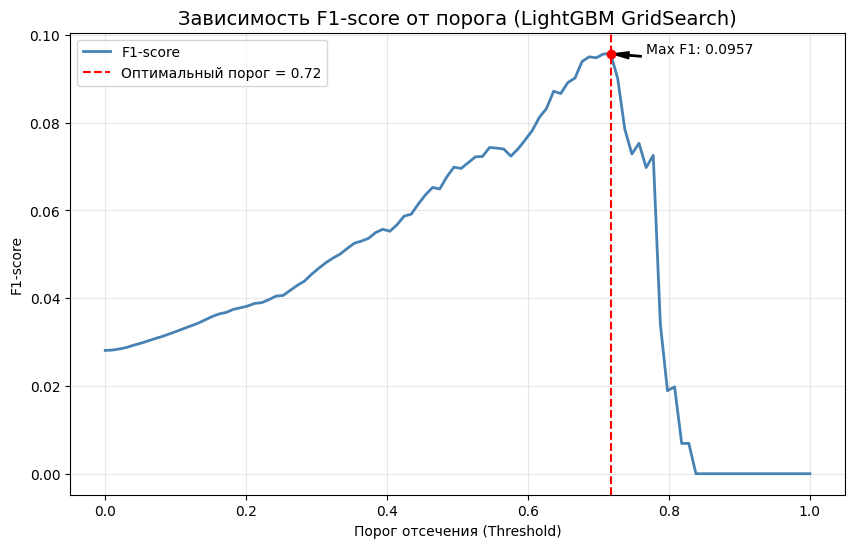

Лучший порог:                        0.72
Максимальный F1:                     0.0957
Итоговый F1 при оптимальном пороге:  0.0957


In [82]:
# Ищем порог, при котором F1 максимален
y_proba_lgb_val = best_lgb_grid.predict_proba(X_val_scaled)[:, 1]

thresholds = np.linspace(0, 1, 100)
f1_scores_thresh = [f1_score(y_val, y_proba_lgb_val >= t) for t in thresholds]
best_f1 = max(f1_scores_thresh)
best_threshold = thresholds[np.argmax(f1_scores_thresh)]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores_thresh, label='F1-score', color='steelblue', lw=2)
plt.axvline(best_threshold, color='red', linestyle='--',
            label=f'Оптимальный порог = {best_threshold:.2f}')
plt.scatter(best_threshold, best_f1, color='red', zorder=5)
plt.title('Зависимость F1-score от порога (LightGBM GridSearch)', fontsize=14)
plt.xlabel('Порог отсечения (Threshold)')
plt.ylabel('F1-score')
plt.annotate(f'Max F1: {best_f1:.4f}',
             xy=(best_threshold, best_f1), xytext=(best_threshold+0.05, best_f1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Лучший порог:                        {best_threshold:.2f}")
print(f"Максимальный F1:                     {best_f1:.4f}")
print(f"Итоговый F1 при оптимальном пороге:  {f1_score(y_val, y_proba_lgb_val >= best_threshold):.4f}")

In [83]:
print(f"\nСреднее: {y_proba_lgb_val.mean():.4f}")
print(f"Медиана: {np.median(y_proba_lgb_val):.4f}")
print(f"Max: {y_proba_lgb_val.max():.4f}")
print(f"95-й перцентиль: {np.percentile(y_proba_lgb_val, 95):.4f}")


Среднее: 0.3306
Медиана: 0.3093
Max: 0.8453
95-й перцентиль: 0.6852


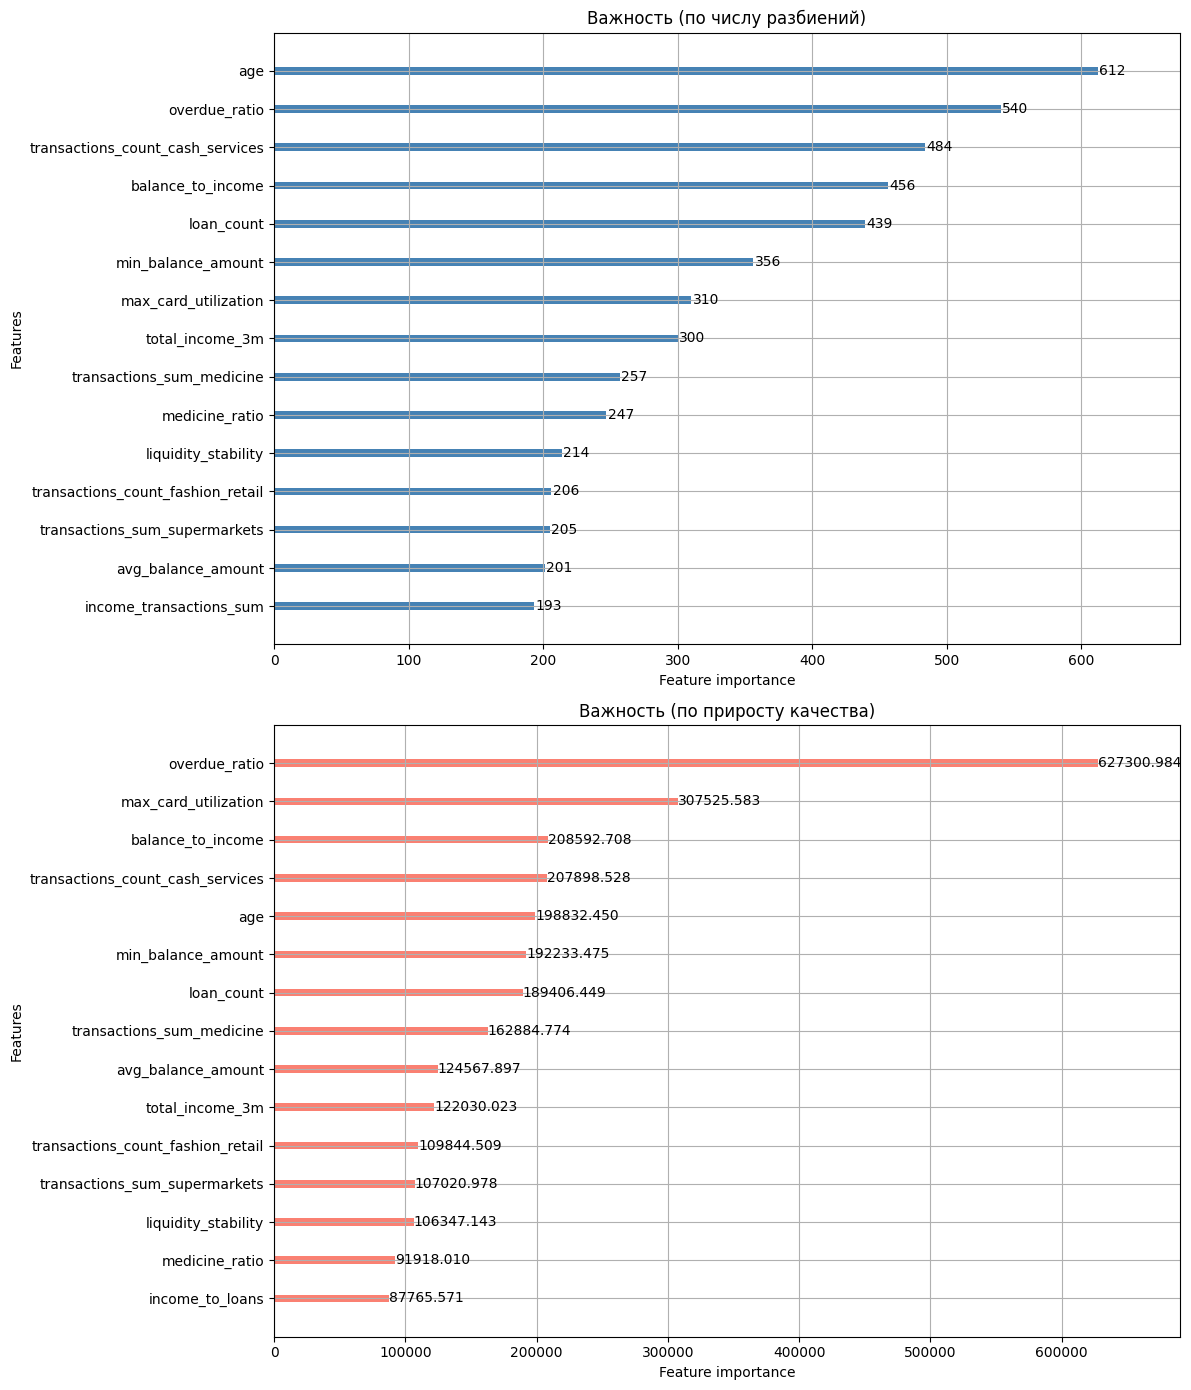

In [84]:
# Важность признаков LightGBM
fig, axes = plt.subplots(2, 1, figsize=(12, 14))
lgb.plot_importance(best_lgb_grid, max_num_features=15,
                    importance_type='split', ax=axes[0], color='steelblue')
axes[0].set_title('Важность (по числу разбиений)')

lgb.plot_importance(best_lgb_grid, max_num_features=15,
                    importance_type='gain', ax=axes[1], color='salmon')
axes[1].set_title('Важность (по приросту качества)')
plt.tight_layout()
plt.show()

### 9.1 Байесовская оптимизация LightGBM (Hyperopt)

Hyperopt после каждой итерации строит вероятностную модель (Tree Parzen Estimator), которая предсказывает, в каких областях пространства параметров скорее всего хорошие результаты.

Это позволяет за 150 итераций исследовать пространство эффективнее, чем RandomSearch за 1000.

In [85]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval

# Пространство поиска гиперпараметров.
# Каждый параметр задаётся своим типом распределения:
# hp.choice — выбирает из списка дискретных значений
# hp.loguniform — равномерно на логарифмической шкале 
# hp.uniform — равномерно на линейной шкале

space = {
    # Диапазон 400-1000: возможнро меньшее число деревьев будет недостаточно при низком learning_rate
    'n_estimators':      hp.choice('n_estimators', list(range(400, 1001, 50))),
    
    # Маленький learning_rate (0.001-0.02): заставляет модель учиться медленнее и более точно
    'learning_rate':     hp.loguniform('learning_rate', np.log(0.001), np.log(0.02)),
    
    # Глубина 1 или 5
    'max_depth':         hp.choice('max_depth', [1, 5]),
    
    # num_leaves 
    'num_leaves':        hp.choice('num_leaves', list(range(20, 151, 10))),
    
    # Большой min_child_samples (100-500) — сильная регуляризация листьев.
    # При дисбалансе классов это поможет не переобучать модель
    'min_child_samples': hp.choice('min_child_samples', list(range(100, 501, 50))),
    
    # L1 и L2 регуляризация весов
    'reg_alpha':         hp.uniform('reg_alpha', 0.0, 1.0),
    'reg_lambda':        hp.uniform('reg_lambda', 0.0, 1.0),
    
    # Subsampling: обучаем каждое дерево на случайной подвыборке строк и столбцов
    'subsample':         hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree':  hp.uniform('colsample_bytree', 0.5, 1.0),
}

In [86]:
def objective(params):
    params['n_estimators']      = int(params['n_estimators'])
    params['max_depth']         = int(params['max_depth'])
    params['num_leaves']        = int(params['num_leaves'])
    params['min_child_samples'] = int(params['min_child_samples'])

    model = lgb.LGBMClassifier(
        **params,
        objective='binary',
        scale_pos_weight=ratio,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc').mean()
    
    return {'loss': -score, 'status': STATUS_OK}

In [87]:
ratio = float(np.sum(y_train == 0) / np.sum(y_train == 1))

In [88]:
# Запускаем оптимизацию: 150 итераций.
# Trials() сохраняет историю всех попыток 
# tpe.suggest — алгоритм Tree Parzen Estimator (байесовская оптимизация).

trials = Trials()
best_params_raw = fmin(
    fn=objective, 
    space=space, 
    algo=tpe.suggest, 
    max_evals=150,
    trials=trials,
)

best_params = space_eval(space, best_params_raw)
print(f"Лучший ROC-AUC на CV: {-trials.best_trial['result']['loss']:.4f}")

100%|██████████| 150/150 [38:37<00:00, 15.45s/trial, best loss: -0.7622954809840148]
Лучший ROC-AUC на CV: 0.7623


In [89]:
print(f"Лучшие параметры Hyperopt:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Лучшие параметры Hyperopt:
  colsample_bytree: 0.5545576064139627
  learning_rate: 0.007067260645476147
  max_depth: 5
  min_child_samples: 500
  n_estimators: 950
  num_leaves: 30
  reg_alpha: 0.9596524409962085
  reg_lambda: 0.33276401551981616
  subsample: 0.8655044468152069


In [90]:
# Обучаем финальную модель с лучшими параметрами только на train.
# Val используем для оценки 

lgb_hyperopt = lgb.LGBMClassifier(
    **best_params,
    objective='binary',
    scale_pos_weight=ratio,
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)
lgb_hyperopt.fit(X_train_scaled, y_train)

y_proba_hyperopt_val = lgb_hyperopt.predict_proba(X_val_scaled)[:, 1]
print(f"ROC-AUC Hyperopt на val: {roc_auc_score(y_val, y_proba_hyperopt_val):.4f}")

ROC-AUC Hyperopt на val: 0.7566


In [91]:
probs = lgb_hyperopt.predict_proba(df_test_scaled)[:, 1]

pd.DataFrame({
    'index':  df_test_scaled.index,
    'target': probs
}).to_csv('submission.csv', index=False)

print(f"Сохранено: {len(probs)} строк")
print(f"Среднее предсказание: {probs.mean():.4f}")

Сохранено: 24994 строк
Среднее предсказание: 0.3362


In [92]:
cv20 = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)
scores_hyperopt = cross_val_score(
    lgb_hyperopt, X_train_scaled, y_train,
    cv=cv20, scoring='roc_auc'
)

In [93]:
mean_score = scores_hyperopt.mean()
std_score  = scores_hyperopt.std()
ci = stats.t.interval(0.95, df=len(scores_hyperopt)-1,
                      loc=mean_score, scale=stats.sem(scores_hyperopt))

print(f"Среднее ROC-AUC:          {mean_score:.4f}")
print(f"Std:                      {std_score:.4f}")
print(f"95% доверительный интервал: [{ci[0]:.4f}, {ci[1]:.4f}]")

Среднее ROC-AUC:          0.7637
Std:                      0.0287
95% доверительный интервал: [0.7499, 0.7775]


In [94]:
sharpe = mean_score / (std_score + 1e-6)
print(f"\nSharpe ratio: {sharpe:.4f}")


Sharpe ratio: 26.5948


In [95]:
var_95 = np.percentile(scores_hyperopt, 5)
print(f"\nVaR 95%: {var_95:.4f}")
print(f"Интерпретация: в 95% случаев ROC-AUC не упадёт ниже {var_95:.4f}")


VaR 95%: 0.7236
Интерпретация: в 95% случаев ROC-AUC не упадёт ниже 0.7236


In [96]:
t_stat, p_value = stats.ttest_1samp(scores_hyperopt, popmean=0.5)
print(f"\nt-статистика: {t_stat:.4f}")
print(f"p-value:      {p_value:.6f}")


t-статистика: 40.0322
p-value:      0.000000


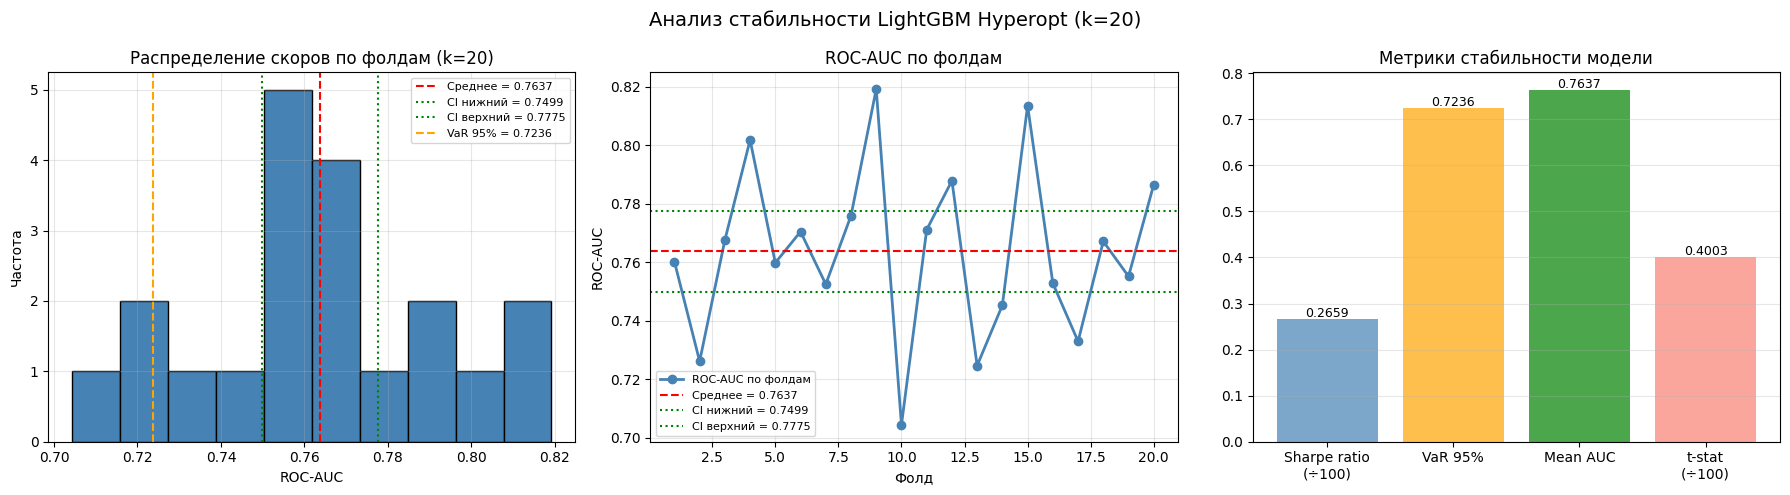

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: гистограмма скоров
axes[0].hist(scores_hyperopt, bins=10, color='steelblue', edgecolor='black')
axes[0].axvline(mean_score, color='red',   linestyle='--',
                label=f'Среднее = {mean_score:.4f}')
axes[0].axvline(ci[0],      color='green', linestyle=':',
                label=f'CI нижний = {ci[0]:.4f}')
axes[0].axvline(ci[1],      color='green', linestyle=':',
                label=f'CI верхний = {ci[1]:.4f}')
axes[0].axvline(var_95,     color='orange', linestyle='--',
                label=f'VaR 95% = {var_95:.4f}')
axes[0].set_xlabel('ROC-AUC')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение скоров по фолдам (k=20)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# График 2: скоры по фолдам и доверительный интервал
axes[1].plot(range(1, 21), scores_hyperopt, marker='o',
             color='steelblue', lw=2, label='ROC-AUC по фолдам')
axes[1].axhline(mean_score, color='red',   linestyle='--',
                label=f'Среднее = {mean_score:.4f}')
axes[1].axhline(ci[0],      color='green', linestyle=':',
                label=f'CI нижний = {ci[0]:.4f}')
axes[1].axhline(ci[1],      color='green', linestyle=':',
                label=f'CI верхний = {ci[1]:.4f}')
axes[1].set_xlabel('Фолд')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC по фолдам')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# График 3: Sharpe ratio и VaR
metrics_names  = ['Sharpe ratio\n(÷100)', 'VaR 95%', 'Mean AUC', 't-stat\n(÷100)']
metrics_values = [sharpe/100, var_95, mean_score, t_stat/100]
colors = ['steelblue', 'orange', 'green', 'salmon']
axes[2].bar(metrics_names, metrics_values, color=colors, alpha=0.7)
axes[2].set_title('Метрики стабильности модели')
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(metrics_values):
    axes[2].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Анализ стабильности LightGBM Hyperopt (k=20)', fontsize=14)
plt.tight_layout()
plt.show()

In [98]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Используем предсказания lgb_hyperopt на валидационной выборке
roc_auc = roc_auc_score(y_val, y_proba_hyperopt_val)
gini    = 2 * roc_auc - 1

# Ищем оптимальный порог для LightGBM
fpr, tpr, thresholds_lgb = roc_curve(y_val, y_proba_hyperopt_val)
optimal_idx_lgb = np.argmax(tpr - fpr)
optimal_threshold_lgb = thresholds_lgb[optimal_idx_lgb]

# Предсказания с двумя порогами 
y_pred_lgb_05      = (y_proba_hyperopt_val >= 0.5).astype(int)
y_pred_lgb_optimal = (y_proba_hyperopt_val >= optimal_threshold_lgb).astype(int)

metrics = {
    'Accuracy':  [accuracy_score(y_val,  y_pred_lgb_05),
                  accuracy_score(y_val,  y_pred_lgb_optimal)],
    'Precision': [precision_score(y_val, y_pred_lgb_05, zero_division=0),
                  precision_score(y_val, y_pred_lgb_optimal, zero_division=0)],
    'Recall':    [recall_score(y_val,    y_pred_lgb_05),
                  recall_score(y_val,    y_pred_lgb_optimal)],
    'F1':        [f1_score(y_val,        y_pred_lgb_05),
                  f1_score(y_val,        y_pred_lgb_optimal)],
    'ROC-AUC':   [roc_auc, roc_auc],
    'Gini':      [gini,    gini]
}

metrics_df = pd.DataFrame(metrics, index=['Порог 0.5', f'Порог {optimal_threshold_lgb:.2f}']).T
print("Метрики LightGBM Hyperopt:")
print(metrics_df.round(4))

Метрики LightGBM Hyperopt:
           Порог 0.5  Порог 0.41
Accuracy      0.7700      0.6584
Precision     0.0357      0.0306
Recall        0.5816      0.7482
F1            0.0672      0.0588
ROC-AUC       0.7566      0.7566
Gini          0.5133      0.5133


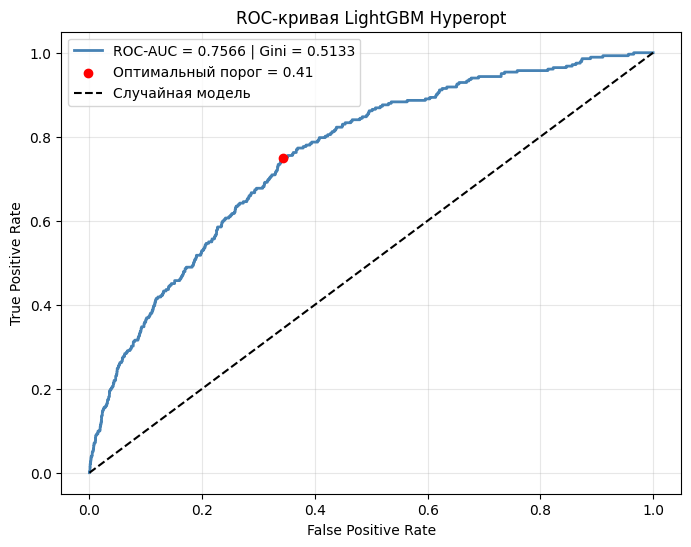

In [99]:
# ROC-кривая LightGBM Hyperopt 
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'ROC-AUC = {roc_auc:.4f} | Gini = {gini:.4f}')
plt.scatter(fpr[optimal_idx_lgb], tpr[optimal_idx_lgb], color='red', zorder=5,
            label=f'Оптимальный порог = {optimal_threshold_lgb:.2f}')
plt.plot([0,1],[0,1],'k--', label='Случайная модель')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая LightGBM Hyperopt')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

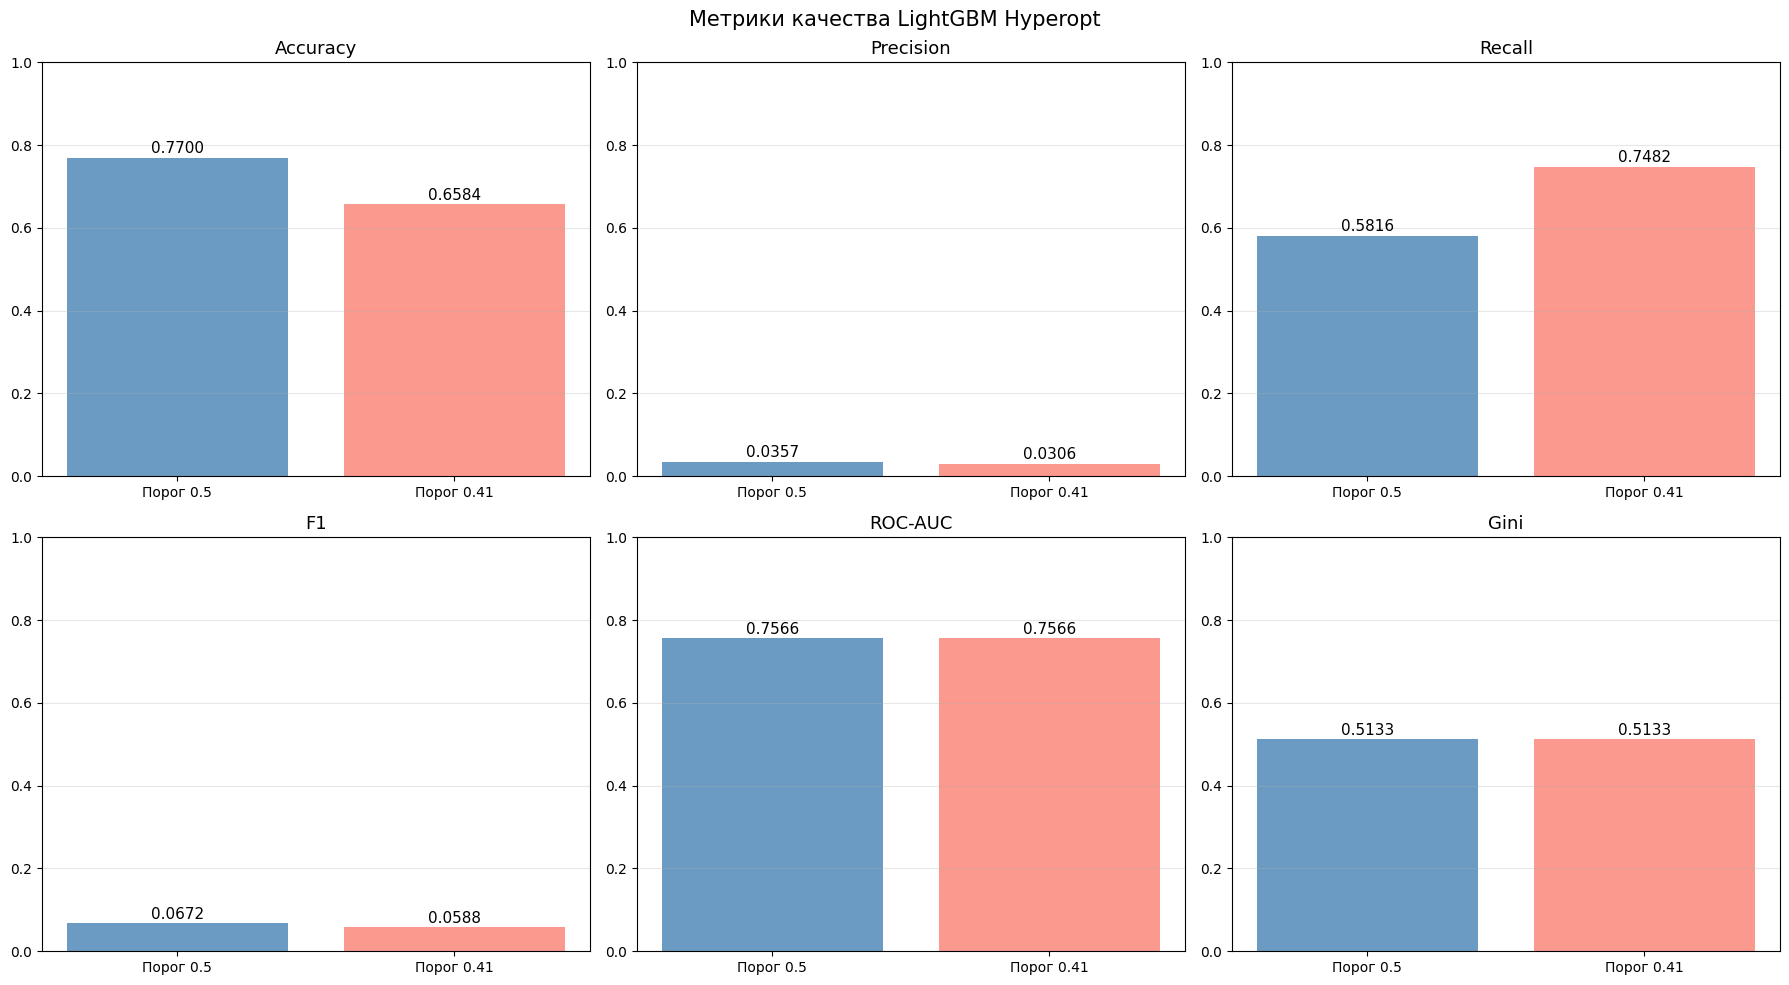

In [100]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metric_names = list(metrics.keys())
colors_05      = 'steelblue'
colors_optimal = 'salmon'

for i, metric in enumerate(metric_names):
    vals = metrics[metric]
    axes[i].bar(['Порог 0.5', f'Порог {optimal_threshold_lgb:.2f}'],
                vals, color=[colors_05, colors_optimal], alpha=0.8)
    axes[i].set_title(f'{metric}', fontsize=13)
    axes[i].set_ylim(0, 1)
    axes[i].grid(axis='y', alpha=0.3)
    for j, v in enumerate(vals):
        axes[i].text(j, v + 0.01, f'{v:.4f}', ha='center', fontsize=11)

plt.suptitle('Метрики качества LightGBM Hyperopt', fontsize=15)
plt.tight_layout()
plt.show()

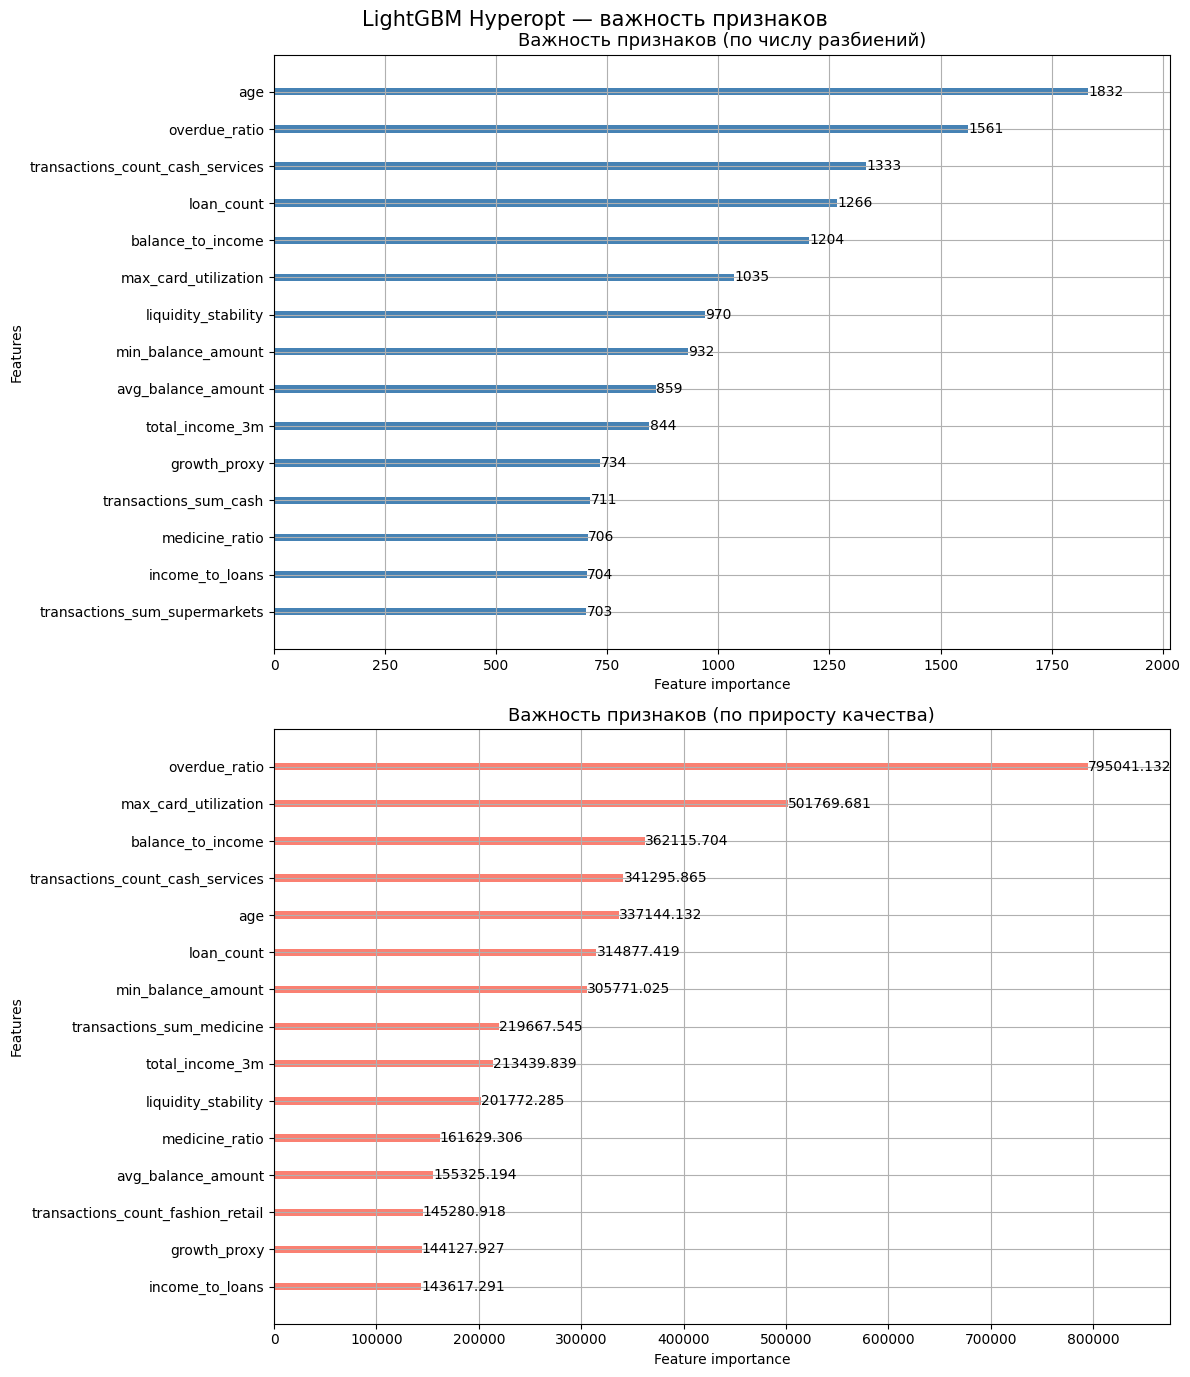

In [101]:
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

lgb.plot_importance(lgb_hyperopt,
                    max_num_features=15,
                    importance_type='split',
                    ax=axes[0],
                    color='steelblue')
axes[0].set_title('Важность признаков (по числу разбиений)', fontsize=13)

lgb.plot_importance(lgb_hyperopt,
                    max_num_features=15,
                    importance_type='gain',
                    ax=axes[1],
                    color='salmon')
axes[1].set_title('Важность признаков (по приросту качества)', fontsize=13)

plt.suptitle('LightGBM Hyperopt — важность признаков', fontsize=15)
plt.tight_layout()
plt.show()

## 10. HistGradientBoosting на сырых данных

HistGradientBoosting — реализация градиентного бустинга из sklearn. Используем на сырых данных (X_train) 

In [102]:
# X_train и X_val — данные с добавленными признаками и заполненными пропусками, но без масштабирования

X_raw_train = X_train
X_raw_val   = X_val

In [103]:
params_hgb = {
    'max_iter':          [200, 300, 500, 800],
    'max_depth':         [3, 4, 5, 6, 7],
    'max_leaf_nodes':    [15, 31, 63, None],
    'learning_rate':     np.logspace(-3, 0, 30),
    'l2_regularization': [0, 0.05, 0.1, 0.3, 0.5, 1.0],
    'min_samples_leaf':  [5, 10, 20, 30, 50],
}

RS_HGB = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_distributions=params_hgb,
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
RS_HGB.fit(X_raw_train, y_train)

print(f"Лучший ROC-AUC CV: {RS_HGB.best_score_:.4f}")
print(f"Лучшие параметры: {RS_HGB.best_params_}")

best_hgb = RS_HGB.best_estimator_
proba_hgb_tuned = best_hgb.predict_proba(X_raw_val)[:, 1]
print(f"ROC-AUC HistGradientBoosting на val: {roc_auc_score(y_val, proba_hgb_tuned):.4f}")

Лучший ROC-AUC CV: 0.7574
Лучшие параметры: {'min_samples_leaf': 10, 'max_leaf_nodes': 63, 'max_iter': 500, 'max_depth': 4, 'learning_rate': np.float64(0.11721022975334805), 'l2_regularization': 0.3}
ROC-AUC HistGradientBoosting на val: 0.7663


In [104]:
hgb_base = HistGradientBoostingClassifier(random_state=42)
hgb_base.fit(X_raw_train, y_train)  
proba_hgb_base = hgb_base.predict_proba(X_raw_val)[:, 1]
print(f"ROC-AUC HistGradientBoosting: {roc_auc_score(y_val, proba_hgb_base):.4f}")

ROC-AUC HistGradientBoosting: 0.7499


In [105]:
# Эксперимент: удаляем 3 самых неважных признака

from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    hgb_base, X_raw_val, y_val,  
    scoring='roc_auc', n_repeats=5, random_state=42, n_jobs=-1
)

importance_for_drop = pd.DataFrame({
    'feature':    X_raw_train.columns, 
    'importance': perm_importance.importances_mean
}).sort_values('importance')

weak_features   = importance_for_drop.head(3)['feature'].tolist()
strong_features = [f for f in X_raw_train.columns if f not in weak_features]  
print(f"Удаляем слабые: {weak_features}")

hgb_reduced = HistGradientBoostingClassifier(random_state=42)
hgb_reduced.fit(X_raw_train[strong_features], y_train)    
proba_reduced = hgb_reduced.predict_proba(X_raw_val[strong_features])[:, 1]  
print(f"ROC-AUC без слабых признаков: {roc_auc_score(y_val, proba_reduced):.4f}")

Удаляем слабые: ['medicine_ratio', 'transactions_sum_cash', 'liquidity_stability']
ROC-AUC без слабых признаков: 0.7493


In [106]:
# Подбираем параметры для лучшего варианта
params_hgb = {
    'max_iter':          [250, 300, 500],
    'max_depth':         [3, 5, 7],
    'learning_rate':     np.logspace(-3, 0, 20),
    'l2_regularization': [0, 0.1, 0.5, 1.0],
    'min_samples_leaf':  [10, 20, 50, 100],
}

RS_HGB = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_distributions=params_hgb,
    n_iter=30,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
RS_HGB.fit(X_raw_train, y_train)  # ← только train!

print(f"Лучший ROC-AUC: {RS_HGB.best_score_:.4f}")
print(f"Лучшие параметры: {RS_HGB.best_params_}")

# Оцениваем на val
best_hgb = RS_HGB.best_estimator_
proba_hgb_tuned = best_hgb.predict_proba(X_raw_val)[:, 1]
print(f"ROC-AUC на val: {roc_auc_score(y_val, proba_hgb_tuned):.4f}")

Лучший ROC-AUC: 0.7558
Лучшие параметры: {'min_samples_leaf': 50, 'max_iter': 300, 'max_depth': 3, 'learning_rate': np.float64(0.11288378916846883), 'l2_regularization': 0.5}
ROC-AUC на val: 0.7572


## 11. Нейронная сеть

Простая нейросеть (Dense Neural Network). 


- Dropout — это регуляризация, которая снижает переобучение.
- EarlyStopping останавливает обучение, когда ROC-AUC на val перестаёт расти. patience=10, означает 10 эпох без улучшения, после которых восстанавливаются веса из лучшей точки.

In [107]:
from tensorflow import keras

2026-06-17 18:53:35.575018: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781722416.065598      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781722416.191733      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781722417.347400      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781722417.347434      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781722417.347437      58 computation_placer.cc:177] computation placer alr

In [108]:
# Два слоя с уменьшающимся числом нейронов 
# relu — нелинейная функция активации, которая позволяет улавливать сложные зависимости.
# Dropout(0.3) после первого слоя, значит используем 30% нейронов, это борьба с переобучением.

model_nn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')  # выход: вероятность дефолта
])

model_nn.compile(
    optimizer='adam',       # адаптивный оптимизатор
    loss='binary_crossentropy',  # стандартная функция потерь для бинарной классификации
    metrics=['AUC']
)
model_nn.summary()

2026-06-17 18:53:58.865926: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [109]:
# class_weight компенсирует дисбаланс и дефолтным клиентам дает вес ~66
# (1.5% дефолтов, значит что недефолтных примерно в 66 раз больше).

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_AUC',
    patience=10,
    mode='max',
    restore_best_weights=True
)

history = model_nn.fit(
    X_train_scaled, y_train,          
    epochs=200,
    batch_size=512,
    validation_data=(X_val_scaled, y_val),  
    class_weight={0: 1, 1: len(y_train[y_train==0])/len(y_train[y_train==1])}, 
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.6710 - loss: 1.2881 - val_AUC: 0.7222 - val_loss: 0.6595
Epoch 2/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7130 - loss: 1.2376 - val_AUC: 0.7254 - val_loss: 0.5863
Epoch 3/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7221 - loss: 1.2144 - val_AUC: 0.7316 - val_loss: 0.5716
Epoch 4/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7244 - loss: 1.2153 - val_AUC: 0.7355 - val_loss: 0.5891
Epoch 5/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7288 - loss: 1.2014 - val_AUC: 0.7363 - val_loss: 0.6042
Epoch 6/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7301 - loss: 1.2027 - val_AUC: 0.7376 - val_loss: 0.6131
Epoch 7/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7335 - loss: 1.1962 - val_AUC: 0.7352 - val_loss: 0.5892
Epoch 8/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7352 - loss: 1.1910 - val_AUC: 0.7358 - val_loss: 0.5943
Epoch 9/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/

619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
ROC-AUC нейросеть: 0.7491


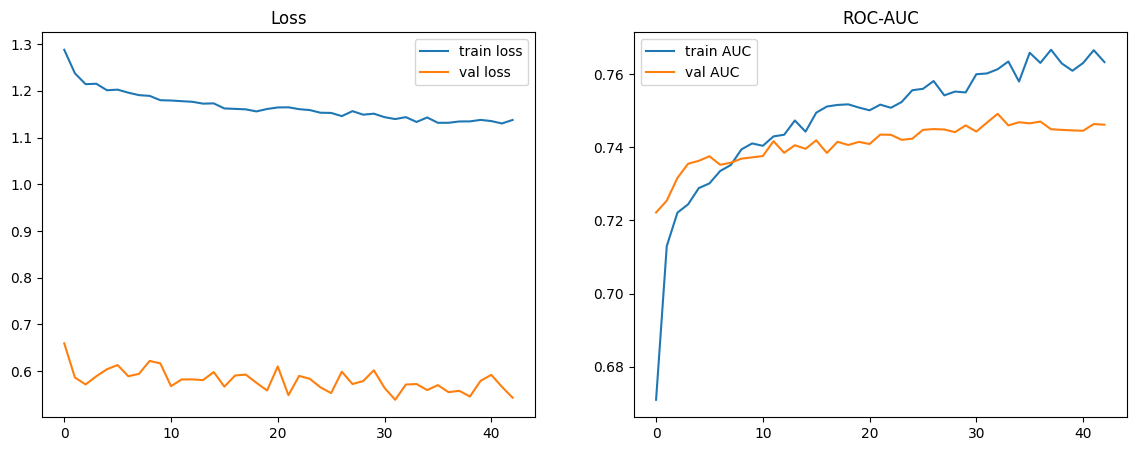

In [110]:
y_proba_nn = model_nn.predict(X_val_scaled).ravel()  # ← scaled!
print(f"ROC-AUC нейросеть: {roc_auc_score(y_val, y_proba_nn):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'],     label='train loss')
axes[0].plot(history.history['val_loss'], label='val loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['AUC'],     label='train AUC')
axes[1].plot(history.history['val_AUC'], label='val AUC')
axes[1].set_title('ROC-AUC')
axes[1].legend()
plt.show()

## 12. CatBoost

CatBoost — градиентный бустинг, разработанный Яндексом.

**Параметры:**
- `iterations` (аналог n_estimators): число деревьев. Чем их больше, тем точнее модель.
- `learning_rate`: шаг градиентного спуска. 
- `depth`: глубина дерева. 
- `l2_leaf_reg`: L2-регуляризация листьев.

In [111]:
import catboost as cb
from sklearn.calibration import CalibratedClassifierCV

In [112]:
params_cb = {
    'iterations':    [500, 700, 1000],  
    'learning_rate': [0.01, 0.03, 0.05], 
    'depth':         [4, 6, 8],
    'l2_leaf_reg':   [3, 5, 10, 15],
    'subsample':     [0.7, 0.8, 1.0]   
}

ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])

RS_cb = RandomizedSearchCV(
    cb.CatBoostClassifier(scale_pos_weight=ratio, random_state=42, verbose=0, allow_writing_files=False),
    param_distributions=params_cb,
    n_iter=15, 
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=1 
)

In [113]:
RS_cb.fit(X_train_scaled, y_train)
print(f"Лучший ROC-AUC CV: {RS_cb.best_score_:.4f}")
print(f"Лучшие параметры: {RS_cb.best_params_}")

# Проверяем на val
y_proba_cb = RS_cb.best_estimator_.predict_proba(X_val_scaled)[:, 1]
print(f"ROC-AUC на val: {roc_auc_score(y_val, y_proba_cb):.4f}")

Лучший ROC-AUC CV: 0.7542
Лучшие параметры: {'subsample': 0.8, 'learning_rate': 0.01, 'l2_leaf_reg': 15, 'iterations': 500, 'depth': 6}
ROC-AUC на val: 0.7616


In [114]:
RS_cb.best_estimator_

CatBoostClassifier(allow_writing_files=False, depth=6, iterations=500, l2_leaf_reg=15, learning_rate=0.01, random_state=42, scale_pos_weight=69.28330373001776, subsample=0.8, verbose=0)

## 13. VotingClassifier

Объединяем три лучшие модели: LightGBM Hyperopt, HistGradientBoosting и LogisticRegression.

Вместо стандартного VotingClassifier с равными весами перебираем все комбинации весов с шагом 0.1 и выбираем оптимальную. 

Разные модели ошибаются в разных местах

In [115]:
# Берём предсказания уже обученных моделей.
# Оптимизируем веса по ROC-AUC на val.

from itertools import product

proba_lgb = lgb_hyperopt.predict_proba(X_val_scaled)[:, 1]
proba_hgb = best_hgb.predict_proba(X_val_scaled)[:, 1]
proba_lr  = best_lr.predict_proba(X_val_scaled[selected_features])[:, 1]

best_score = 0
best_weights = None

weight_range = np.arange(0.0, 1.05, 0.1)

for w_lgb in weight_range:
    for w_hgb in weight_range:
        w_lr = 1 - w_lgb - w_hgb
        if w_lr < 0 or w_lr > 1:
            continue
        blended = w_lgb * proba_lgb + w_hgb * proba_hgb + w_lr * proba_lr
        score = roc_auc_score(y_val, blended)
        if score > best_score:
            best_score = score
            best_weights = (w_lgb, w_hgb, w_lr)

print(f"Лучшие веса (LGB, HGB, LR): {best_weights}")
print(f"Лучший ROC-AUC: {best_score:.4f}")

Лучшие веса (LGB, HGB, LR): (np.float64(0.6000000000000001), np.float64(0.1), np.float64(0.29999999999999993))
Лучший ROC-AUC: 0.7611


In [116]:
vc_best = VotingClassifier(
    estimators=[('LGB', lgb_hyperopt), ('HGB', best_hgb), ('LR', best_lr)],
    voting='soft',
    weights=list(best_weights)
)
vc_best.fit(X_train_scaled, y_train) 

VotingClassifier(estimators=[('LGB',
                              LGBMClassifier(colsample_bytree=0.5545576064139627,
                                             learning_rate=0.007067260645476147,
                                             max_depth=5, min_child_samples=500,
                                             n_estimators=950, n_jobs=-1,
                                             num_leaves=30, objective='binary',
                                             random_state=42,
                                             reg_alpha=0.9596524409962085,
                                             reg_lambda=0.33276401551981616,
                                             scale_pos_weight=69.28330373001776,
                                             subsample=0.86550444681...
                              HistGradientBoostingClassifier(l2_regularization=0.5,
                                                             learning_rate=np.float64(0.11288378916846883),
                                                             max_depth=3,
                                                             max_iter=300,
                                                             min_samples_leaf=50,
                                                             random_state=42)),
                             ('LR',
                              LogisticRegression(C=np.float64(1000.0),
                                                 class_weight='balanced',
                                                 max_iter=500,
                                                 solver='liblinear'))],
                 voting='soft',
                 weights=[np.float64(0.6000000000000001), np.float64(0.1),
                          np.float64(0.29999999999999993)])

In [117]:
print(f"Лучшие веса (LGB, HGB, LR): {best_weights}")
print(f"Лучший ROC-AUC на val: {best_score:.4f}")

y_proba_vc = best_weights[0] * proba_lgb + best_weights[1] * proba_hgb + best_weights[2] * proba_lr
print(f"ROC-AUC ансамбля на val: {roc_auc_score(y_val, y_proba_vc):.4f}")

Лучшие веса (LGB, HGB, LR): (np.float64(0.6000000000000001), np.float64(0.1), np.float64(0.29999999999999993))
Лучший ROC-AUC на val: 0.7611
ROC-AUC ансамбля на val: 0.7611


## 14. Стекинг

Стекинг — более сложный ансамбль. Базовые модели делают предсказания, а мета-модель обучается комбинировать их предсказания.

Отличие от VotingClassifier веса не фиксированы, а обучаются. Мета-модель может давать разные веса разным базовым моделям в зависимости от того, кто из них точнее в разных ситуациях.

In [118]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

sc = StackingClassifier(
    estimators=[
        ('LGB', lgb_hyperopt),   # LightGBM Hyperopt
        ('HGB', best_hgb),       # HistGradientBoosting
        ('LR',  best_lr)         # LogReg
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method='predict_proba',
    n_jobs=-1
)

sc.fit(X_train_scaled, y_train)

y_proba_sc = sc.predict_proba(X_val_scaled)[:, 1]
print(f"ROC-AUC стекинга на val: {roc_auc_score(y_val, y_proba_sc):.4f}")

ROC-AUC стекинга на val: 0.7600


## 15. Сравнение всех моделей

Собираем все модели вместе и сравниваем по единым метрикам на одной валидационной выборке.


In [119]:
models = {
    'LogisticRegression':     best_lr,
    'DecisionTree':           DT_model,
    'KNN':                    kNN_model,
    'RandomForest':           GS_RF.best_estimator_,
    'VotingClassifier':       vc_best,
    'LightGBM (Hyperopt)':    lgb_hyperopt,
    'HistGradientBoosting':   best_hgb,
    'NeuralNetwork':          model_nn,
    'CatBoost':               RS_cb.best_estimator_,  
}

In [120]:
results = {}

model_configs = {
    'LogisticRegression':   (best_lr,                X_train_scaled[selected_features], X_val_scaled[selected_features]),
    'DecisionTree':         (GS_dtc.best_estimator_, X_train_scaled,                    X_val_scaled),
    'KNN':                  (kNN_model,              X_train_scaled[selected_features], X_val_scaled[selected_features]),
    'RandomForest':         (GS_RF.best_estimator_,  X_train_scaled,                    X_val_scaled),
    'LightGBM (Hyperopt)':  (lgb_hyperopt,           X_train_scaled,                    X_val_scaled),
    'HistGradientBoosting': (best_hgb,               X_train,                           X_val),
    'NeuralNetwork':        (model_nn,               X_train_scaled,                    X_val_scaled),
    'CatBoost':             (RS_cb.best_estimator_,  X_train_scaled,                    X_val_scaled),  
}

for name, (model, X_tr, X_v) in model_configs.items():
    if name == 'NeuralNetwork':
        y_proba = model.predict(X_v).ravel()
    else:
        model.fit(X_tr, y_train)
        y_proba = model.predict_proba(X_v)[:, 1]

    y_pred  = (y_proba >= 0.5).astype(int)
    roc_auc = roc_auc_score(y_val, y_proba)

    results[name] = {
        'ROC-AUC':   round(roc_auc, 4),
        'Gini':      round(2 * roc_auc - 1, 4),
        'F1':        round(f1_score(y_val,        y_pred), 4),
        'Precision': round(precision_score(y_val, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_val,    y_pred), 4),
        'Accuracy':  round(accuracy_score(y_val,  y_pred), 4)
    }

results_df = pd.DataFrame(results).T
print(results_df)

619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 994us/step
                      ROC-AUC    Gini      F1  Precision  Recall  Accuracy
LogisticRegression     0.7337  0.4674  0.0591     0.0309  0.6667    0.6972
DecisionTree           0.6983  0.3966  0.0000     0.0000  0.0000    0.9857
KNN                    0.6856  0.3711  0.0000     0.0000  0.0000    0.9857
RandomForest           0.7570  0.5141  0.0000     0.0000  0.0000    0.9857
LightGBM (Hyperopt)    0.7566  0.5133  0.0672     0.0357  0.5816    0.7700
HistGradientBoosting   0.7572  0.5144  0.0000     0.0000  0.0000    0.9857
NeuralNetwork          0.7491  0.4981  0.0554     0.0288  0.7128    0.6533
CatBoost               0.7616  0.5232  0.0646     0.0340  0.6596    0.7278


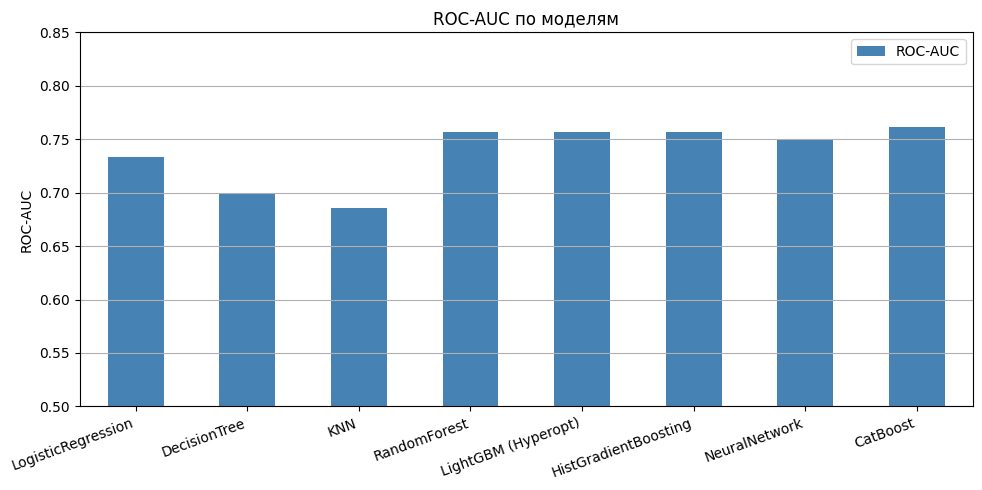

In [121]:
# Значение ROC-AUC по моделям
fig, ax = plt.subplots(figsize=(10, 5))
results_df[['ROC-AUC']].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('ROC-AUC по моделям')
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.5, 0.85)
ax.set_xticklabels(results_df.index, rotation=20, ha='right')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

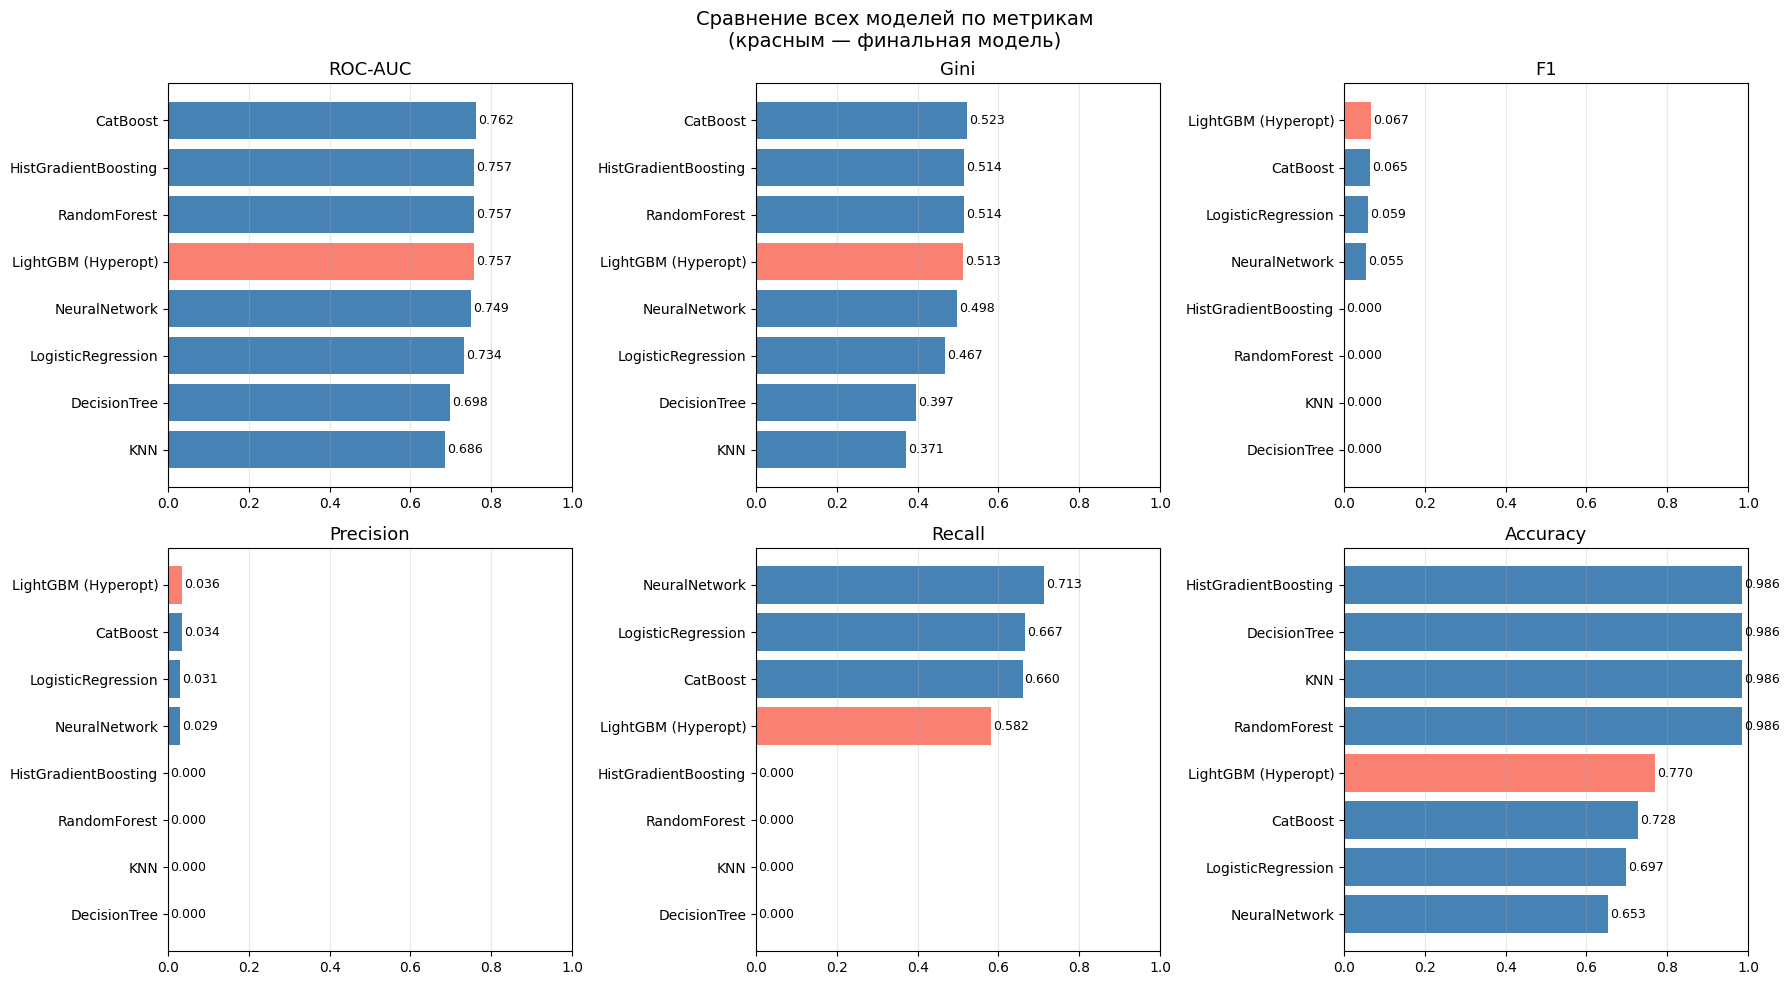

In [122]:
# Сводное сравнение всех моделей по всем метрикам
metrics_to_plot = ['ROC-AUC', 'Gini', 'F1', 'Precision', 'Recall', 'Accuracy']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    vals = results_df[metric].sort_values(ascending=True)
    colors = ['salmon' if m == 'LightGBM (Hyperopt)' else 'steelblue' for m in vals.index]
    axes[i].barh(vals.index, vals.values, color=colors)
    axes[i].set_title(metric, fontsize=13)
    axes[i].set_xlim(0, 1)
    axes[i].grid(axis='x', alpha=0.3)
    for j, v in enumerate(vals.values):
        axes[i].text(v + 0.005, j, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Сравнение всех моделей по метрикам\n(красным — финальная модель)', fontsize=14)
plt.tight_layout()
plt.show()

619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


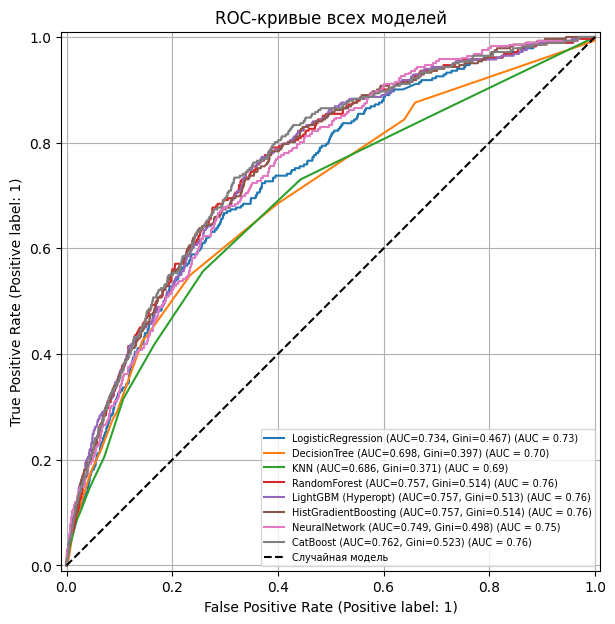

In [123]:
plt.figure(figsize=(10, 7))

for name, (model, X_tr, X_v) in model_configs.items():
    if name == 'NeuralNetwork':
        y_proba = model.predict(X_v).ravel()
    else:
        y_proba = model.predict_proba(X_v)[:, 1]

    auc = roc_auc_score(y_val, y_proba)
    RocCurveDisplay.from_predictions(
        y_val, y_proba,
        name=f"{name} (AUC={auc:.3f}, Gini={2*auc-1:.3f})",
        ax=plt.gca()
    )

plt.plot([0,1],[0,1],'k--', label='Случайная модель')
plt.title('ROC-кривые всех моделей')
plt.legend(loc='lower right', fontsize=7)
plt.grid(True)
plt.show()

## 16. Валидация финальной модели

Проверяем финальную модель (LightGBM Hyperopt):

1. **KS-тест** — насколько хорошо модель разделяет дефолтных и недефолтных клиентов.
2. **График Колмогорова–Смирнова** — визуализация разделимости.
3. **PSI** — стабильна ли модель, похоже ли распределение скоров на train и val
4. **Корреляция признаков** — нет ли сильно скоррелированных переменных.
5. **Сравнение Gini train vs val** — нет ли переобучения.
6. **ROC-кривые train vs val** — ещё один способ проверить переобучение.
7. **Gini по факторам** — стабильна ли предсказательная сила каждого признака.
8. **VIF** — мультиколлинеарность финального набора признаков.

KS-статистика: 0.4053  — чем выше, тем лучше разделяет классы
p-value:       0.000000


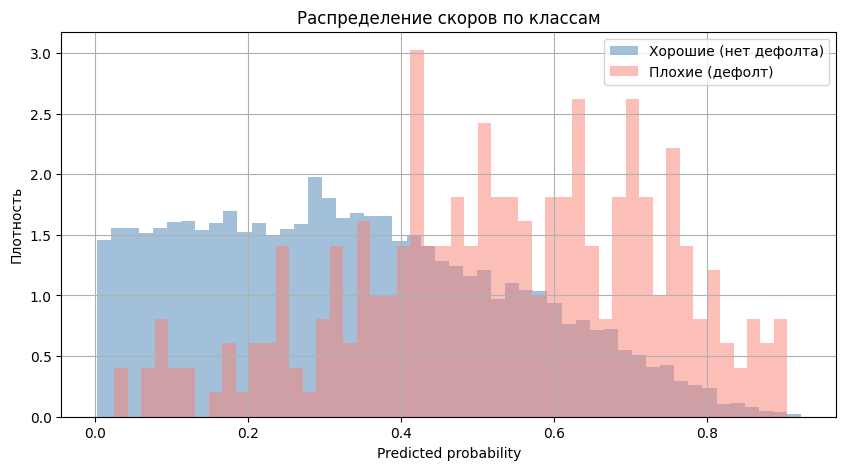

In [124]:
# KS-тест — насколько хорошо модель разделяет хороших и плохих клиентов
y_proba_val_final = lgb_hyperopt.predict_proba(X_val_scaled)[:, 1]

scores_good = y_proba_val_final[y_val == 0]  # скоры клиентов без дефолта
scores_bad  = y_proba_val_final[y_val == 1]  # скоры клиентов с дефолтом

ks_stat, ks_pvalue = stats.ks_2samp(scores_good, scores_bad)
print(f"KS-статистика: {ks_stat:.4f}  — чем выше, тем лучше разделяет классы")
print(f"p-value:       {ks_pvalue:.6f}")

plt.figure(figsize=(10, 5))
plt.hist(scores_good, bins=50, alpha=0.5, label='Хорошие (нет дефолта)', color='steelblue', density=True)
plt.hist(scores_bad,  bins=50, alpha=0.5, label='Плохие (дефолт)',       color='salmon',    density=True)
plt.xlabel('Predicted probability')
plt.ylabel('Плотность')
plt.title('Распределение скоров по классам')
plt.legend()
plt.grid(True)
plt.show()

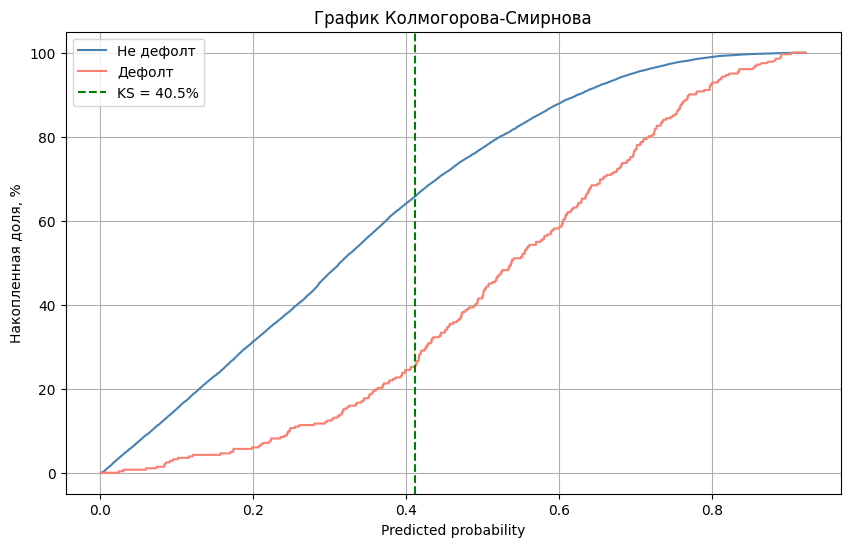

In [125]:
# График Колмогорова-Смирнова
x = np.sort(np.concatenate([scores_good, scores_bad]))
cdf_good = np.searchsorted(np.sort(scores_good), x, side='right') / len(scores_good)
cdf_bad  = np.searchsorted(np.sort(scores_bad),  x, side='right') / len(scores_bad)
ks_idx   = np.argmax(np.abs(cdf_bad - cdf_good))

plt.figure(figsize=(10, 6))
plt.plot(x, cdf_good * 100, color='steelblue', label='Не дефолт')
plt.plot(x, cdf_bad  * 100, color='salmon',    label='Дефолт')
plt.axvline(x[ks_idx], color='green', linestyle='--',
            label=f'KS = {abs(cdf_bad[ks_idx] - cdf_good[ks_idx])*100:.1f}%')
plt.xlabel('Predicted probability')
plt.ylabel('Накопленная доля, %')
plt.title('График Колмогорова-Смирнова')
plt.legend()
plt.grid(True)
plt.show()

PSI: 0.0015 — стабильно


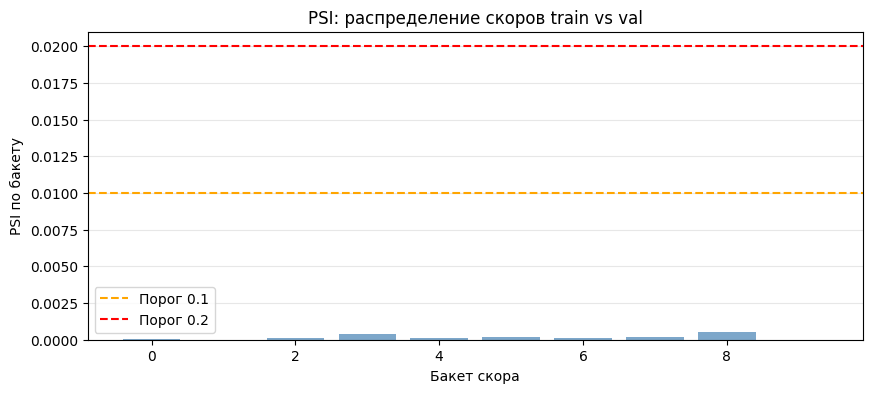

In [126]:
# PSI (Population Stability Index) — насколько стабильна модель: 
# сравниваем распределение скоров на train и val
# PSI < 0.1 — стабильно, 0.1-0.2 — небольшой сдвиг, > 0.2 — нестабильно

def calculate_psi(expected, actual, bins=10):
    """
    expected — скоры на обучающей выборке (baseline)
    actual   — скоры на валидационной выборке
    """
    breakpoints  = np.linspace(0, 1, bins + 1)
    expected_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pct   = np.histogram(actual,   bins=breakpoints)[0] / len(actual)
    expected_pct = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct   = np.where(actual_pct   == 0, 0.0001, actual_pct)
    psi_values   = (actual_pct - expected_pct) * np.log(actual_pct / expected_pct)
    return psi_values.sum(), psi_values, breakpoints

y_proba_train_final = lgb_hyperopt.predict_proba(X_train_scaled)[:, 1]

psi, psi_values, _ = calculate_psi(y_proba_train_final, y_proba_val_final)
print(f"PSI: {psi:.4f} — {'стабильно' if psi < 0.1 else 'небольшой сдвиг' if psi < 0.2 else 'нестабильно'}")

plt.figure(figsize=(10, 4))
plt.bar(range(len(psi_values)), psi_values, color='steelblue', alpha=0.7)
plt.axhline(0.1/len(psi_values), color='orange', linestyle='--', label='Порог 0.1')
plt.axhline(0.2/len(psi_values), color='red',    linestyle='--', label='Порог 0.2')
plt.xlabel('Бакет скора')
plt.ylabel('PSI по бакету')
plt.title('PSI: распределение скоров train vs val')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### Корреляция факторов финальной модели

Проверяем мультиколлинеарность признаков, которые использует финальная модель.

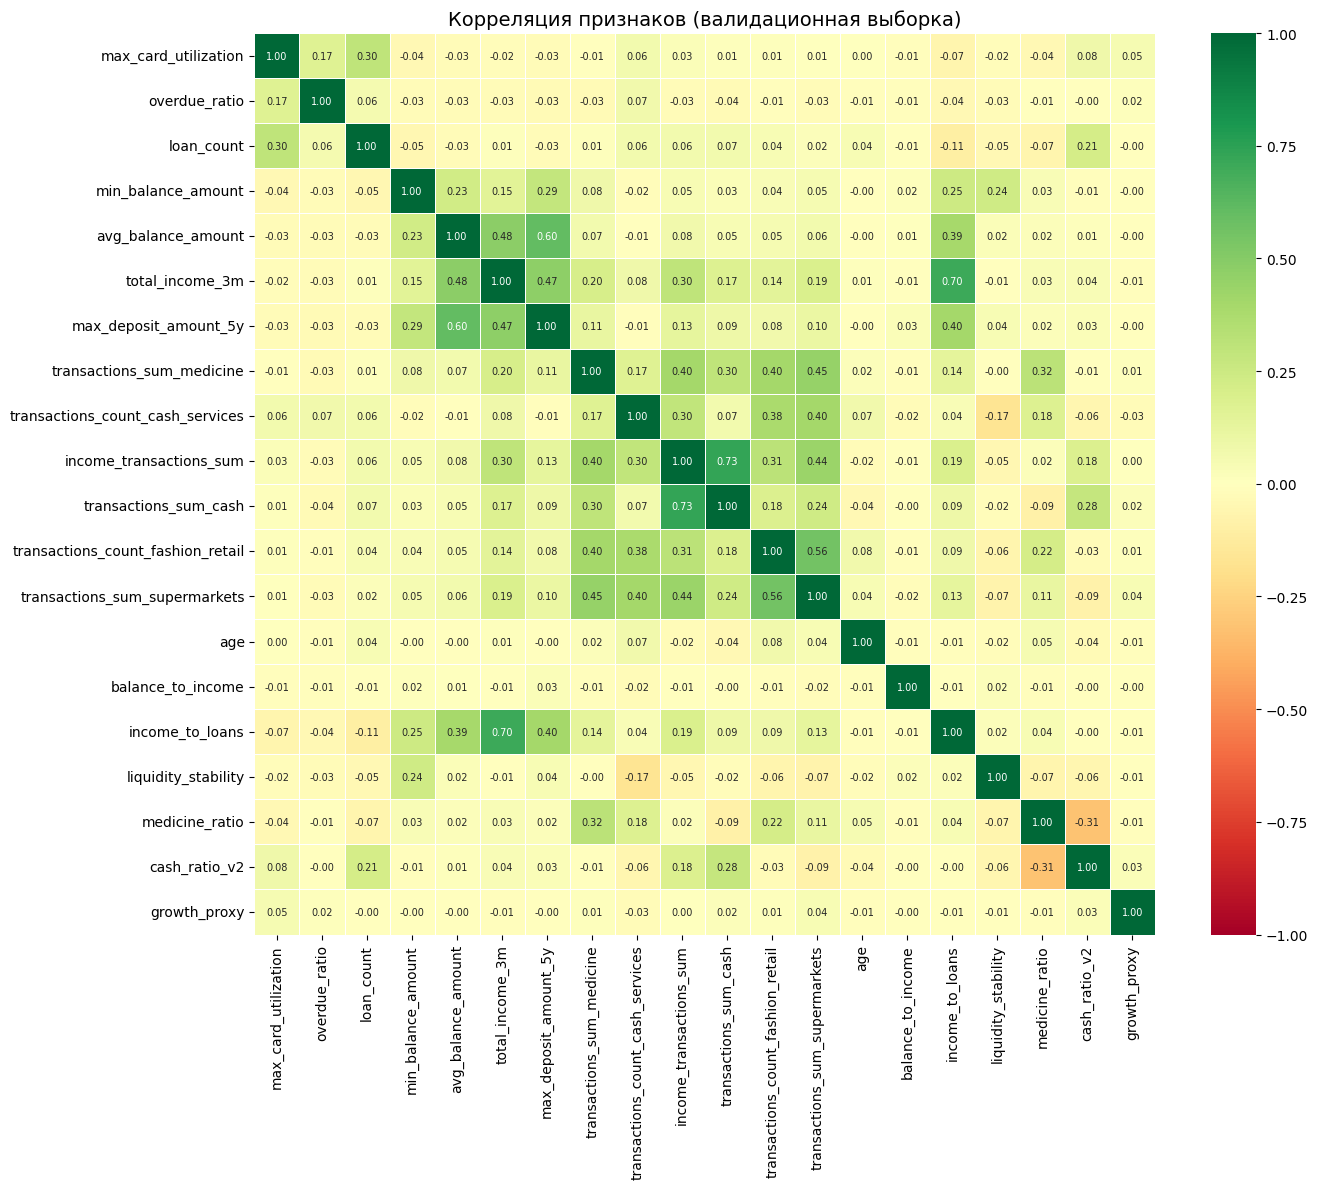

In [127]:
# Корреляционная матрица и парная корреляция признаков
corr_matrix_val = X_val_scaled.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix_val,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Корреляция признаков (валидационная выборка)', fontsize=14)
plt.tight_layout()
plt.show()

### Сравнение метрик финальной модели: train vs val

Проверяем, нет ли переобучения: если метрики на train сильно лучше, чем на val — это признак переобучения.

Train — ROC-AUC: 0.8978  |  Gini: 0.7955
Val   — ROC-AUC: 0.7566  |  Gini: 0.5133
Разница Gini (train - val): 0.2823


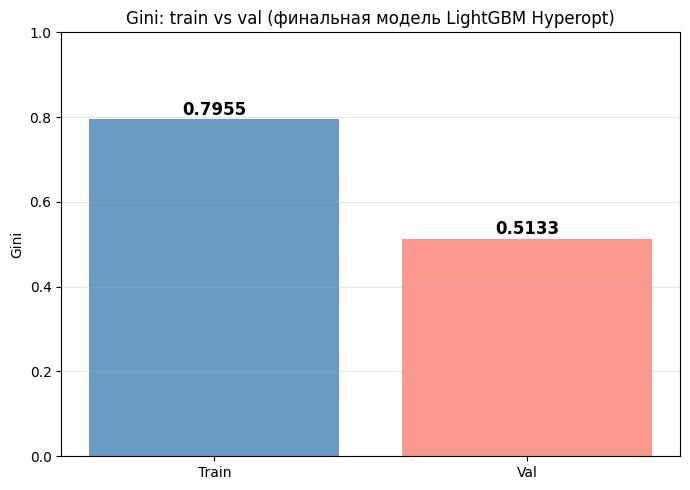

In [128]:
# Сравнение метрик на train и val для финальной модели (lgb_hyperopt)
y_proba_train_check = lgb_hyperopt.predict_proba(X_train_scaled)[:, 1]
y_proba_val_check   = lgb_hyperopt.predict_proba(X_val_scaled)[:, 1]

# Считаем Gini для train и val по каждому признаку отдельно
auc_train = roc_auc_score(y_train, y_proba_train_check)
auc_val   = roc_auc_score(y_val,   y_proba_val_check)

gini_train = 2 * auc_train - 1
gini_val   = 2 * auc_val   - 1

print(f"Train — ROC-AUC: {auc_train:.4f}  |  Gini: {gini_train:.4f}")
print(f"Val   — ROC-AUC: {auc_val:.4f}  |  Gini: {gini_val:.4f}")
print(f"Разница Gini (train - val): {gini_train - gini_val:.4f}")


# Визуализация
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Train', 'Val'], [gini_train, gini_val],
              color=['steelblue', 'salmon'], alpha=0.8)
ax.set_ylabel('Gini')
ax.set_title('Gini: train vs val (финальная модель LightGBM Hyperopt)')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, [gini_train, gini_val]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### ROC-кривые финальной модели: train vs val

Ещё один способ проверить переобучение — сравнить ROC-кривые.

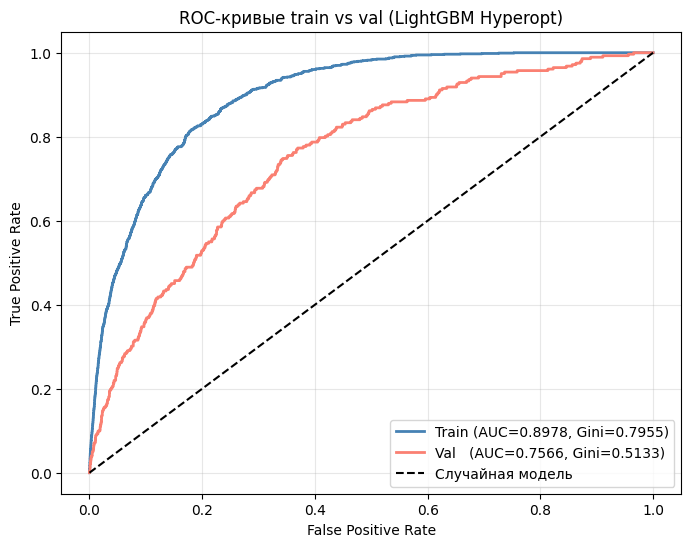

In [129]:
# ROC-кривые train vs val для финальной модели
fpr_train, tpr_train, _ = roc_curve(y_train, y_proba_train_check)
fpr_val,   tpr_val,   _ = roc_curve(y_val,   y_proba_val_check)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color='steelblue', lw=2,
         label=f'Train (AUC={auc_train:.4f}, Gini={gini_train:.4f})')
plt.plot(fpr_val,   tpr_val,   color='salmon',    lw=2,
         label=f'Val   (AUC={auc_val:.4f}, Gini={gini_val:.4f})')
plt.plot([0,1],[0,1],'k--', label='Случайная модель')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые train vs val (LightGBM Hyperopt)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Gini по отдельным факторам модели

Gini факторов: train vs val
                                   Gini Train  Gini Val  Разница
overdue_ratio                          0.3345    0.3057   0.0288
max_card_utilization                   0.2120    0.2917  -0.0797
min_balance_amount                     0.2103    0.1756   0.0347
avg_balance_amount                     0.2123    0.1694   0.0428
transactions_sum_medicine              0.1559    0.1358   0.0201
balance_to_income                      0.1836    0.1265   0.0571
transactions_count_fashion_retail      0.1372    0.1128   0.0245
age                                    0.0495    0.1047  -0.0552
transactions_sum_supermarkets          0.0961    0.1041  -0.0081
growth_proxy                           0.1223    0.0928   0.0296
medicine_ratio                         0.1253    0.0919   0.0334
total_income_3m                        0.0862    0.0907  -0.0045
liquidity_stability                    0.0811    0.0893  -0.0082
income_to_loans                        0.0924    0.0874   0.00

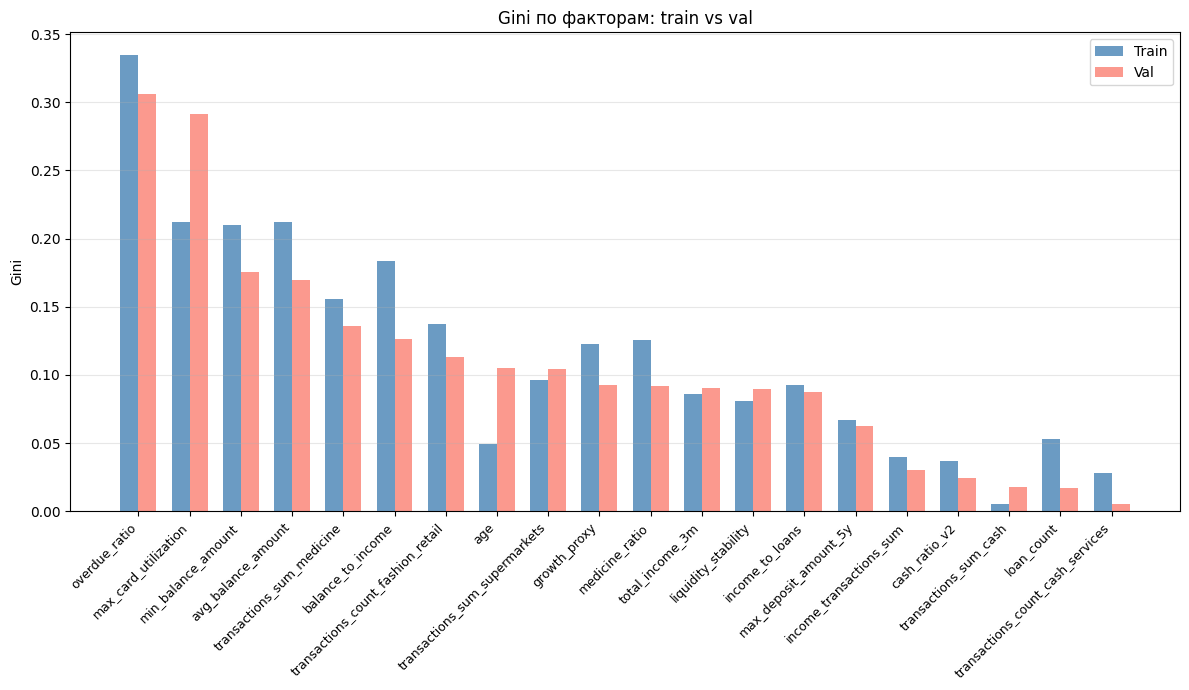

In [130]:
# Gini по каждому признаку на train и val
# Показывает, насколько стабильна предсказательная сила каждой переменной
factor_gini_comparison = {}

for col in X_val_scaled.columns:
    try:
        auc_tr = roc_auc_score(y_train, X_train_scaled[col])
        auc_tr = max(auc_tr, 1 - auc_tr)
        
        auc_v  = roc_auc_score(y_val,   X_val_scaled[col])
        auc_v  = max(auc_v, 1 - auc_v)
        
        factor_gini_comparison[col] = {
            'Gini Train': round(2*auc_tr - 1, 4),
            'Gini Val':   round(2*auc_v  - 1, 4),
            'Разница':    round((2*auc_tr - 1) - (2*auc_v - 1), 4)
        }
    except:
        pass

gini_comparison_df = pd.DataFrame(factor_gini_comparison).T.sort_values('Gini Val', ascending=False)
print("Gini факторов: train vs val")
print(gini_comparison_df)

# Визуализация
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(gini_comparison_df))
width = 0.35
ax.bar(x - width/2, gini_comparison_df['Gini Train'], width, label='Train', color='steelblue', alpha=0.8)
ax.bar(x + width/2, gini_comparison_df['Gini Val'],   width, label='Val',   color='salmon',    alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(gini_comparison_df.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Gini')
ax.set_title('Gini по факторам: train vs val')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Мультиколлинеарность (VIF) — финальная проверка

In [131]:
# VIF для валидационной выборки — проверяем финальный набор признаков
vif_val = pd.DataFrame()
vif_val['feature'] = X_val_scaled.columns
vif_val['VIF'] = [
    variance_inflation_factor(X_val_scaled.values, i)
    for i in range(X_val_scaled.shape[1])
]
vif_val = vif_val.sort_values('VIF', ascending=False)

print("VIF признаков финальной модели:")
print(vif_val)

VIF признаков финальной модели:
                              feature       VIF
9             income_transactions_sum  2.914786
5                     total_income_3m  2.466099
10              transactions_sum_cash  2.404090
15                    income_to_loans  2.128872
12      transactions_sum_supermarkets  1.888315
6               max_deposit_amount_5y  1.765285
4                  avg_balance_amount  1.723744
11  transactions_count_fashion_retail  1.633161
7           transactions_sum_medicine  1.579169
8    transactions_count_cash_services  1.407693
17                     medicine_ratio  1.330456
18                      cash_ratio_v2  1.286666
3                  min_balance_amount  1.204348
2                          loan_count  1.177423
0                max_card_utilization  1.137564
16                liquidity_stability  1.106933
1                       overdue_ratio  1.040067
13                                age  1.016610
19                       growth_proxy  1.009669
14      

### Обучение модели на всех данных

In [132]:
# Переобучаем на train+val с теми же параметрами, что и лучшей модели
X_full = pd.concat([X_train_scaled, X_val_scaled])
y_full = np.concatenate([y_train, y_val])
ratio_full = float(np.sum(y_full == 0) / np.sum(y_full == 1))

lgb_final = lgb.LGBMClassifier(
    **best_params,
    scale_pos_weight=ratio_full,
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)
lgb_final.fit(X_full, y_full)

# сабмит
probs = lgb_final.predict_proba(df_test_scaled)[:, 1]
pd.DataFrame({
    'index':  df_test_scaled.index,
    'target': probs
}).to_csv('submission_final.csv', index=False)
print(f"Среднее предсказание: {probs.mean():.4f}")

Среднее предсказание: 0.3452


## 17. Pipeline — финальная модель

Pipeline объединяет все шаги препроцессинга и финальную модель в один объект.

In [133]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Списки признаков для разного заполнения
zero_fill = [
    'max_card_utilization', 'max_deposit_amount_5y',
    'transactions_sum_medicine', 'transactions_sum_cash',
    'transactions_sum_supermarkets', 'transactions_count_cash_services',
    'transactions_count_fashion_retail', 'loan_count',
    'overdue_ratio', 'total_income_3m', 'income_transactions_sum',
    'min_balance_amount', 'avg_balance_amount'
]
median_fill = ['age']

# Препроцессор: нули для одних, медиана для других
preprocessor = ColumnTransformer([
    ('zero',   SimpleImputer(strategy='constant', fill_value=0), zero_fill),
    ('median', SimpleImputer(strategy='median'),                 median_fill),
], remainder='passthrough')

# Сырые данные с новыми признаками (до масштабирования)
X_train_raw = add_advanced_features(df.loc[X_train.index])
X_val_raw   = add_advanced_features(df.loc[X_val.index])
df_test_raw = add_advanced_features(
    pd.read_csv('/kaggle/input/competitions/srm-2026/X_test.csv', index_col=0)
)

# Pipeline на train 
pipeline = Pipeline([
    ('imputer', preprocessor),
    ('scaler',  StandardScaler()),
    ('model',   lgb.LGBMClassifier(
        **best_params,
        objective='binary',
        scale_pos_weight=ratio,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ))
])
pipeline.fit(X_train_raw, y_train)

y_proba_pipeline = pipeline.predict_proba(X_val_raw)[:, 1]
print(f"ROC-AUC Pipeline на val:    {roc_auc_score(y_val, y_proba_pipeline):.4f}")
print(f"ROC-AUC lgb_hyperopt на val: {roc_auc_score(y_val, y_proba_hyperopt_val):.4f}")

# Pipeline на train+val
X_full_raw = pd.concat([X_train_raw, X_val_raw])
y_full_raw = np.concatenate([y_train, y_val])
ratio_full = float(np.sum(y_full_raw == 0) / np.sum(y_full_raw == 1))

pipeline_final = Pipeline([
    ('imputer', preprocessor),
    ('scaler',  StandardScaler()),
    ('model',   lgb.LGBMClassifier(
        **best_params,
        objective='binary',
        scale_pos_weight=ratio_full,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ))
])
pipeline_final.fit(X_full_raw, y_full_raw)

probs_pipeline = pipeline_final.predict_proba(df_test_raw)[:, 1]
pd.DataFrame({
    'index':  df_test_raw.index,
    'target': probs_pipeline
}).to_csv('submission_pipeline.csv', index=False)

print(f"Сохранено: {len(probs_pipeline)} строк")
print(f"Среднее предсказание: {probs_pipeline.mean():.4f}")

ROC-AUC Pipeline на val:    0.7563
ROC-AUC lgb_hyperopt на val: 0.7566
Сохранено: 24994 строк
Среднее предсказание: 0.3371


Оптимальный порог: 0.5000


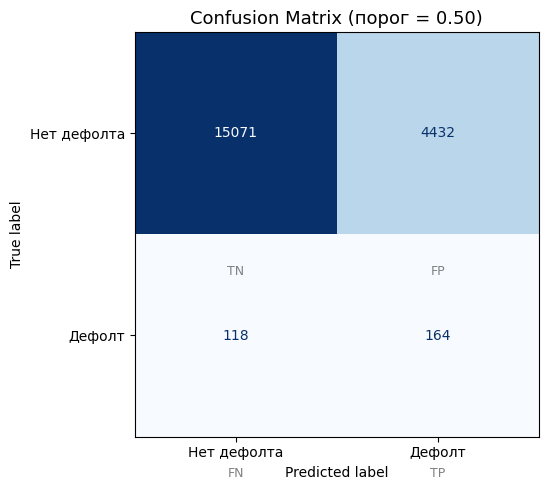

TN (верно: нет дефолта): 15071
FP (ошибка: сказали дефолт, а его нет): 4432
FN (ошибка: пропустили дефолт): 118
TP (верно: есть дефолт): 164


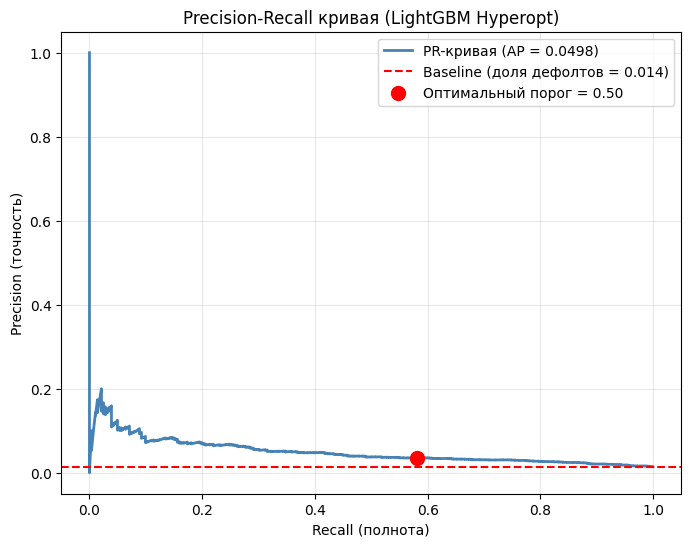

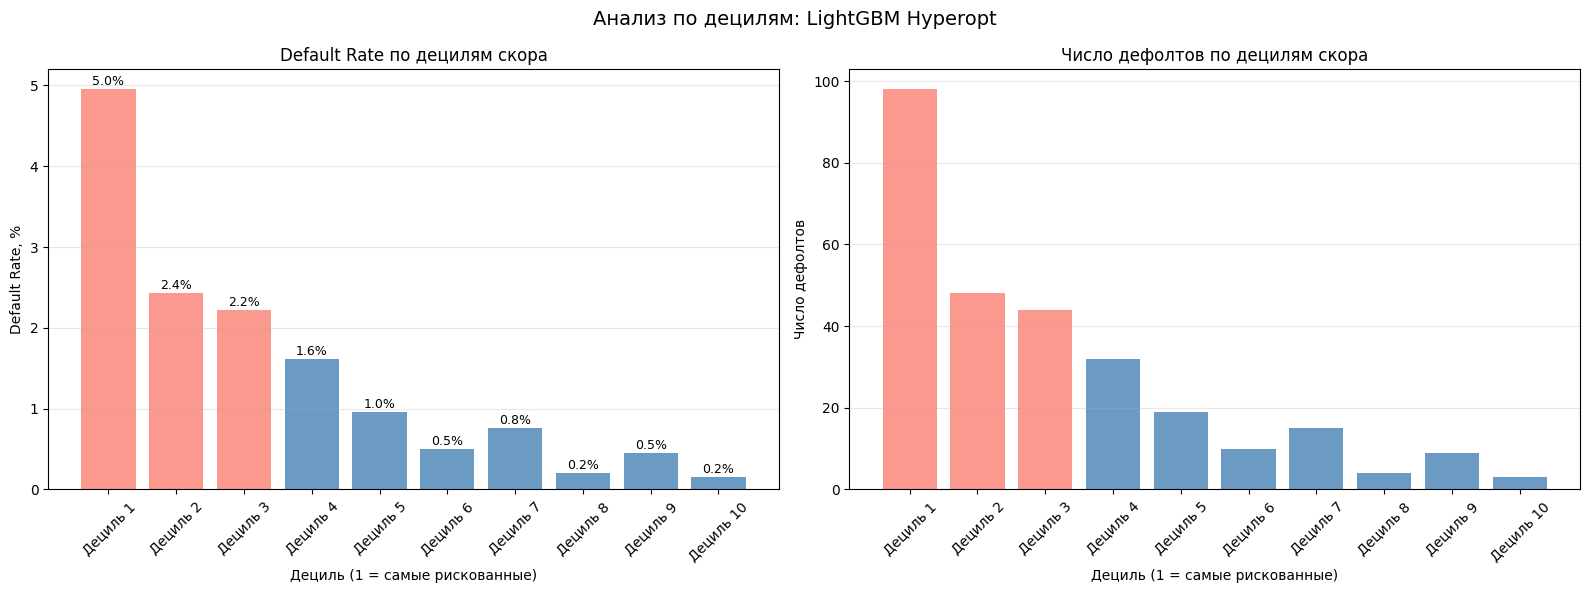


Таблица по децилям:
decile_label  total  defaults  default_rate  min_score  max_score
    Дециль 1   1979        98      4.951996   0.630617   0.922323
    Дециль 2   1978        48      2.426694   0.528281   0.630551
    Дециль 3   1979        44      2.223345   0.445150   0.528110
    Дециль 4   1978        32      1.617796   0.377245   0.445081
    Дециль 5   1978        19      0.960566   0.317321   0.377230
    Дециль 6   1979        10      0.505306   0.260658   0.317266
    Дециль 7   1978        15      0.758342   0.195107   0.260650
    Дециль 8   1979         4      0.202122   0.131785   0.195067
    Дециль 9   1978         9      0.455005   0.068392   0.131694
   Дециль 10   1979         3      0.151592   0.001431   0.068379


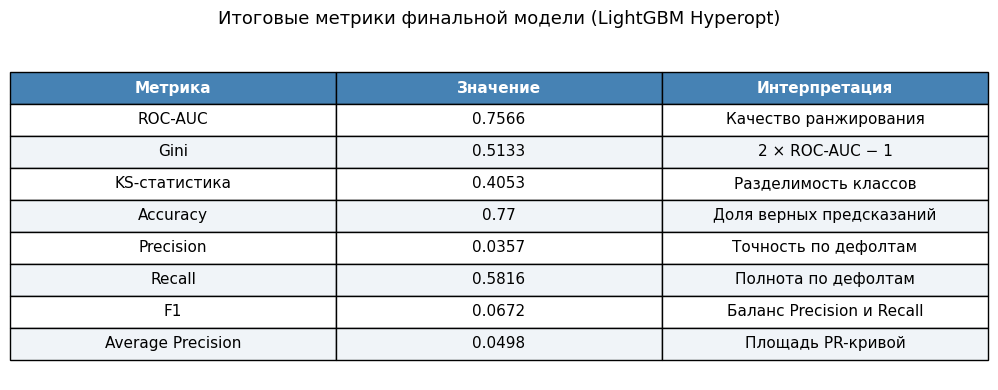

          Метрика  Значение             Интерпретация
          ROC-AUC    0.7566     Качество ранжирования
             Gini    0.5133           2 × ROC-AUC − 1
    KS-статистика    0.4053      Разделимость классов
         Accuracy    0.7700  Доля верных предсказаний
        Precision    0.0357      Точность по дефолтам
           Recall    0.5816       Полнота по дефолтам
               F1    0.0672 Баланс Precision и Recall
Average Precision    0.0498         Площадь PR-кривой


In [134]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score

# ============================================================
# 1. Confusion Matrix при оптимальном пороге
# ============================================================

# Находим оптимальный порог по F1
thresholds = np.linspace(0.01, 0.5, 200)
f1_scores  = [f1_score(y_val, y_proba_hyperopt_val >= t) for t in thresholds]
optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Оптимальный порог: {optimal_threshold:.4f}")

y_pred_optimal = (y_proba_hyperopt_val >= optimal_threshold).astype(int)

cm = confusion_matrix(y_val, y_pred_optimal)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Нет дефолта', 'Дефолт'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix (порог = {optimal_threshold:.2f})', fontsize=13)

# Подписи: что значит каждая ячейка
ax.text(0, 0.7, 'TN', ha='center', color='grey', fontsize=9)
ax.text(1, 0.7, 'FP', ha='center', color='grey', fontsize=9)
ax.text(0, 1.7, 'FN', ha='center', color='grey', fontsize=9)
ax.text(1, 1.7, 'TP', ha='center', color='grey', fontsize=9)

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN (верно: нет дефолта): {tn}")
print(f"FP (ошибка: сказали дефолт, а его нет): {fp}")
print(f"FN (ошибка: пропустили дефолт): {fn}")
print(f"TP (верно: есть дефолт): {tp}")

# ============================================================
# 2. Precision-Recall кривая
# ============================================================

precision, recall, pr_thresholds = precision_recall_curve(y_val, y_proba_hyperopt_val)
ap = average_precision_score(y_val, y_proba_hyperopt_val)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='steelblue', lw=2,
         label=f'PR-кривая (AP = {ap:.4f})')
plt.axhline(y_val.mean(), color='red', linestyle='--',
            label=f'Baseline (доля дефолтов = {y_val.mean():.3f})')
plt.scatter(
    recall[np.argmax(pr_thresholds >= optimal_threshold)] if any(pr_thresholds >= optimal_threshold) else recall[0],
    precision[np.argmax(pr_thresholds >= optimal_threshold)] if any(pr_thresholds >= optimal_threshold) else precision[0],
    color='red', zorder=5, s=100,
    label=f'Оптимальный порог = {optimal_threshold:.2f}'
)
plt.xlabel('Recall (полнота)')
plt.ylabel('Precision (точность)')
plt.title('Precision-Recall кривая (LightGBM Hyperopt)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# 3. График по децилям (Decile Analysis)
# ============================================================

# Делим клиентов на 10 групп по убыванию скора (1 = самые рискованные)
decile_df = pd.DataFrame({
    'score':  y_proba_hyperopt_val,
    'target': y_val
})
decile_df['decile'] = pd.qcut(decile_df['score'], q=10, labels=False, duplicates='drop')
decile_df['decile'] = 9 - decile_df['decile']  # переворачиваем: 0 = самые рискованные

decile_stats = decile_df.groupby('decile').agg(
    total=('target', 'count'),
    defaults=('target', 'sum'),
    min_score=('score', 'min'),
    max_score=('score', 'max')
).reset_index()

decile_stats['default_rate'] = decile_stats['defaults'] / decile_stats['total'] * 100
decile_stats['decile_label'] = decile_stats['decile'].apply(lambda x: f'Дециль {x+1}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График default rate по децилям
colors = ['salmon' if i < 3 else 'steelblue' for i in range(len(decile_stats))]
bars = axes[0].bar(decile_stats['decile_label'], decile_stats['default_rate'],
                    color=colors, alpha=0.8)
axes[0].set_xlabel('Дециль (1 = самые рискованные)')
axes[0].set_ylabel('Default Rate, %')
axes[0].set_title('Default Rate по децилям скора')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, decile_stats['default_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f'{val:.1f}%', ha='center', fontsize=9)

# График числа дефолтов по децилям
axes[1].bar(decile_stats['decile_label'], decile_stats['defaults'],
             color=colors, alpha=0.8)
axes[1].set_xlabel('Дециль (1 = самые рискованные)')
axes[1].set_ylabel('Число дефолтов')
axes[1].set_title('Число дефолтов по децилям скора')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Анализ по децилям: LightGBM Hyperopt', fontsize=14)
plt.tight_layout()
plt.show()

print("\nТаблица по децилям:")
print(decile_stats[['decile_label', 'total', 'defaults', 'default_rate',
                      'min_score', 'max_score']].to_string(index=False))

# ============================================================
# 4. Итоговая таблица метрик
# ============================================================

metrics_summary = {
    'Метрика': ['ROC-AUC', 'Gini', 'KS-статистика',
                'Accuracy', 'Precision', 'Recall', 'F1',
                'Average Precision'],
    'Значение': [
        round(roc_auc_score(y_val, y_proba_hyperopt_val), 4),
        round(2 * roc_auc_score(y_val, y_proba_hyperopt_val) - 1, 4),
        round(ks_stat, 4),
        round(accuracy_score(y_val, y_pred_optimal), 4),
        round(precision_score(y_val, y_pred_optimal, zero_division=0), 4),
        round(recall_score(y_val, y_pred_optimal), 4),
        round(f1_score(y_val, y_pred_optimal), 4),
        round(ap, 4)
    ],
    'Интерпретация': [
        'Качество ранжирования',
        '2 × ROC-AUC − 1',
        'Разделимость классов',
        'Доля верных предсказаний',
        'Точность по дефолтам',
        'Полнота по дефолтам',
        'Баланс Precision и Recall',
        'Площадь PR-кривой'
    ]
}

metrics_df_summary = pd.DataFrame(metrics_summary)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
table = ax.table(
    cellText=metrics_df_summary.values,
    colLabels=metrics_df_summary.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Выделяем заголовок
for j in range(len(metrics_df_summary.columns)):
    table[0, j].set_facecolor('steelblue')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Чередующиеся строки
for i in range(1, len(metrics_df_summary) + 1):
    for j in range(len(metrics_df_summary.columns)):
        if i % 2 == 0:
            table[i, j].set_facecolor('#f0f4f8')

plt.title('Итоговые метрики финальной модели (LightGBM Hyperopt)', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

print(metrics_df_summary.to_string(index=False))

619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
                      ROC-AUC    Gini      F1  Precision  Recall  Accuracy  \
CatBoost               0.7616  0.5232  0.0646     0.0340  0.6596    0.7278   
HistGradientBoosting   0.7572  0.5144  0.1047     0.0771  0.1631    0.9602   
RandomForest           0.7570  0.5141  0.0952     0.0608  0.2199    0.9405   
LightGBM (Hyperopt)    0.7566  0.5133  0.0673     0.0357  0.5851    0.7690   
NeuralNetwork          0.7491  0.4981  0.0557     0.0289  0.7234    0.6501   
LogisticRegression     0.7337  0.4674  0.0591     0.0309  0.6702    0.6960   
DecisionTree           0.6983  0.3966  0.0812     0.0527  0.1773    0.9428   
KNN                    0.6856  0.3711  0.0722     0.0407  0.3156    0.8843   

                      Порог  
CatBoost              0.500  
HistGradientBoosting  0.050  
RandomForest          0.041  
LightGBM (Hyperopt)   0.499  
NeuralNetwork         0.498  
LogisticRegression    0.499  
DecisionTree          0.043  
KNN             

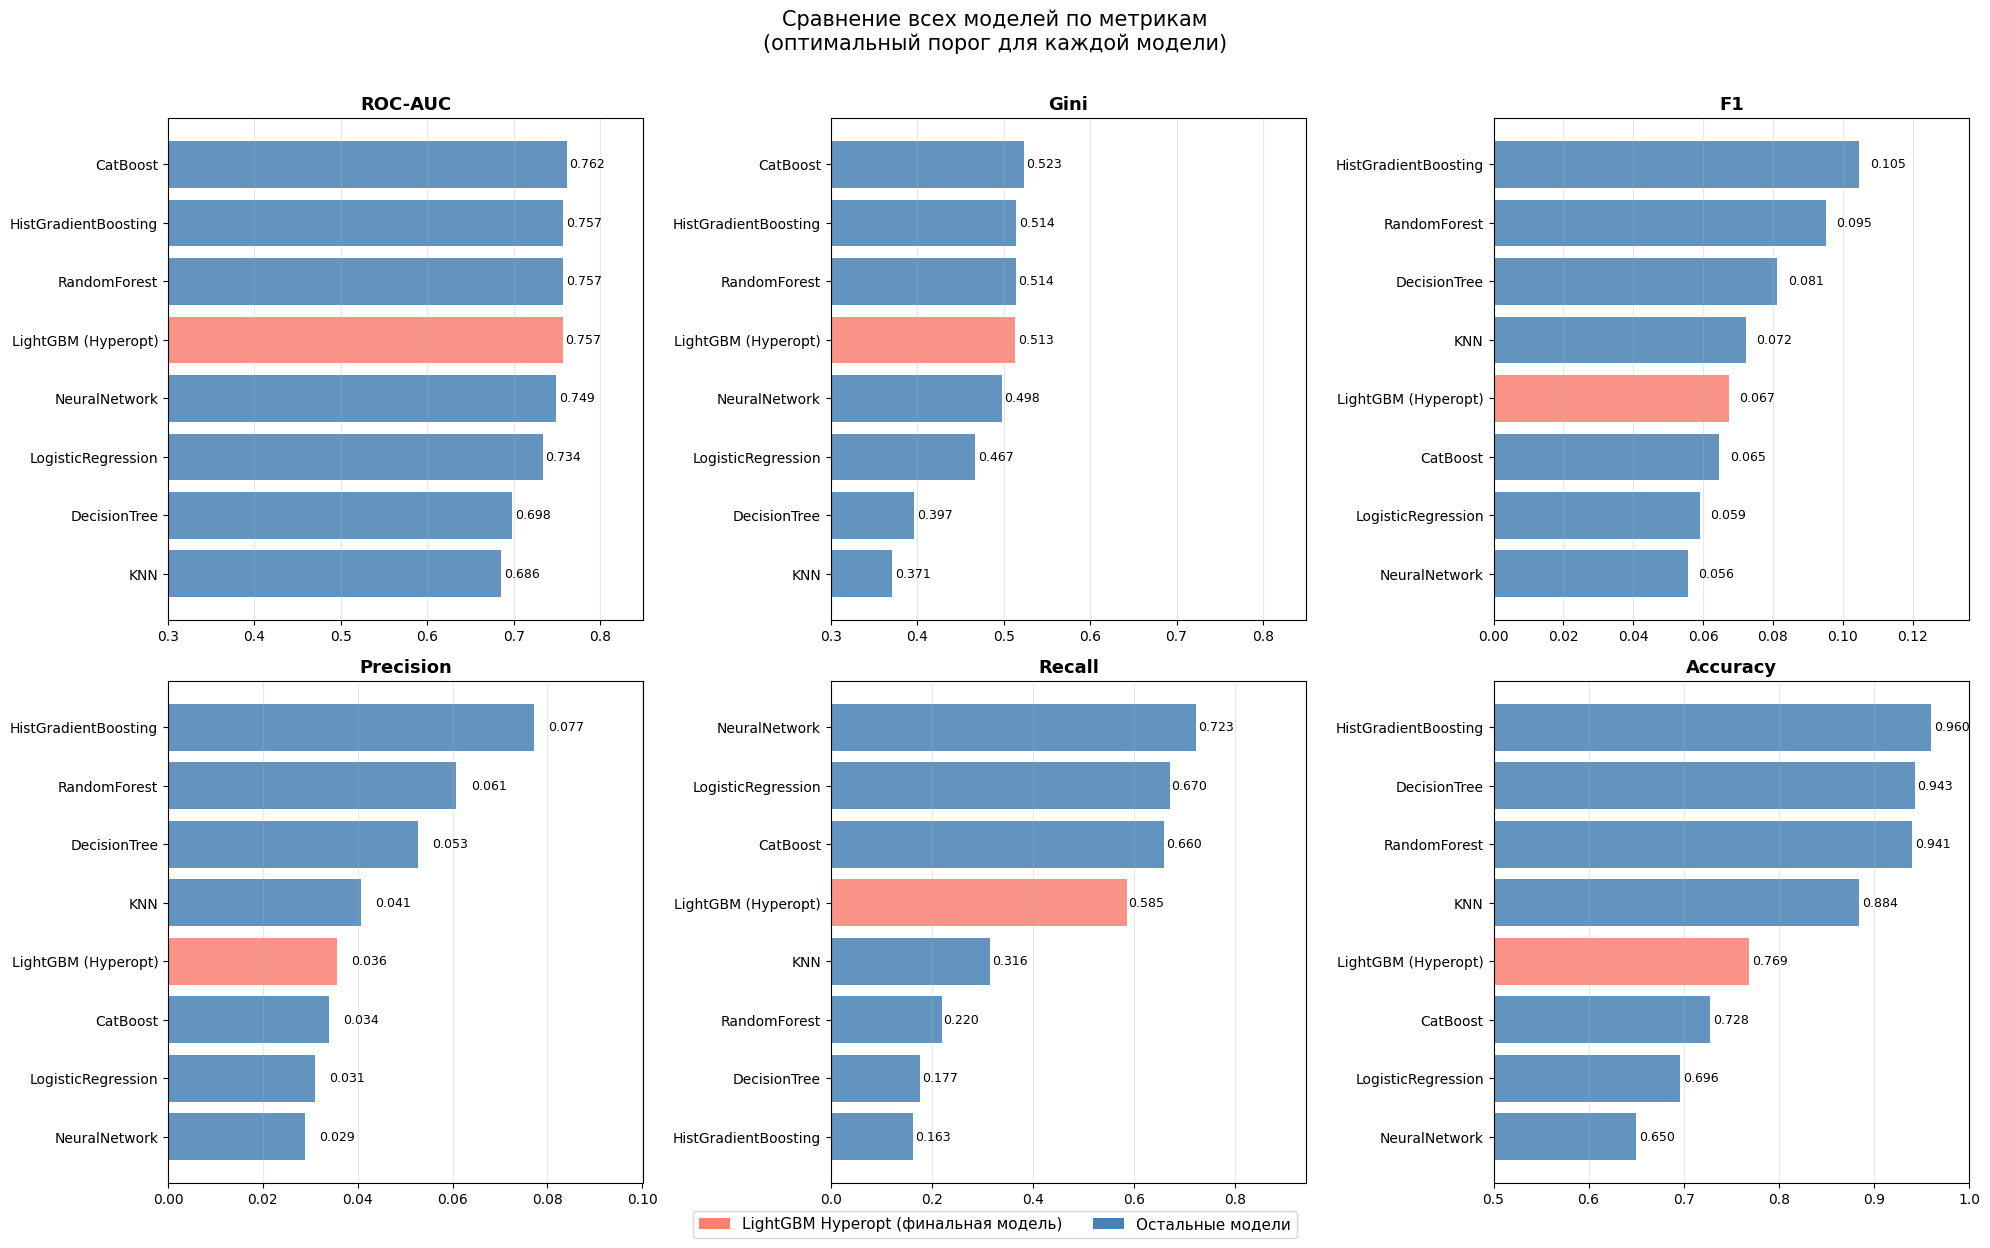

In [135]:
results = {}

for name, (model, X_tr, X_v) in model_configs.items():
    if name == 'NeuralNetwork':
        y_proba = model.predict(X_v).ravel()
    else:
        y_proba = model.predict_proba(X_v)[:, 1]

    # Оптимальный порог по F1 для каждой модели отдельно
    thresholds = np.linspace(0.001, 0.5, 500)
    f1_scores  = [f1_score(y_val, y_proba >= t, zero_division=0) for t in thresholds]
    best_threshold = thresholds[np.argmax(f1_scores)]
    y_pred = (y_proba >= best_threshold).astype(int)
    roc_auc = roc_auc_score(y_val, y_proba)

    results[name] = {
        'ROC-AUC':   round(roc_auc, 4),
        'Gini':      round(2 * roc_auc - 1, 4),
        'F1':        round(f1_score(y_val, y_pred, zero_division=0), 4),
        'Precision': round(precision_score(y_val, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_val, y_pred, zero_division=0), 4),
        'Accuracy':  round(accuracy_score(y_val, y_pred), 4),
        'Порог':     round(best_threshold, 3)
    }

results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print(results_df)

# ============================================================
# График
# ============================================================
metrics_to_plot = ['ROC-AUC', 'Gini', 'F1', 'Precision', 'Recall', 'Accuracy']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    vals = results_df[metric].sort_values(ascending=True)
    colors = ['salmon' if m == 'LightGBM (Hyperopt)' else 'steelblue' for m in vals.index]
    bars = axes[i].barh(vals.index, vals.values, color=colors, alpha=0.85)
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].grid(axis='x', alpha=0.3)

    # Подписи значений
    for bar, v in zip(bars, vals.values):
        axes[i].text(v + 0.003, bar.get_y() + bar.get_height()/2,
                     f'{v:.3f}', va='center', fontsize=9)

    # Разные диапазоны для разных метрик
    if metric in ['ROC-AUC', 'Gini']:
        axes[i].set_xlim(0.3, 0.85)
    elif metric == 'Accuracy':
        axes[i].set_xlim(0.5, 1.0)
    else:
        axes[i].set_xlim(0, max(vals.values) * 1.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='salmon',    label='LightGBM Hyperopt (финальная модель)'),
    Patch(facecolor='steelblue', label='Остальные модели')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Сравнение всех моделей по метрикам\n(оптимальный порог для каждой модели)',
             fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


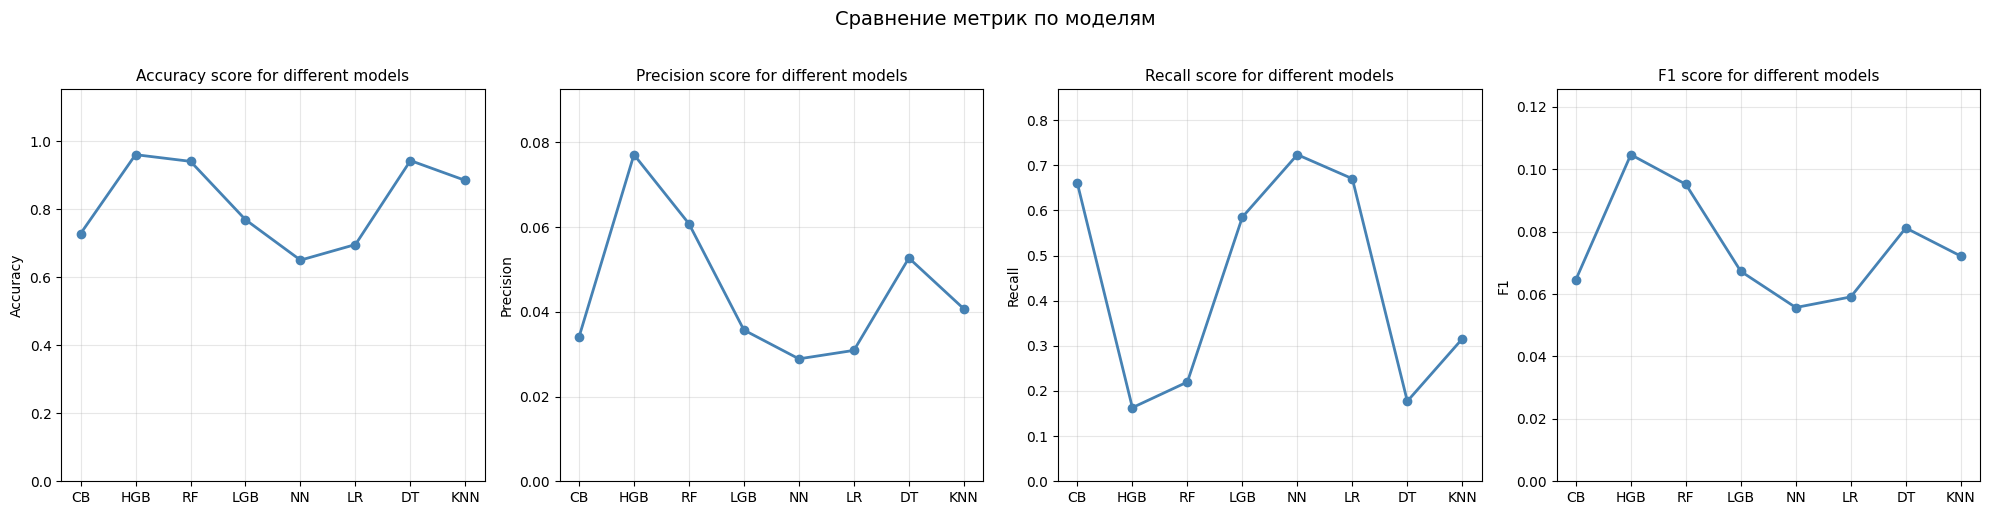

In [137]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']
model_names = list(results_df.index)

# Короткие названия для оси X
short_names = {
    'LogisticRegression':   'LR',
    'DecisionTree':         'DT',
    'KNN':                  'KNN',
    'RandomForest':         'RF',
    'LightGBM (Hyperopt)':  'LGB',
    'HistGradientBoosting': 'HGB',
    'NeuralNetwork':        'NN',
    'CatBoost':             'CB'
}

labels = [short_names.get(name, name) for name in model_names]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, metric in enumerate(metrics_to_plot):
    vals = [results_df.loc[name, metric] for name in model_names]

    axes[i].plot(labels, vals, marker='o', color='steelblue', lw=2)
    axes[i].set_title(f'{metric} score for different models', fontsize=11)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', labelsize=10)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim(0, max(vals) * 1.2)

plt.suptitle('Сравнение метрик по моделям', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()